<a href="https://colab.research.google.com/github/athariqmn97/Finpro-Rakamin-DS56-Kelompok2/blob/main/Master_Code_Kelompok_2_DANN_Co_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Week 18 - Final Project Stage 2 - DANN Co.
**Data Solution & Data Driven**

Member of DANN Co. :
1. Dadin Tajudin (Project Manager)
2. Athariq Marsha Nugraha (Data Engineer)
3. Nada Paradita (Data Scientist)
4. Nida Febiana (Business / Data Analyst)

# Load Data Set, Data Overview, Kategorisasi Data

## Load Data Set

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving employee_churn_prediction_updated.csv to employee_churn_prediction_updated.csv


## Data Overview

In [ ]:
# Import
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline


print('numpy version : ',np.__version__)
print('pandas version : ',pd.__version__)
print('seaborn version : ',sns.__version__)

sns.set(rc={'figure.figsize':(20.7,8.27)})
sns.set_style("whitegrid")
sns.color_palette("dark")
plt.style.use("fivethirtyeight")

numpy version :  2.0.2
pandas version :  2.2.2
seaborn version :  0.13.2


In [ ]:
# Load Data Set, Overview, dan Kategorisasi
df = pd.read_csv('employee_churn_prediction_updated.csv')
df.head(5)

,employee_id,age,gender,education,experience_years,monthly_target,target_achievement,working_hours_per_week,overtime_hours_per_week,salary,commission_rate,job_satisfaction,work_location,manager_support_score,company_tenure_years,churn,marital_status,distance_to_office_km,churn_period
0,1,28,Male,High School,0,153,0.94,62,9,4667108,0.03,4,Suburban,3,2.8,0,Married,22,Stayed
1,2,41,Male,Diploma,6,188,0.54,55,8,5853507,0.06,3,Urban,3,2.7,1,Single,36,Onboarding
2,3,36,Female,High School,8,159,0.44,59,10,4781336,0.07,1,Urban,2,1.7,1,Single,17,Onboarding
3,4,32,Male,Diploma,7,185,0.66,68,15,3624588,0.05,1,Urban,2,0.5,1,Married,32,Onboarding
4,5,29,Female,High School,7,142,1.01,45,9,5154327,0.08,3,Rural,2,4.5,0,Single,14,Stayed


In [ ]:
df.describe()

,employee_id,age,experience_years,monthly_target,target_achievement,working_hours_per_week,overtime_hours_per_week,salary,commission_rate,job_satisfaction,manager_support_score,company_tenure_years,churn,distance_to_office_km
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.00000,1000.000000,1000.000000,1.000000e+03,1000.000000,1000.000000,1000.00000,1000.00000,1000.000000,1000.000000
mean,500.500000,32.845000,4.495000,125.877000,0.79188,54.102000,9.508000,5.487914e+06,0.058830,2.524000,2.53200,2.59800,0.629000,24.119000
std,288.819436,6.854046,2.890732,43.895748,0.22872,8.721907,5.739066,1.436482e+06,0.023278,1.125474,1.11724,1.40282,0.483314,13.978062
min,1.000000,22.000000,0.000000,50.000000,0.40000,40.000000,0.000000,3.000037e+06,0.020000,1.000000,1.00000,0.10000,0.000000,1.000000
25%,250.750000,27.000000,2.000000,86.750000,0.59000,46.000000,5.000000,4.258970e+06,0.040000,2.000000,2.00000,1.40000,0.000000,12.000000
50%,500.500000,33.000000,5.000000,127.500000,0.79000,54.000000,9.500000,5.471270e+06,0.060000,3.000000,3.00000,2.60000,1.000000,23.500000
75%,750.250000,39.000000,7.000000,164.000000,0.99000,62.000000,15.000000,6.727894e+06,0.080000,4.000000,4.00000,3.80000,1.000000,36.000000
max,1000.000000,44.000000,9.000000,199.000000,1.20000,69.000000,19.000000,7.999712e+06,0.100000,4.000000,4.00000,5.00000,1.000000,49.000000


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 19 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   employee_id              1000 non-null   int64  
 1   age                      1000 non-null   int64  
 2   gender                   1000 non-null   object 
 3   education                1000 non-null   object 
 4   experience_years         1000 non-null   int64  
 5   monthly_target           1000 non-null   int64  
 6   target_achievement       1000 non-null   float64
 7   working_hours_per_week   1000 non-null   int64  
 8   overtime_hours_per_week  1000 non-null   int64  
 9   salary                   1000 non-null   int64  
 10  commission_rate          1000 non-null   float64
 11  job_satisfaction         1000 non-null   int64  
 12  work_location            1000 non-null   object 
 13  manager_support_score    1000 non-null   int64  
 14  company_tenure_years     

In [ ]:
df.describe(include='object')

,gender,education,work_location,marital_status,churn_period
count,1000,1000,1000,1000,1000
unique,2,3,3,2,4
top,Male,Diploma,Urban,Single,Stayed
freq,703,404,500,606,371


## Kategorisasi Data

In [ ]:
df.columns

Index(['employee_id', 'age', 'gender', 'education', 'experience_years',
       'monthly_target', 'target_achievement', 'working_hours_per_week',
       'overtime_hours_per_week', 'salary', 'commission_rate',
       'job_satisfaction', 'work_location', 'manager_support_score',
       'company_tenure_years', 'churn', 'marital_status',
       'distance_to_office_km', 'churn_period'],
      dtype='object')

In [ ]:
# variabel numerical
nums = ['age', 'experience_years', 'monthly_target', 'target_achievement',
        'working_hours_per_week', 'overtime_hours_per_week', 'salary',
        'commission_rate', 'company_tenure_years', 'job_satisfaction',
        'manager_support_score', 'distance_to_office_km', 'churn']

# variabel kategorikal
## bertingkat
cat_bertingkat = ['education', 'churn_period', 'work_location']

## tidak bertingkat
cat_biasa = ['gender', 'marital_status', 'churn' ]

# Total 19 Parameters

# Univariate & Multivariate Analysis

## Univariate Analysis

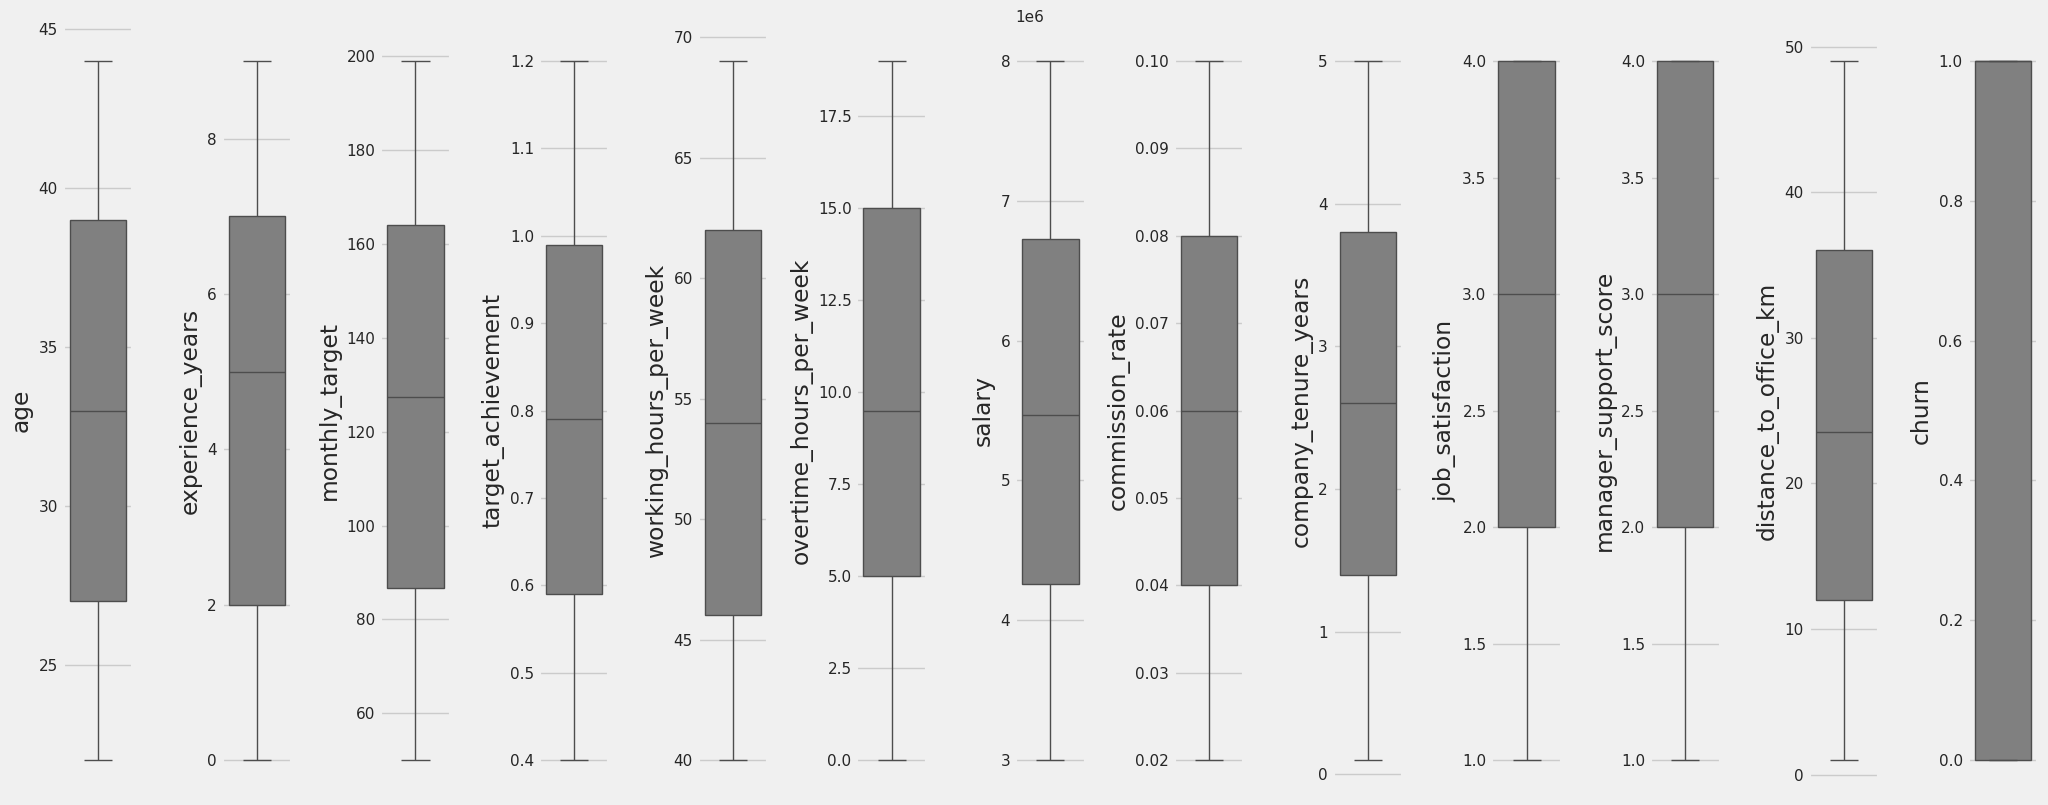

In [ ]:
# Box Plot
for i in range(0, len(nums)):
    plt.subplot(1, len(nums), i+1)
    sns.boxplot(y=df[nums[i]], color='gray', orient='v')
    plt.tight_layout()
plt.show()

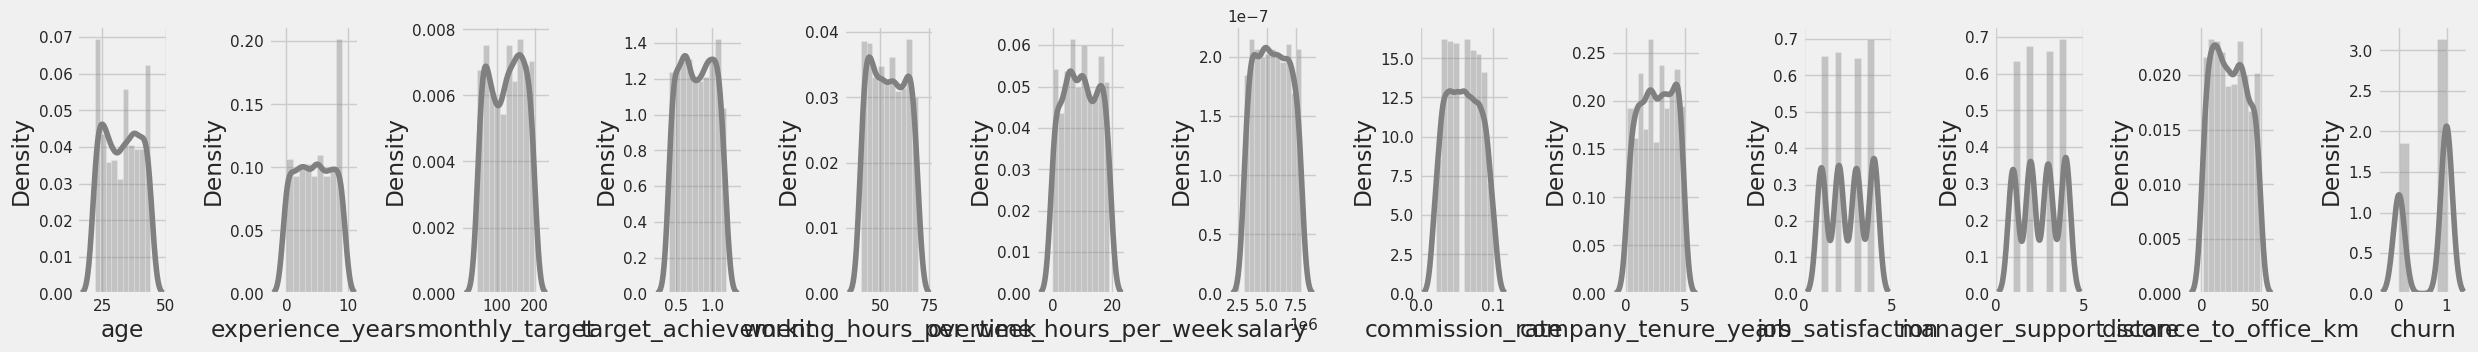

In [ ]:
# Dist Plot
plt.figure(figsize=(25, 10))
for i in range(0, len(nums)):
    plt.subplot(3, len(nums), i+1)
    sns.distplot(df[nums[i]], color='gray')
    plt.tight_layout()
plt.show()

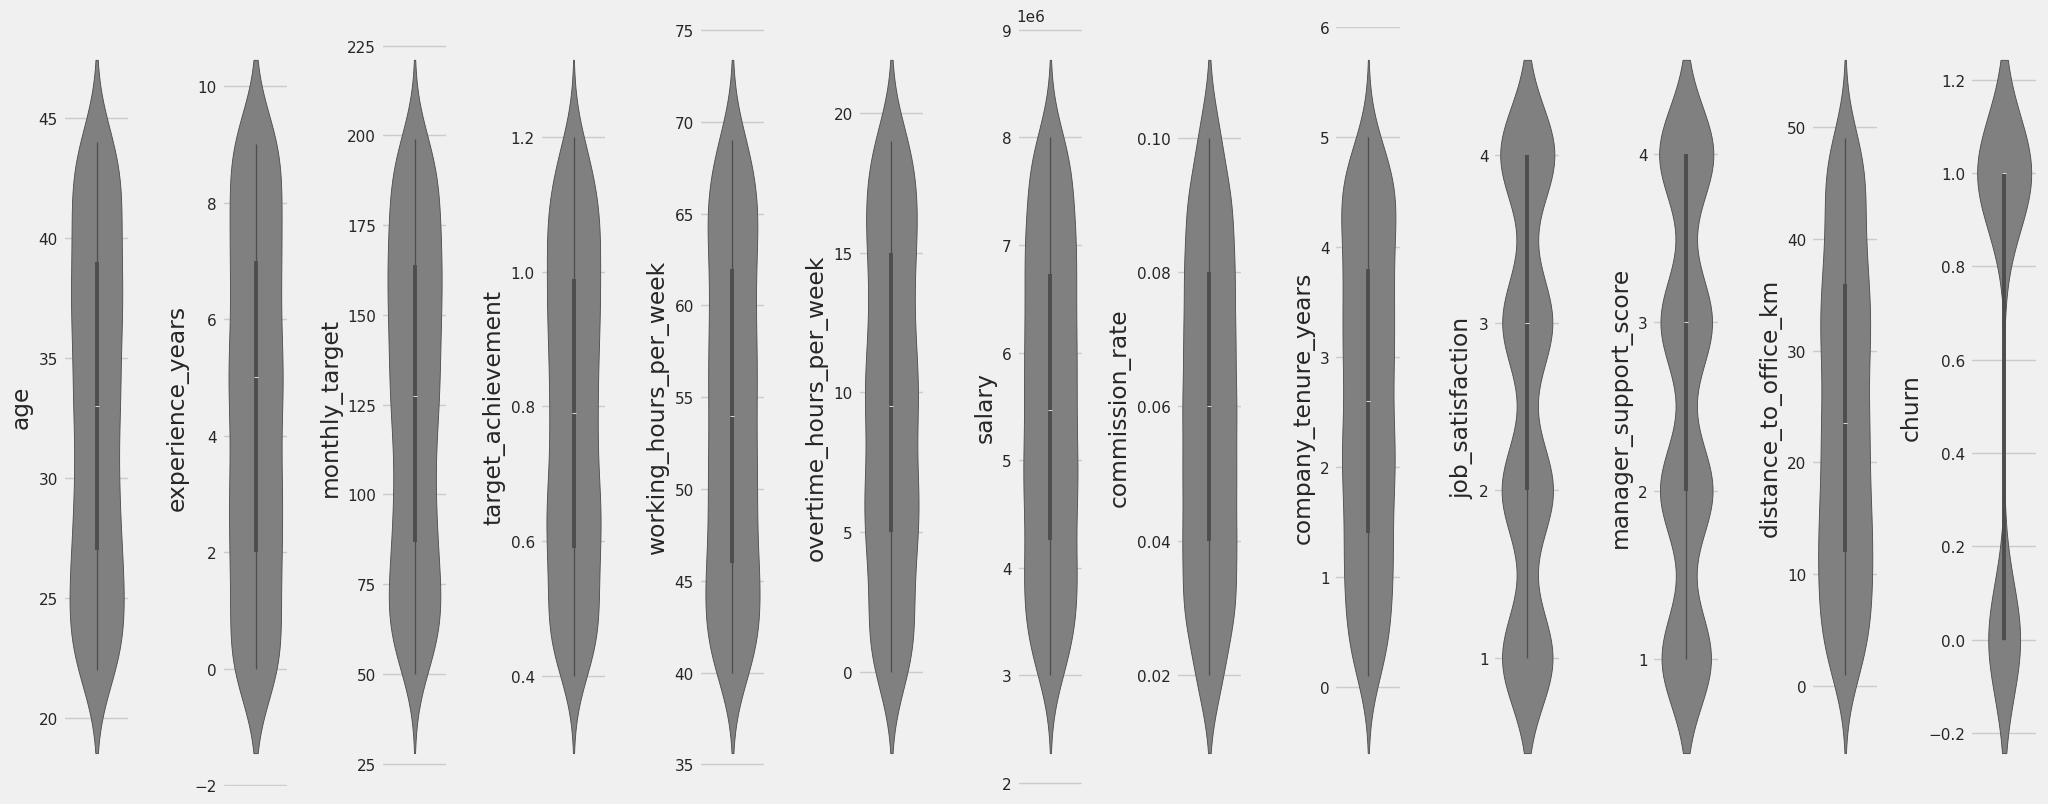

In [ ]:
# Violin Plot
for i in range(0, len(nums)):
    plt.subplot(1, len(nums), i+1)
    sns.violinplot(y=df[nums[i]], color='gray', orient='v')
    plt.tight_layout()
plt.show()

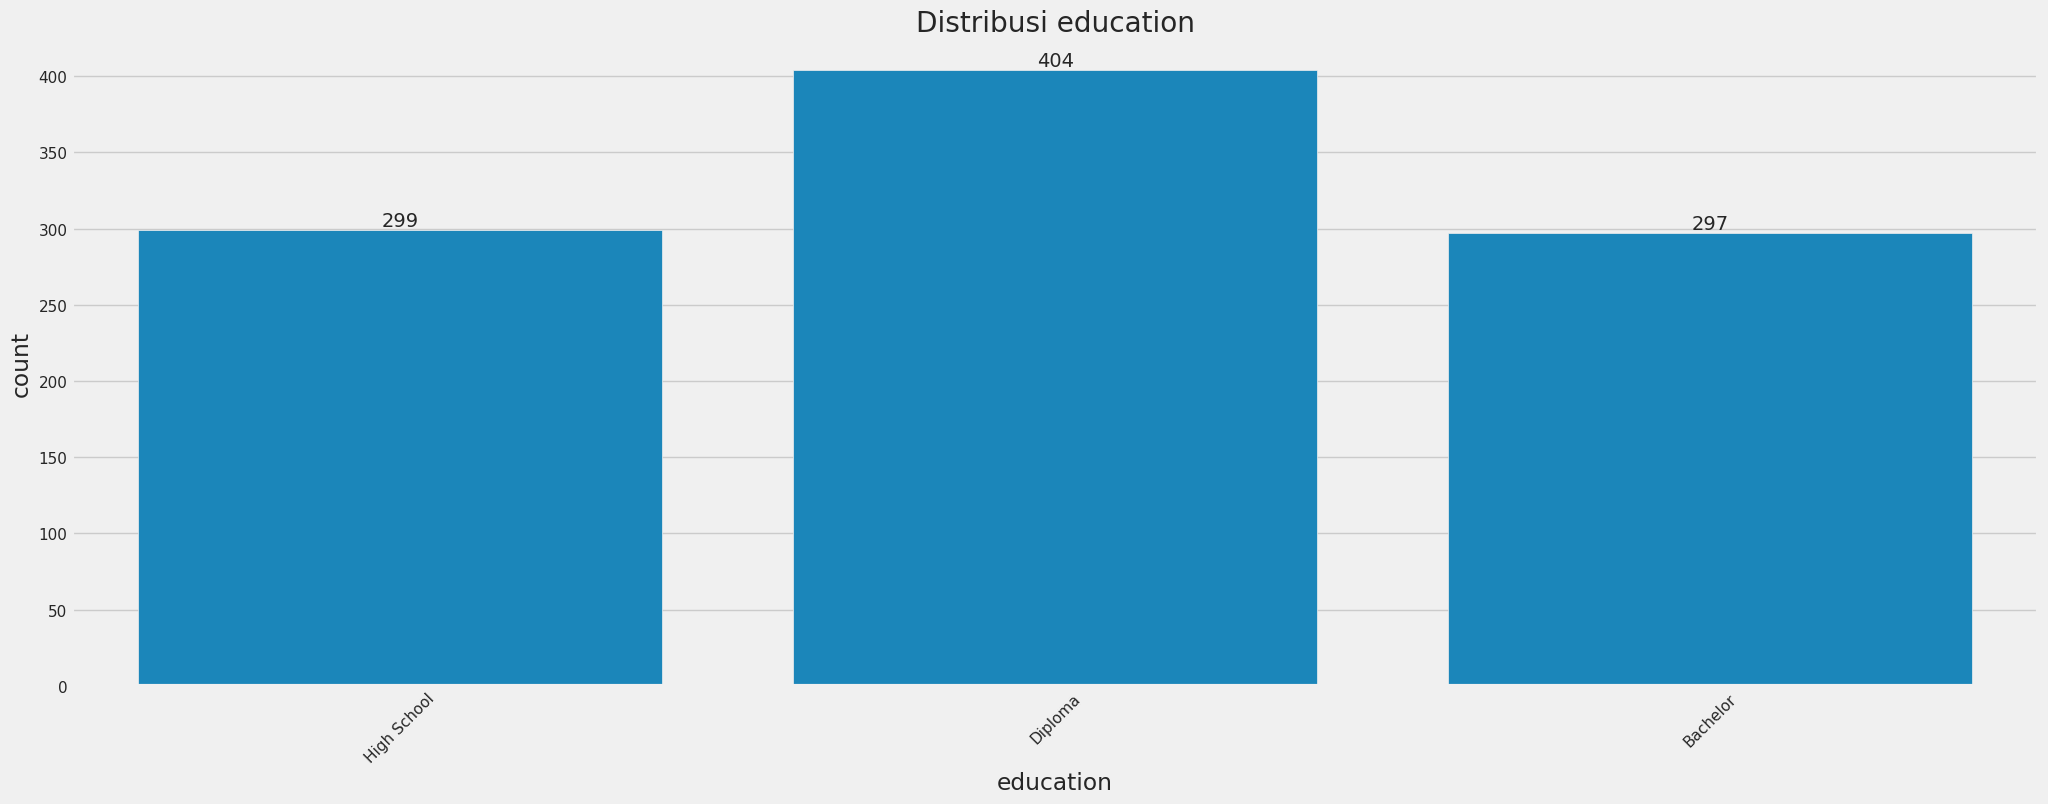

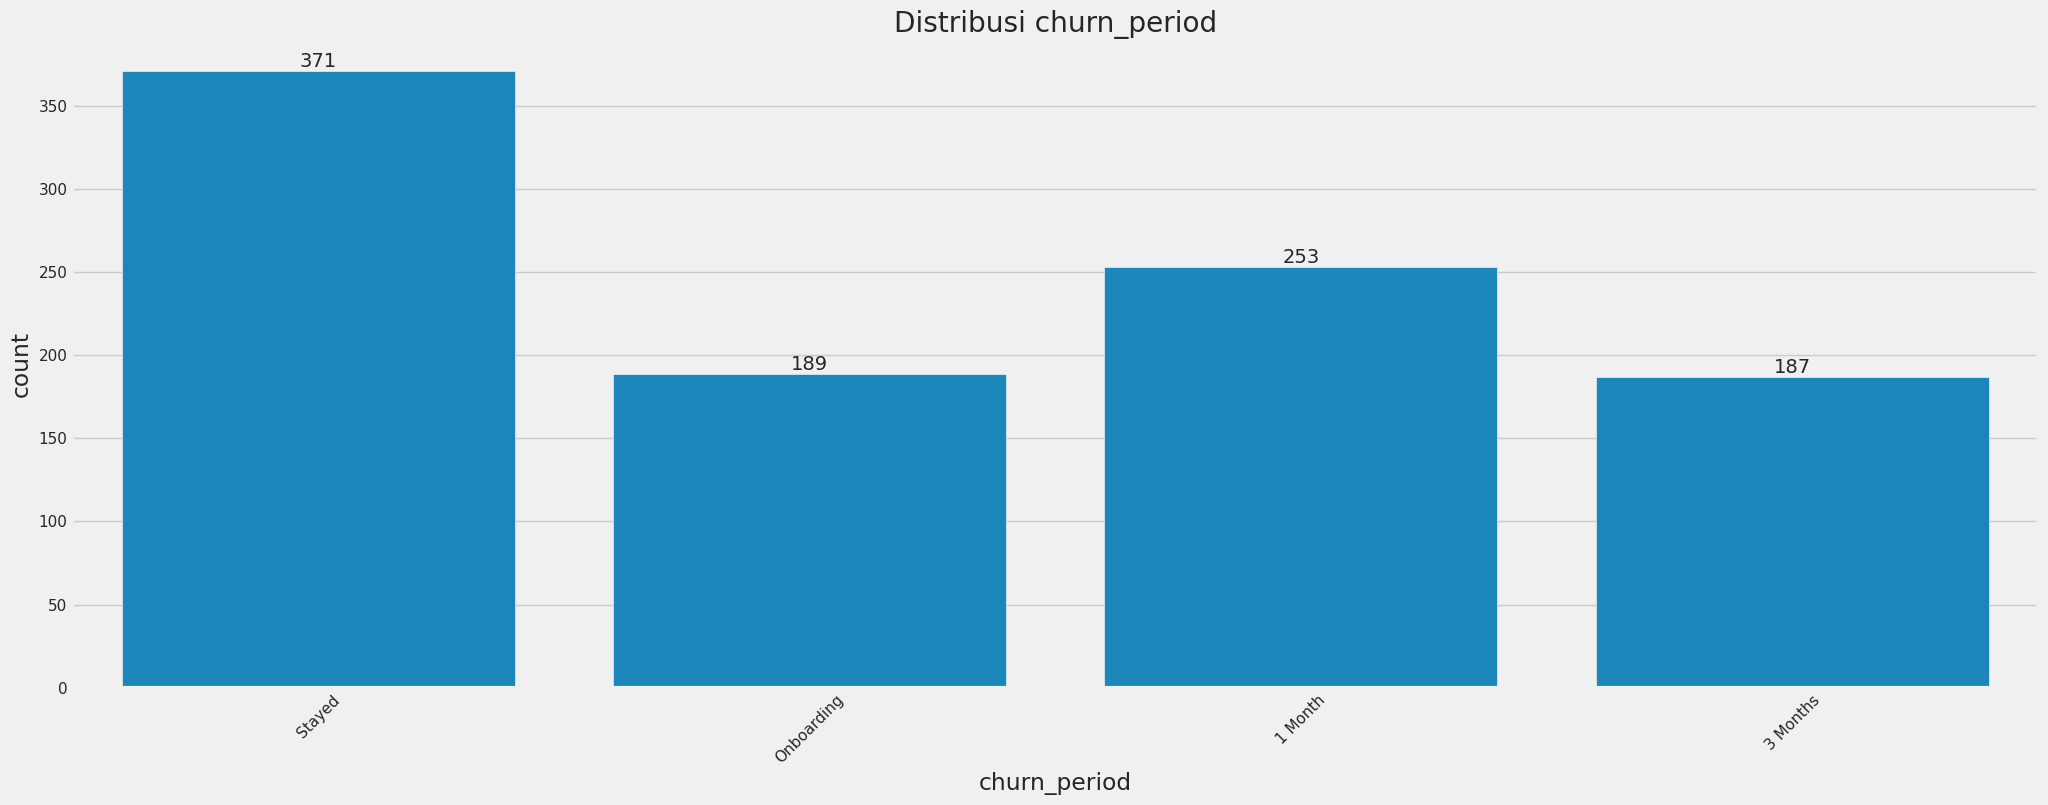

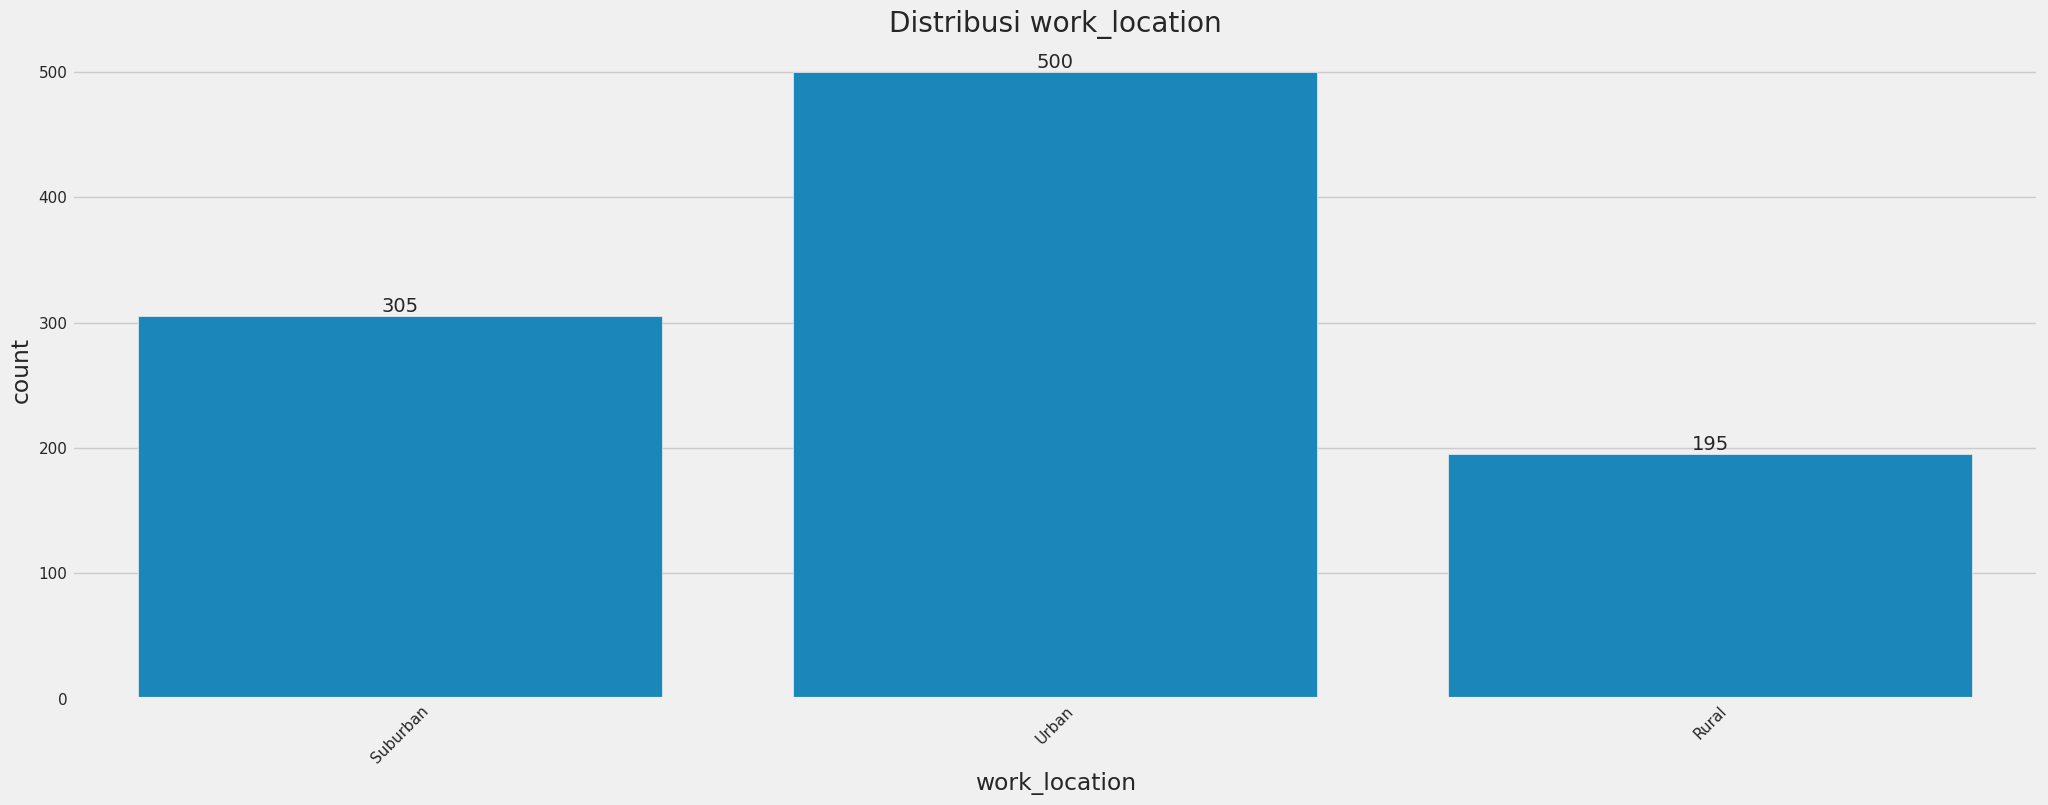

In [ ]:
# === 1) UNIVARIATE ANALYSIS – KATEGORIKAL ===
for col in cat_bertingkat:
    plt.figure()
    ax = sns.countplot(data=df, x=col)
    ax.bar_label(ax.containers[0])  # langsung munculin angka di atas bar
    plt.title(f"Distribusi {col}")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

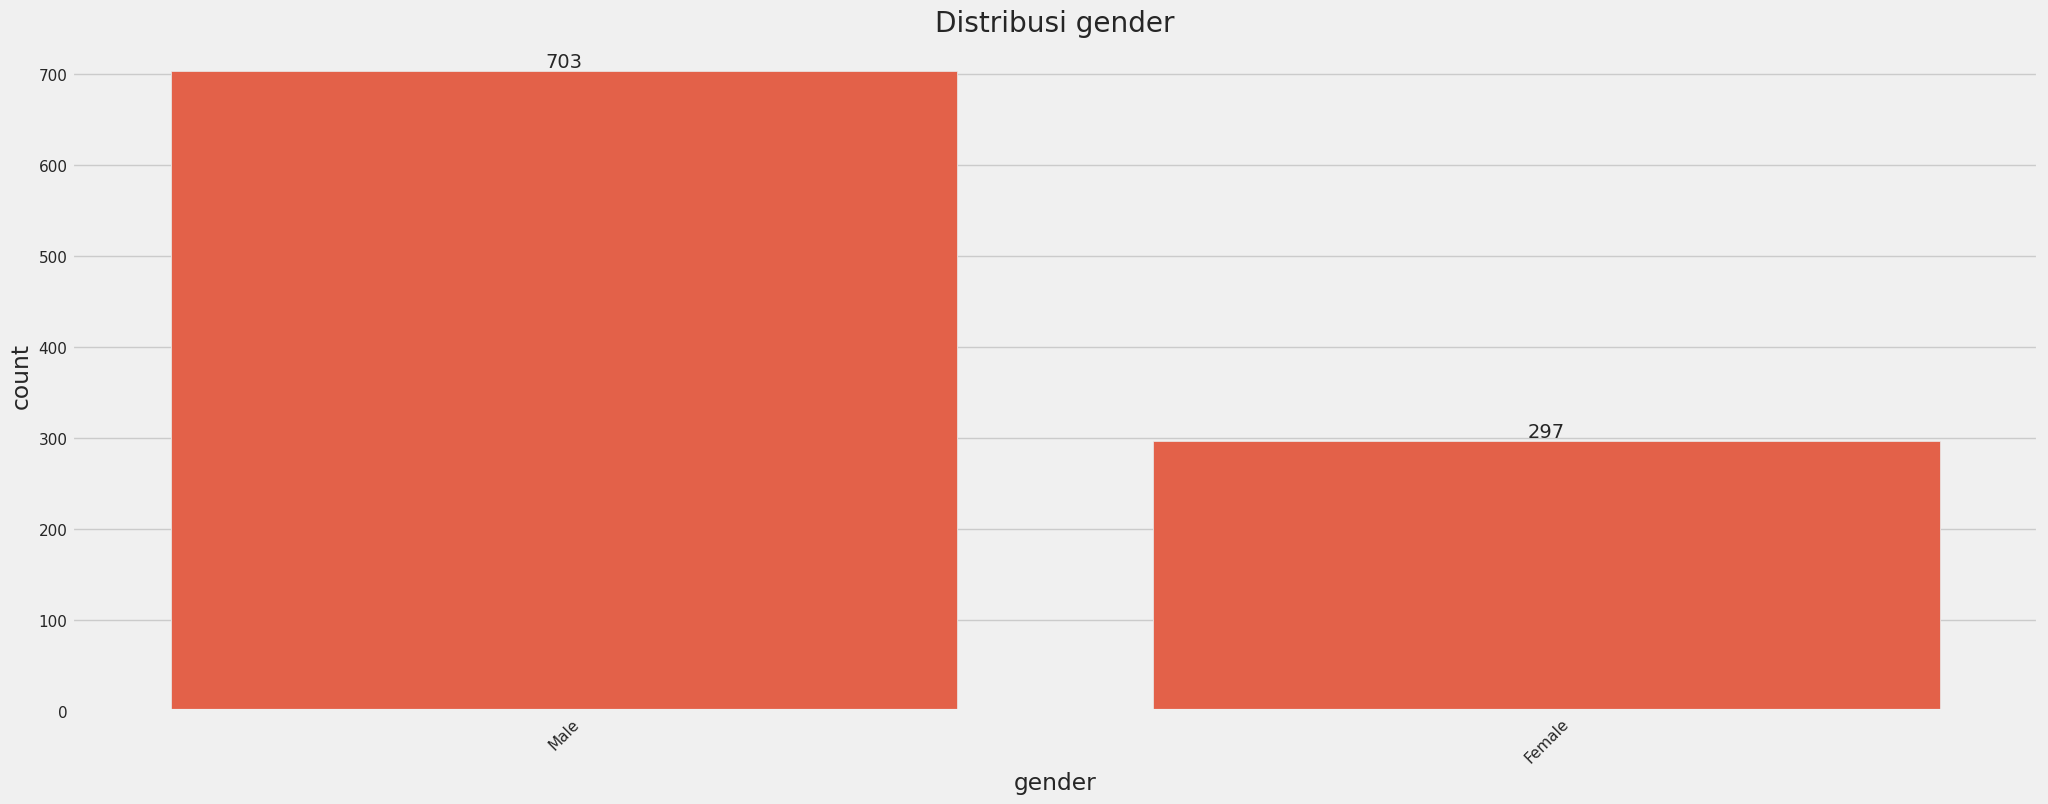

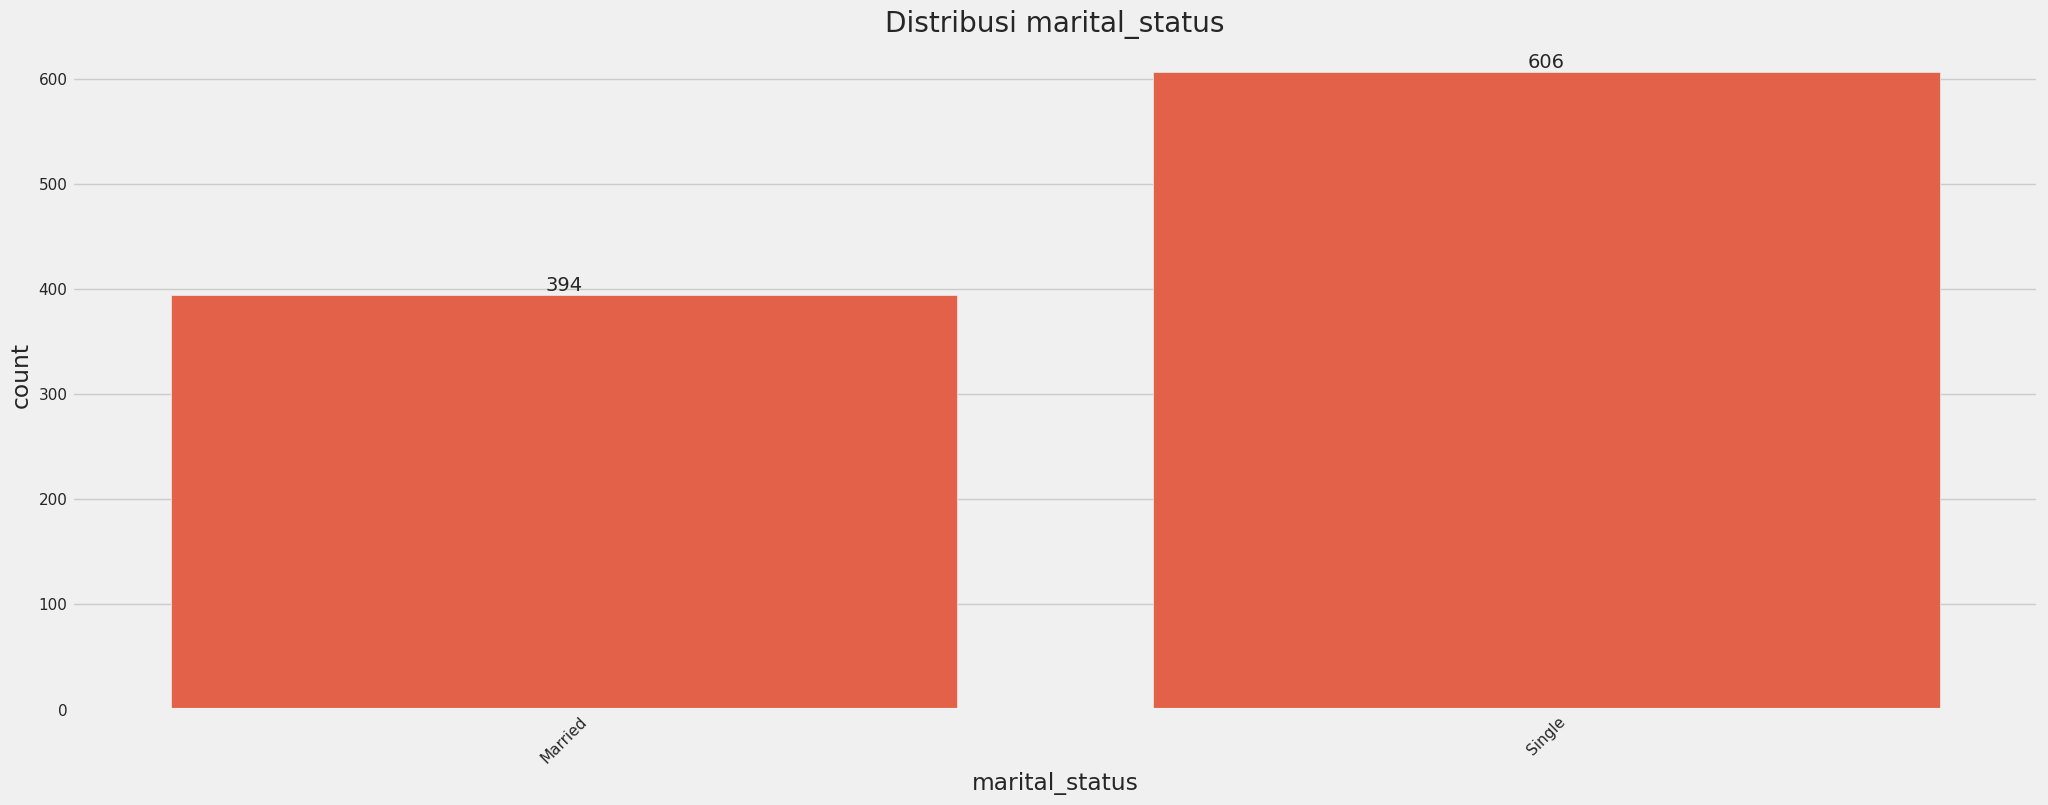

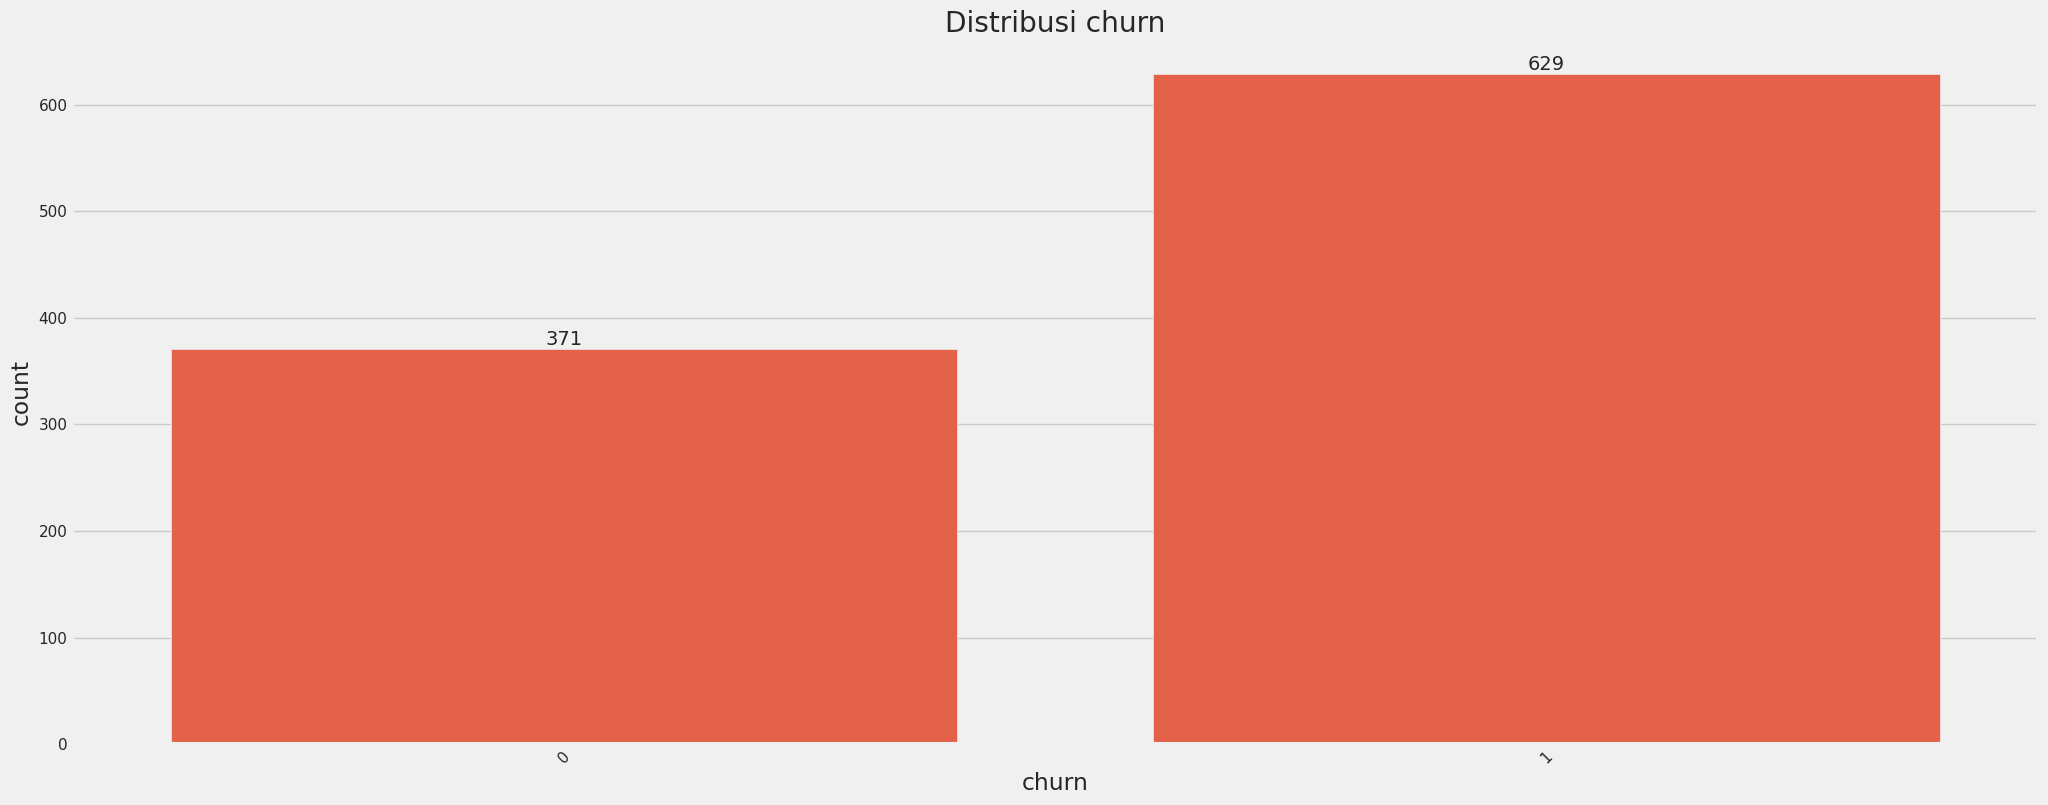

In [ ]:
for col in cat_biasa:
    plt.figure()
    ax = sns.countplot(data=df, x=col)
    ax.bar_label(ax.containers[0])  # langsung munculin angka di atas bar
    sns.countplot(data=df, x=col)
    plt.title(f"Distribusi {col}")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

1. Education
Distribusi cukup seimbang antara High School, Diploma, dan Bachelor, tapi Diploma punya jumlah paling banyak.

2. Work Location
Urban memiliki jumlah karyawan terbanyak, diikuti Suburban, dan paling sedikit Rural.

4. Gender
Male mendominasi jumlah karyawan secara signifikan dibanding Female (lebih dari dua kali lipat). Implikasi: Potensi bias gender dalam retensi dan rekrutmen. Perlu dicek apakah tingkat churn berbeda antara male dan female.

5. Marital Status
Single memiliki jumlah karyawan lebih banyak dibanding Married. Implikasi: Perbedaan status pernikahan bisa memengaruhi alasan resign, misalnya fleksibilitas kerja, lokasi, atau benefit.


## Multivariate Analysis

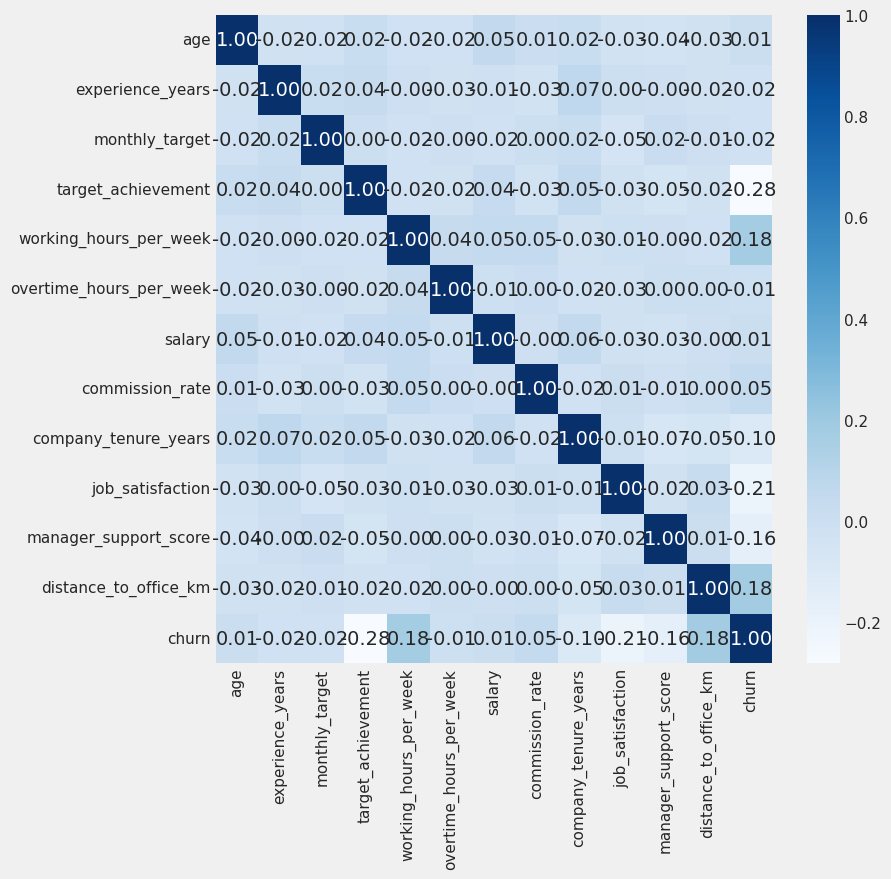

In [ ]:
# Heat Map
plt.figure(figsize=(8, 8))
sns.heatmap(df[(nums)].corr(), cmap='Blues', annot=True, fmt='.2f')
plt.show()

* Faktor terbesar penyebab churn di data ini adalah kinerja rendah (target achievement), kepuasan kerja rendah, dan dukungan manajer yang kurang.

* Faktor beban kerja & geografis seperti jam kerja tinggi dan jarak ke kantor jauh juga signifikan.

* Gaji & komisi tidak punya korelasi berarti (mendekati nol).

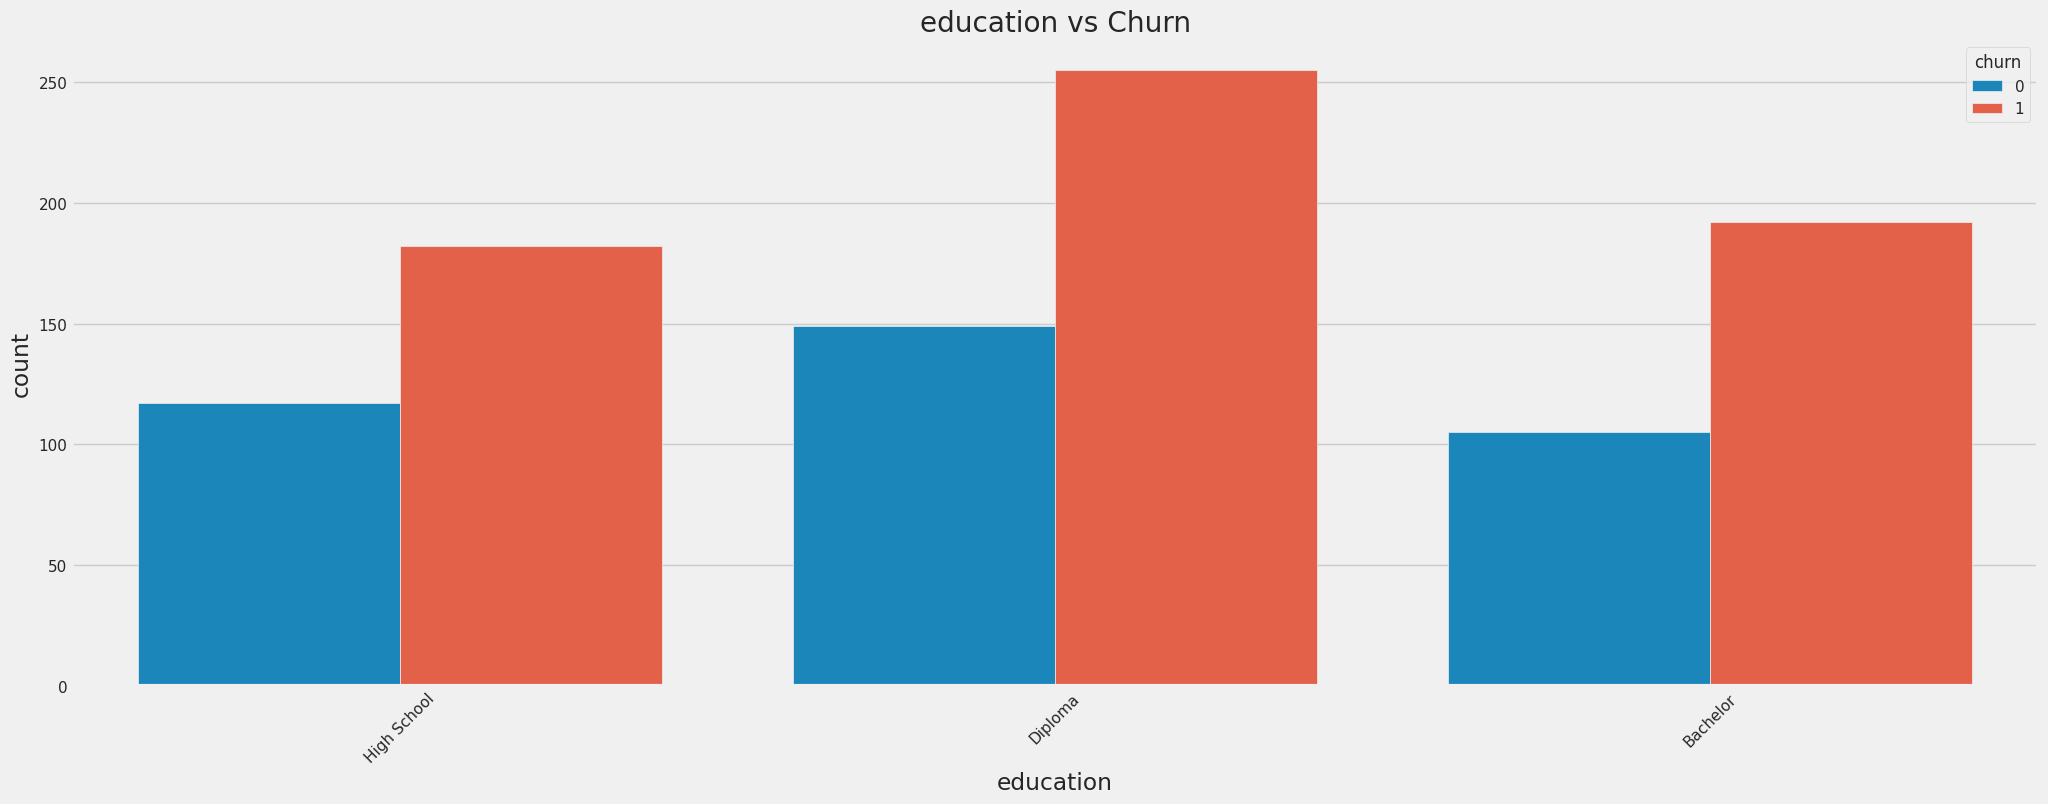

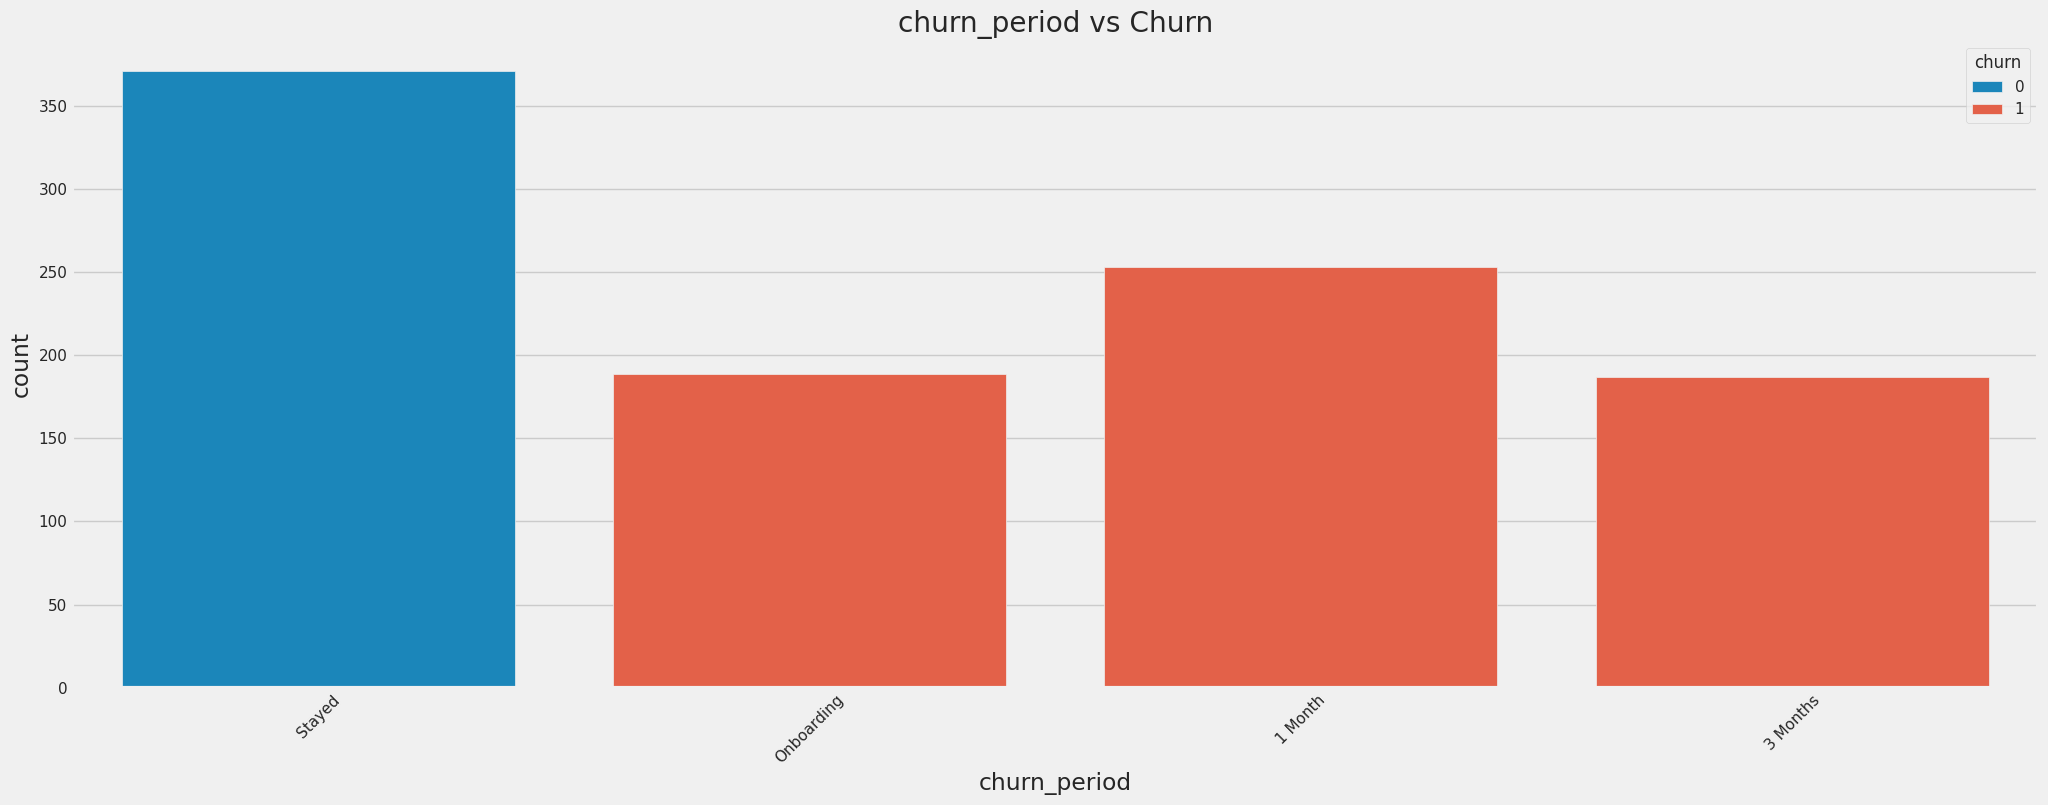

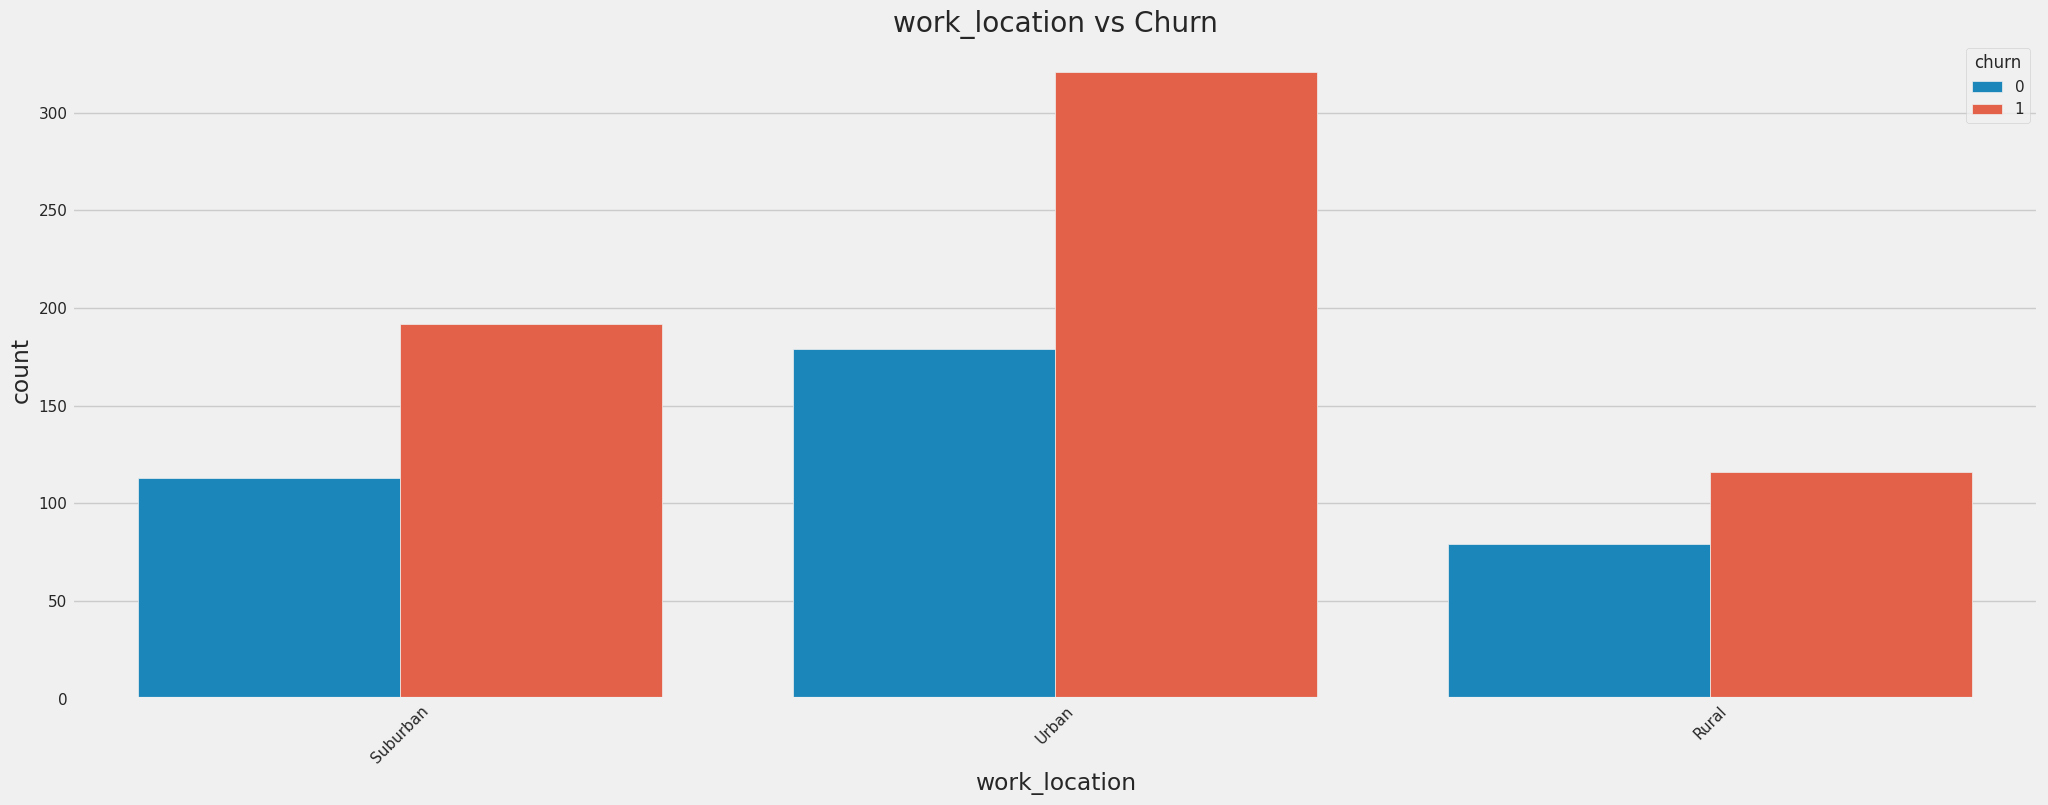

In [ ]:
# === 3) MULTIVARIATE – KATEGORIKAL vs TARGET ===
for col in cat_bertingkat:
    plt.figure()
    sns.countplot(data=df, x=col, hue='churn')
    plt.title(f"{col} vs Churn")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

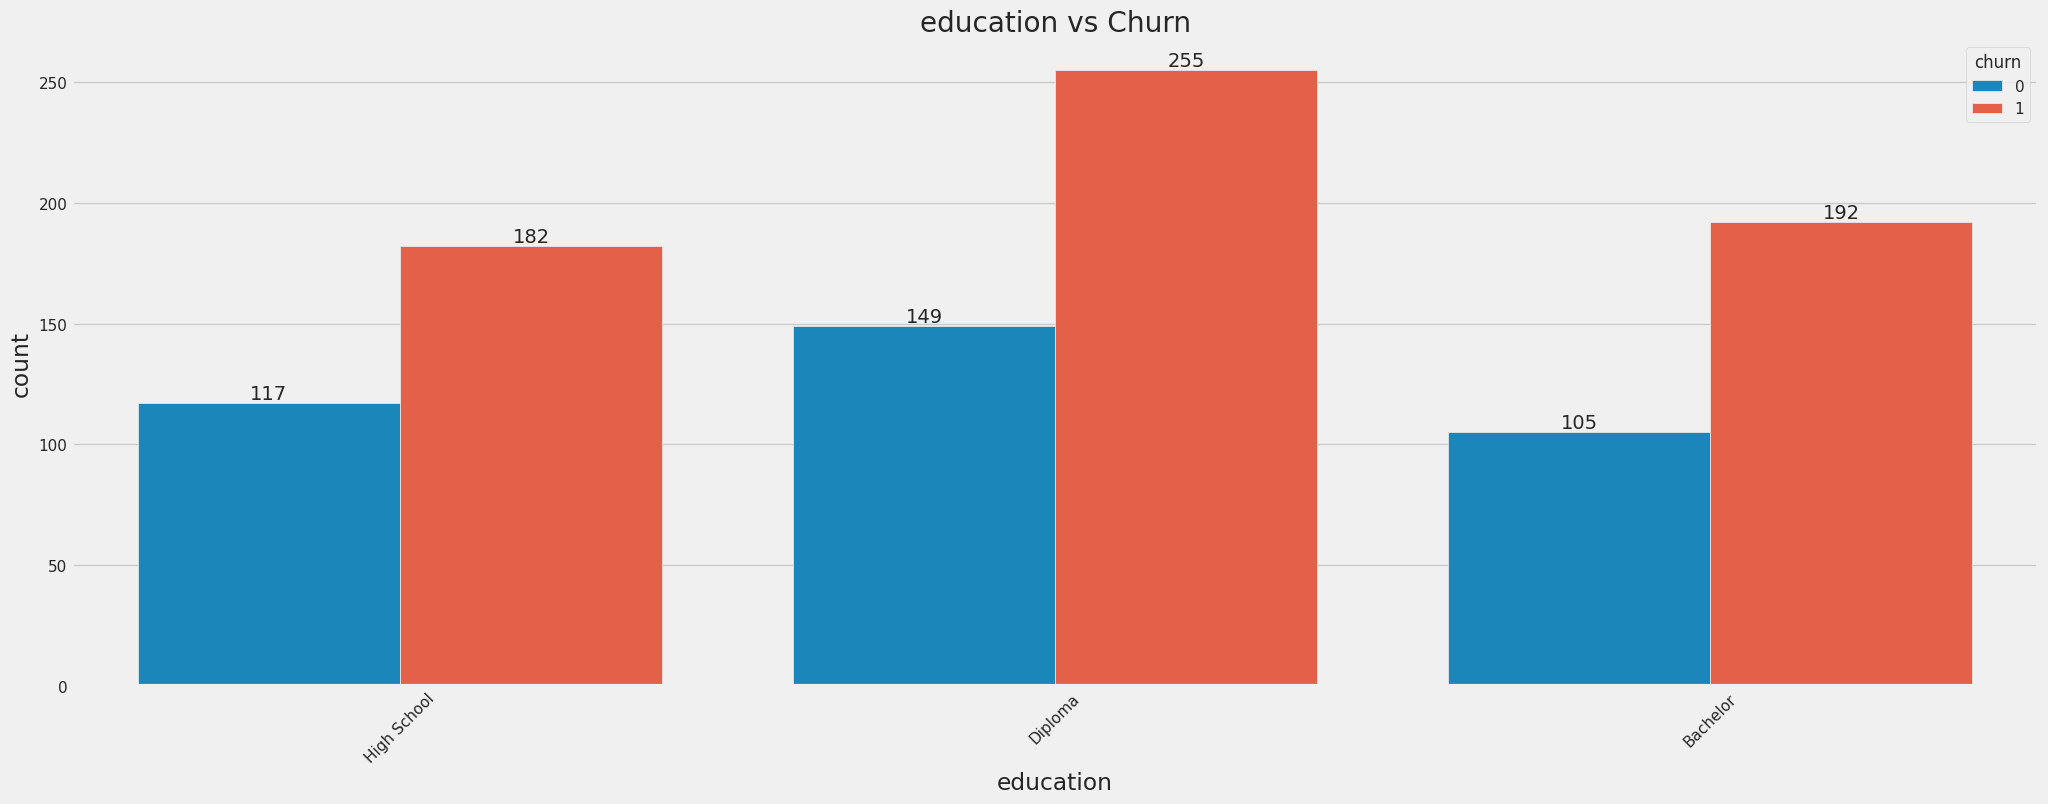

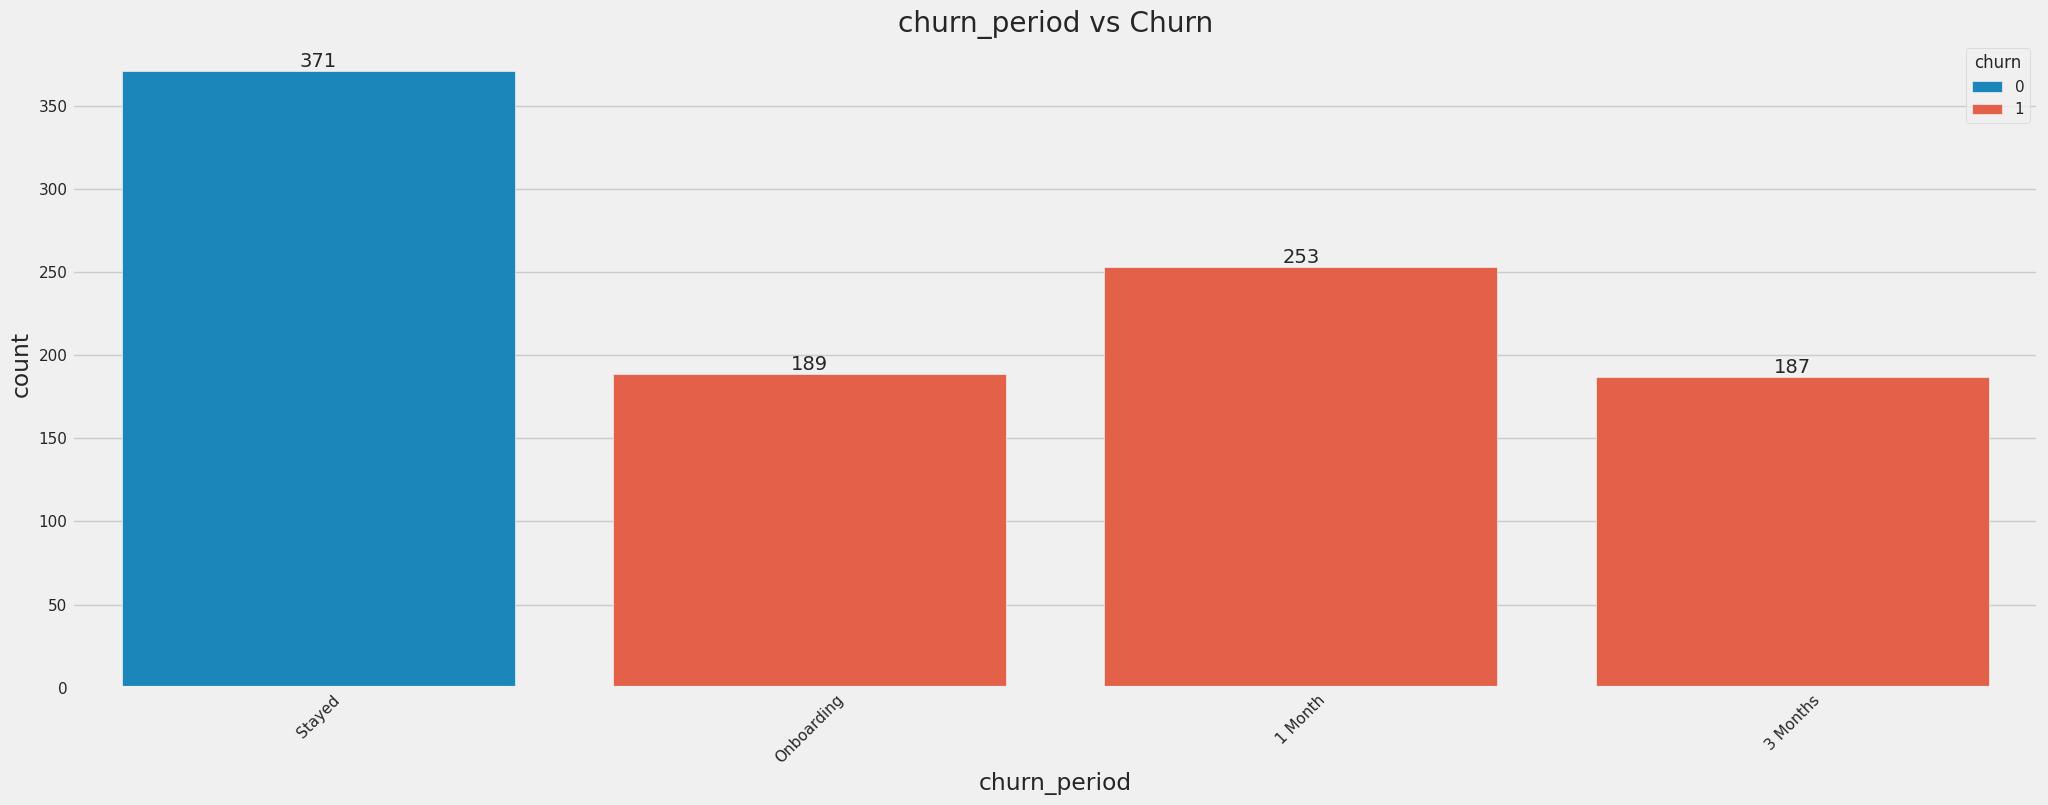

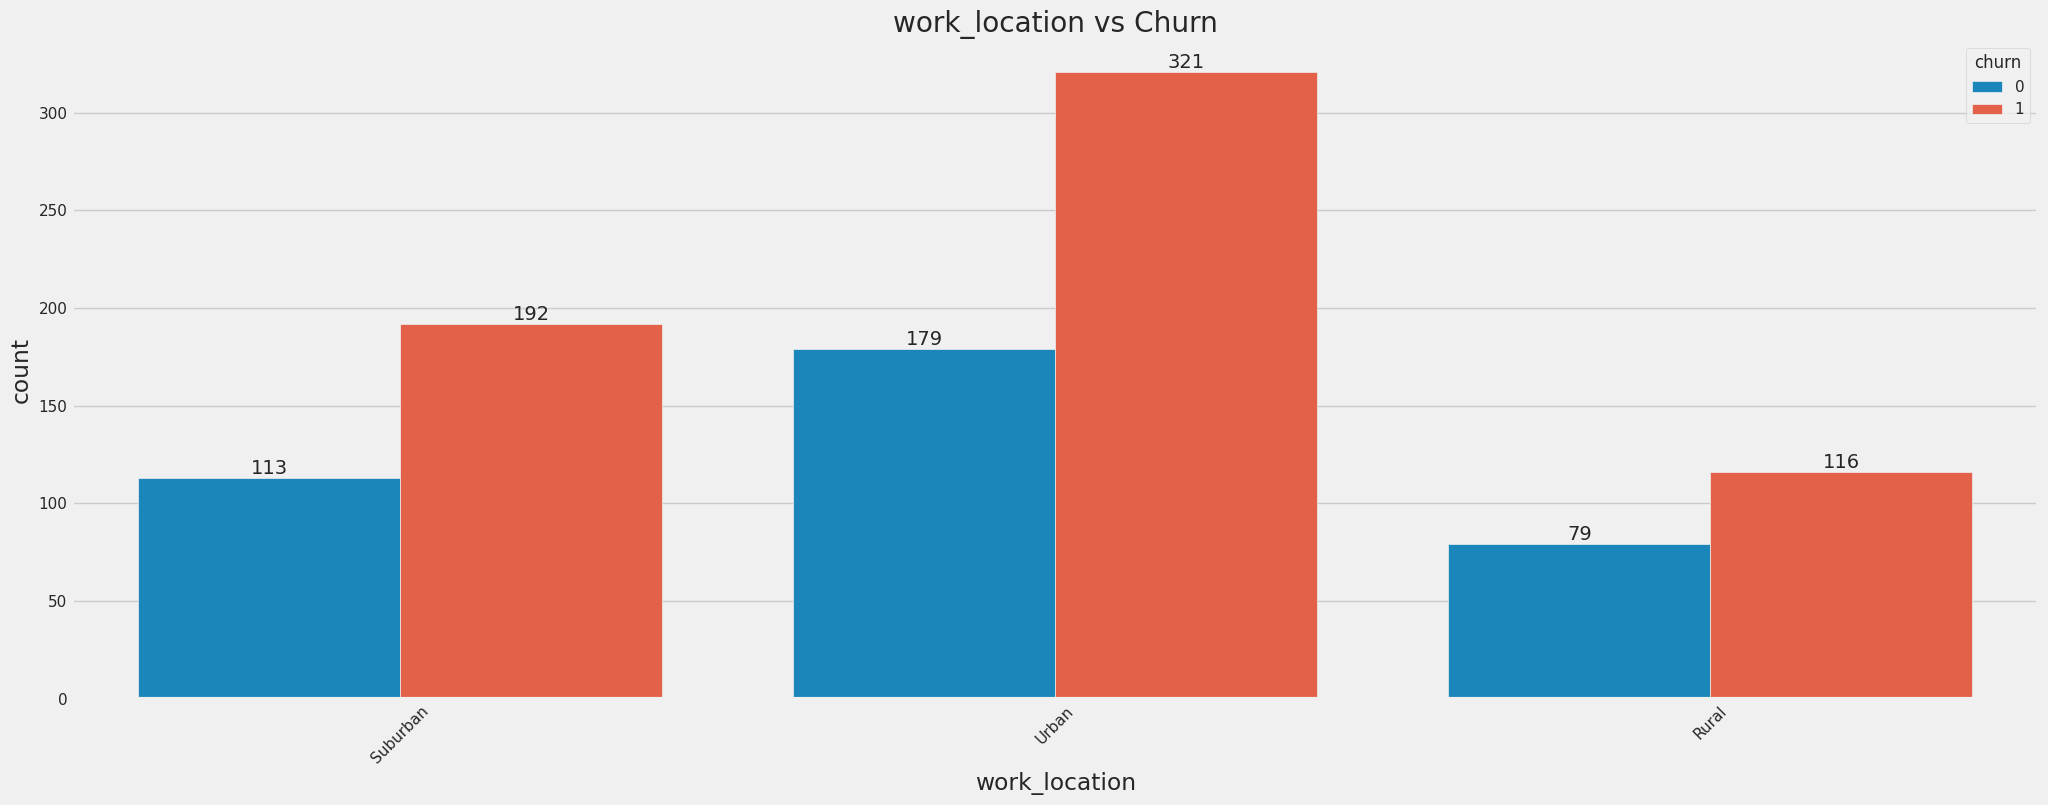

In [ ]:
for col in cat_bertingkat:
    plt.figure()
    ax = sns.countplot(data=df, x=col, hue='churn')

    # Tambahin angka di atas semua bar
    for container in ax.containers:
        ax.bar_label(container)

    plt.title(f"{col} vs Churn")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()


<Figure size 1500x1500 with 0 Axes>

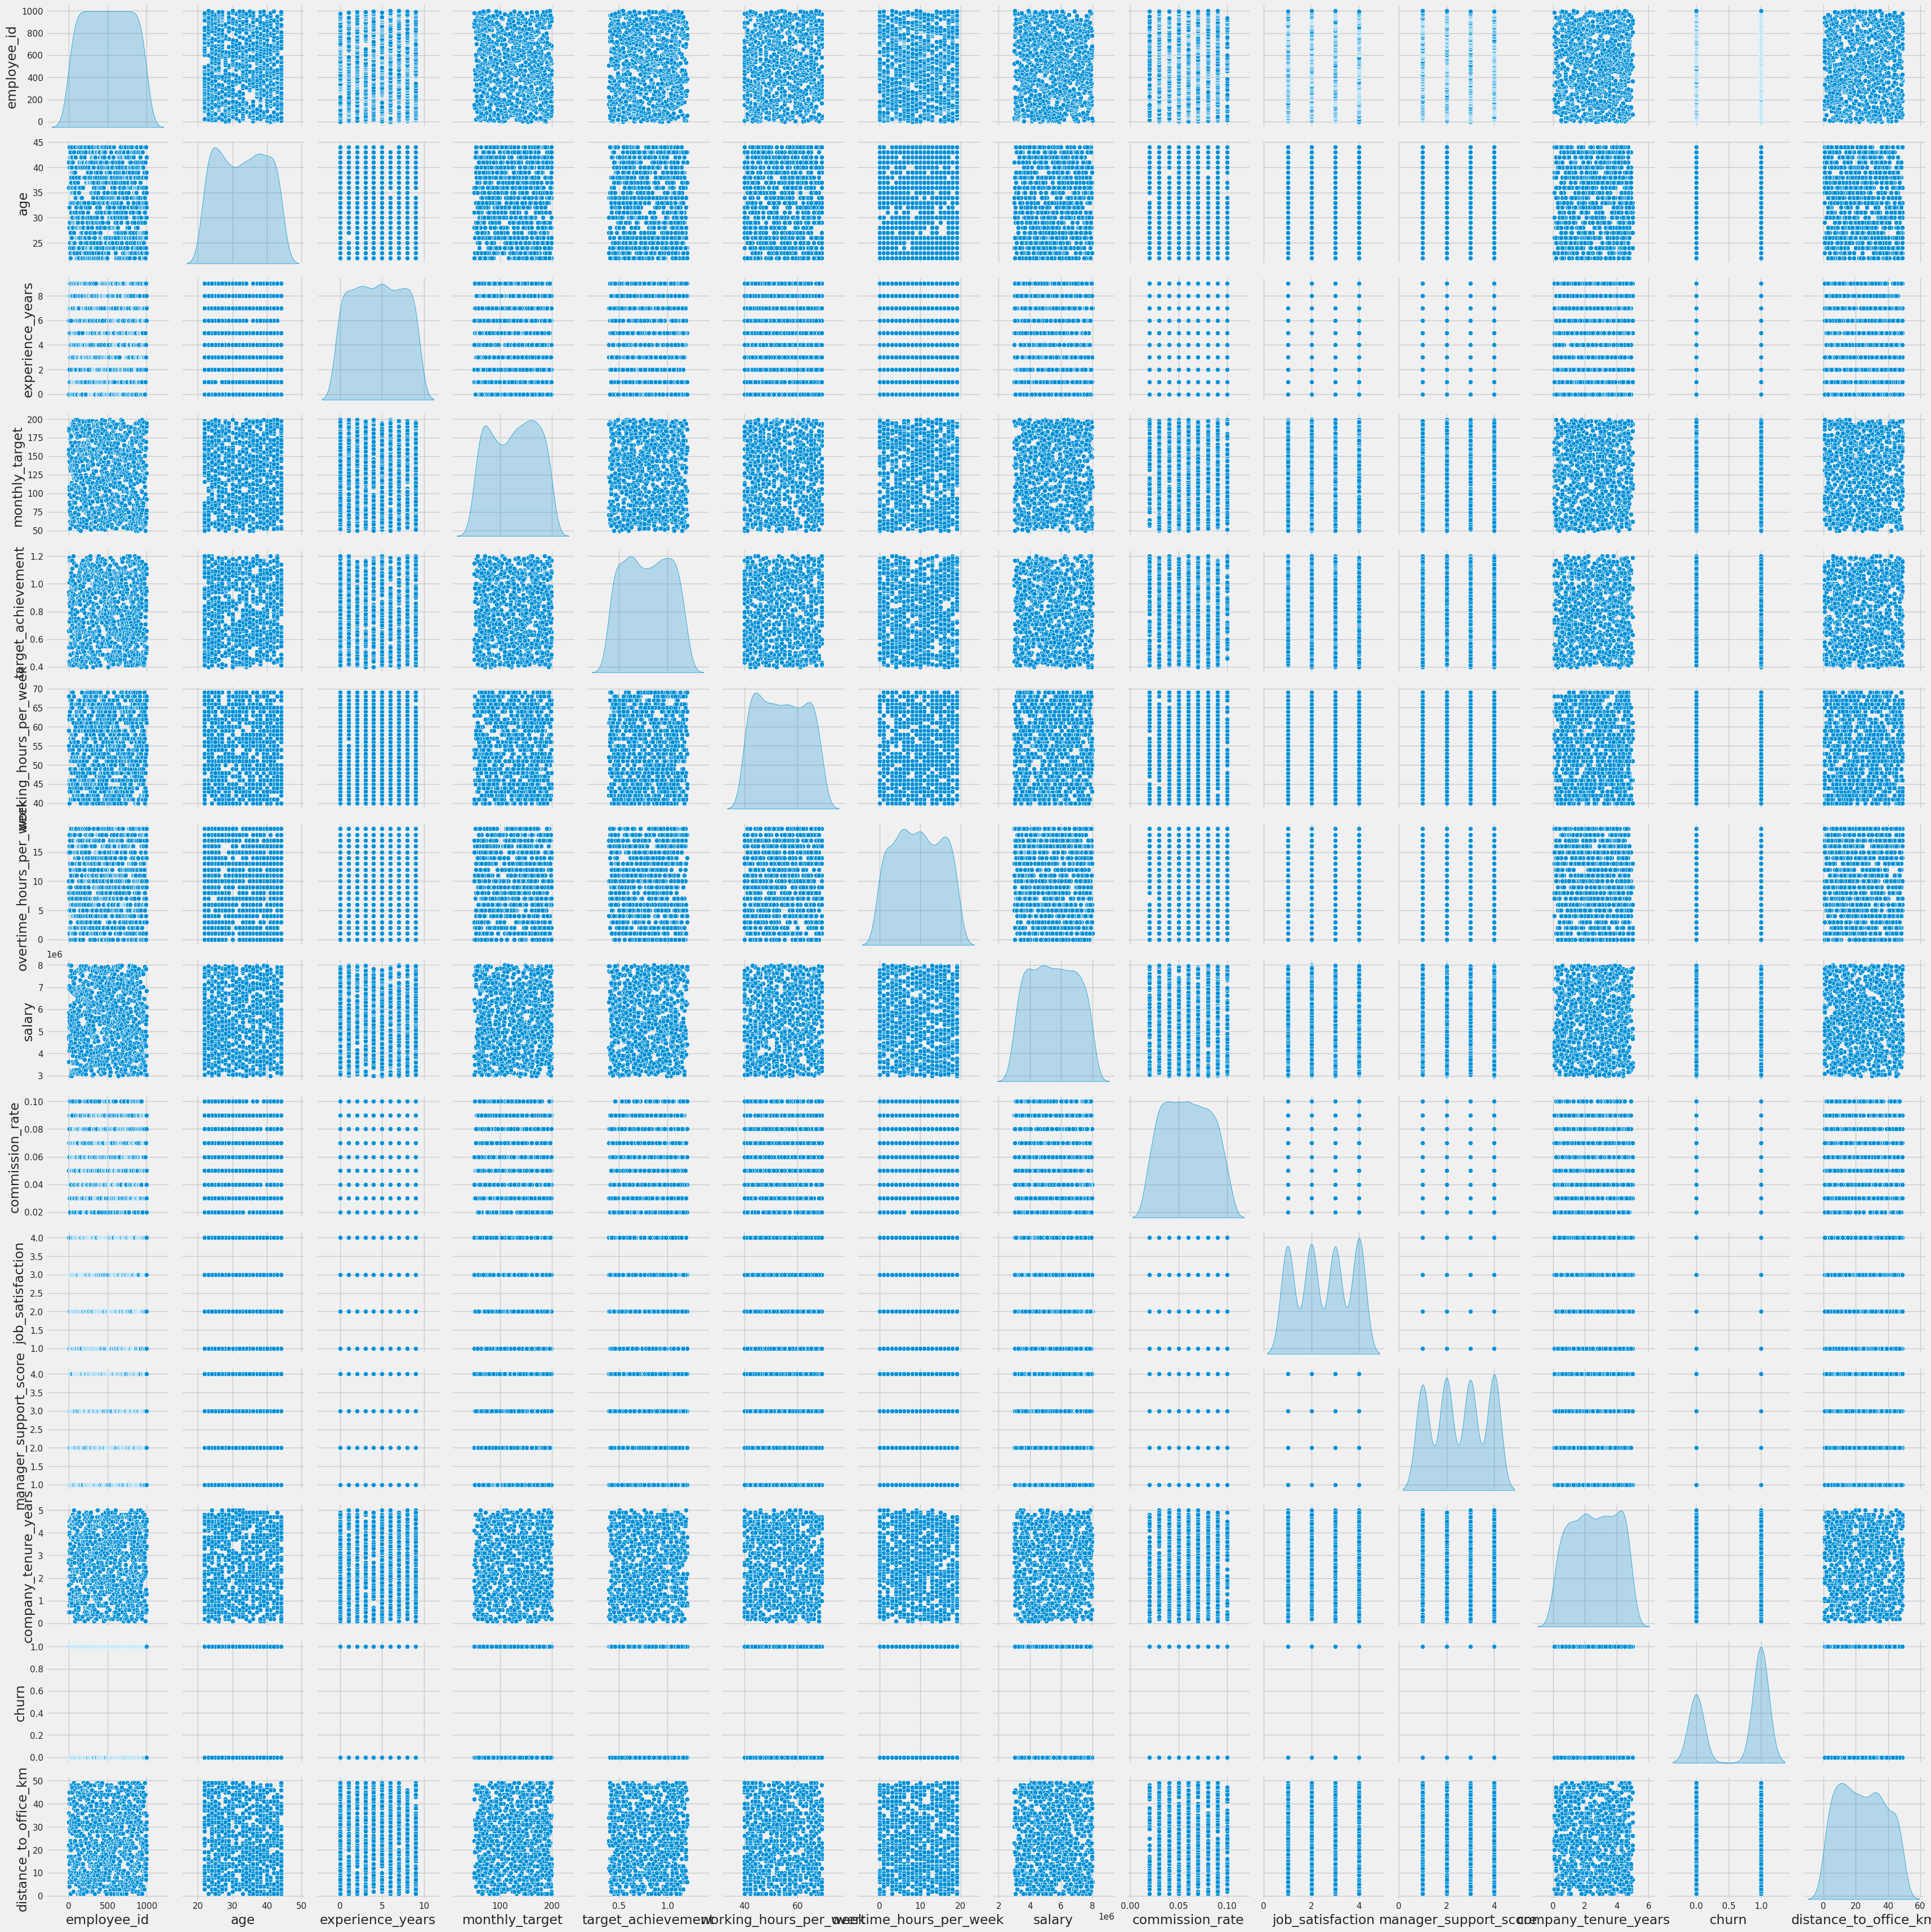

In [ ]:
# Pair Plot
plt.figure(figsize=(15, 15))
sns.pairplot(df, diag_kind='kde')
plt.show()

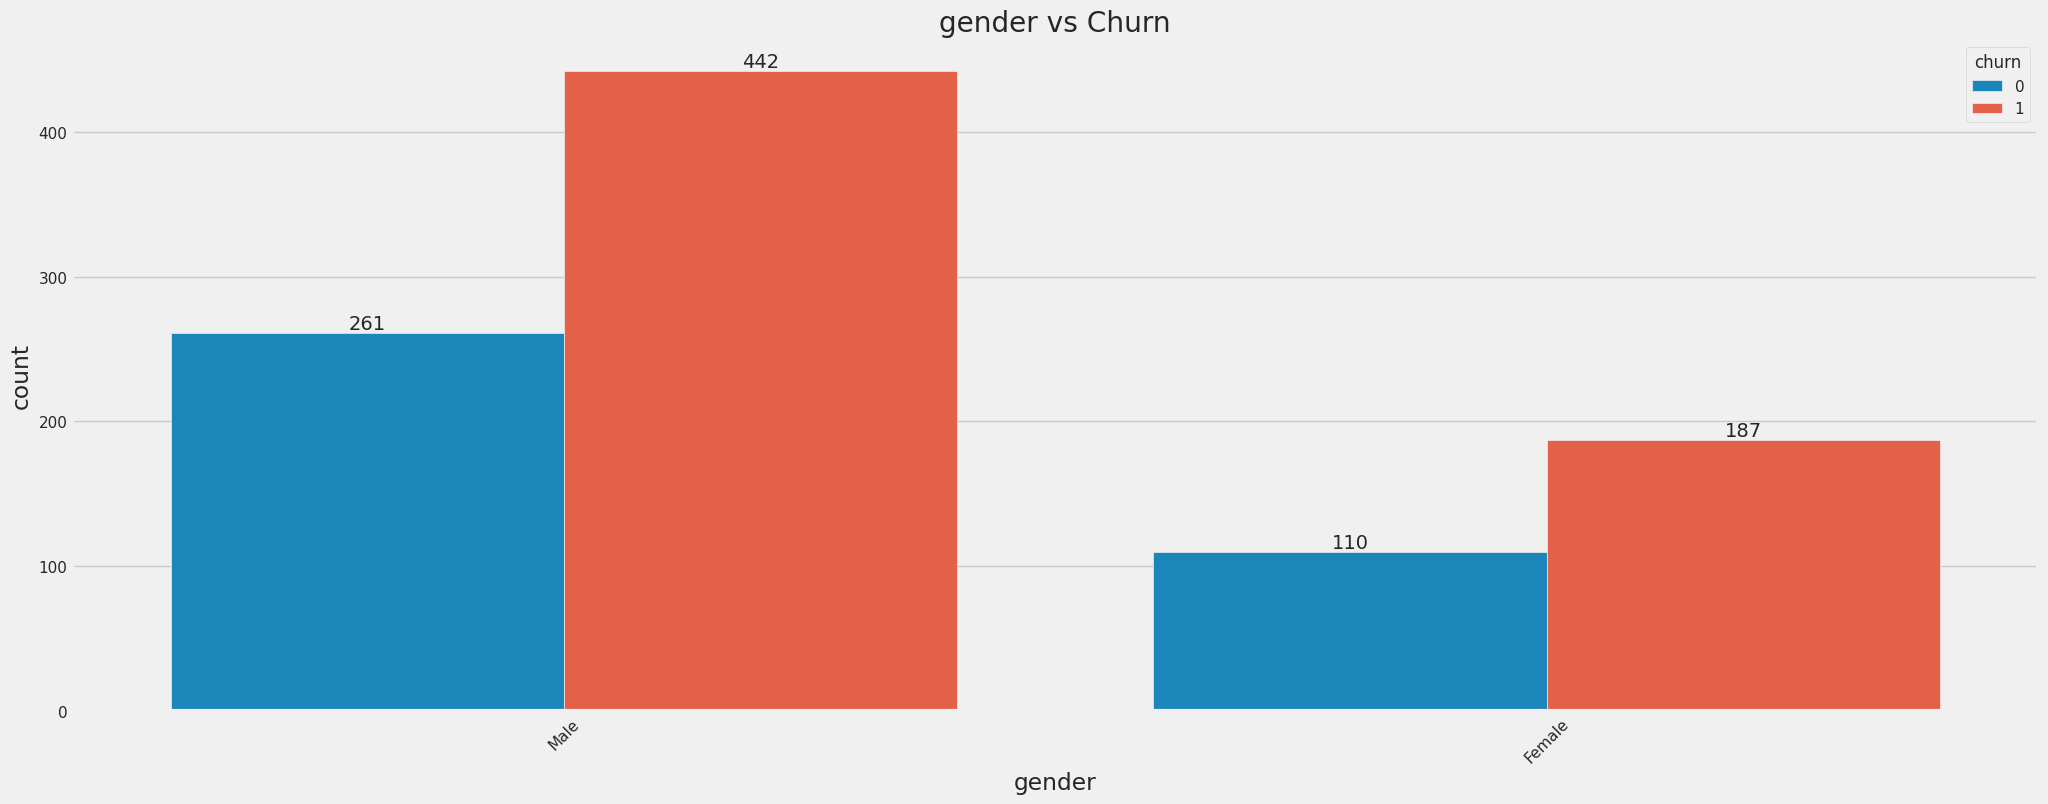

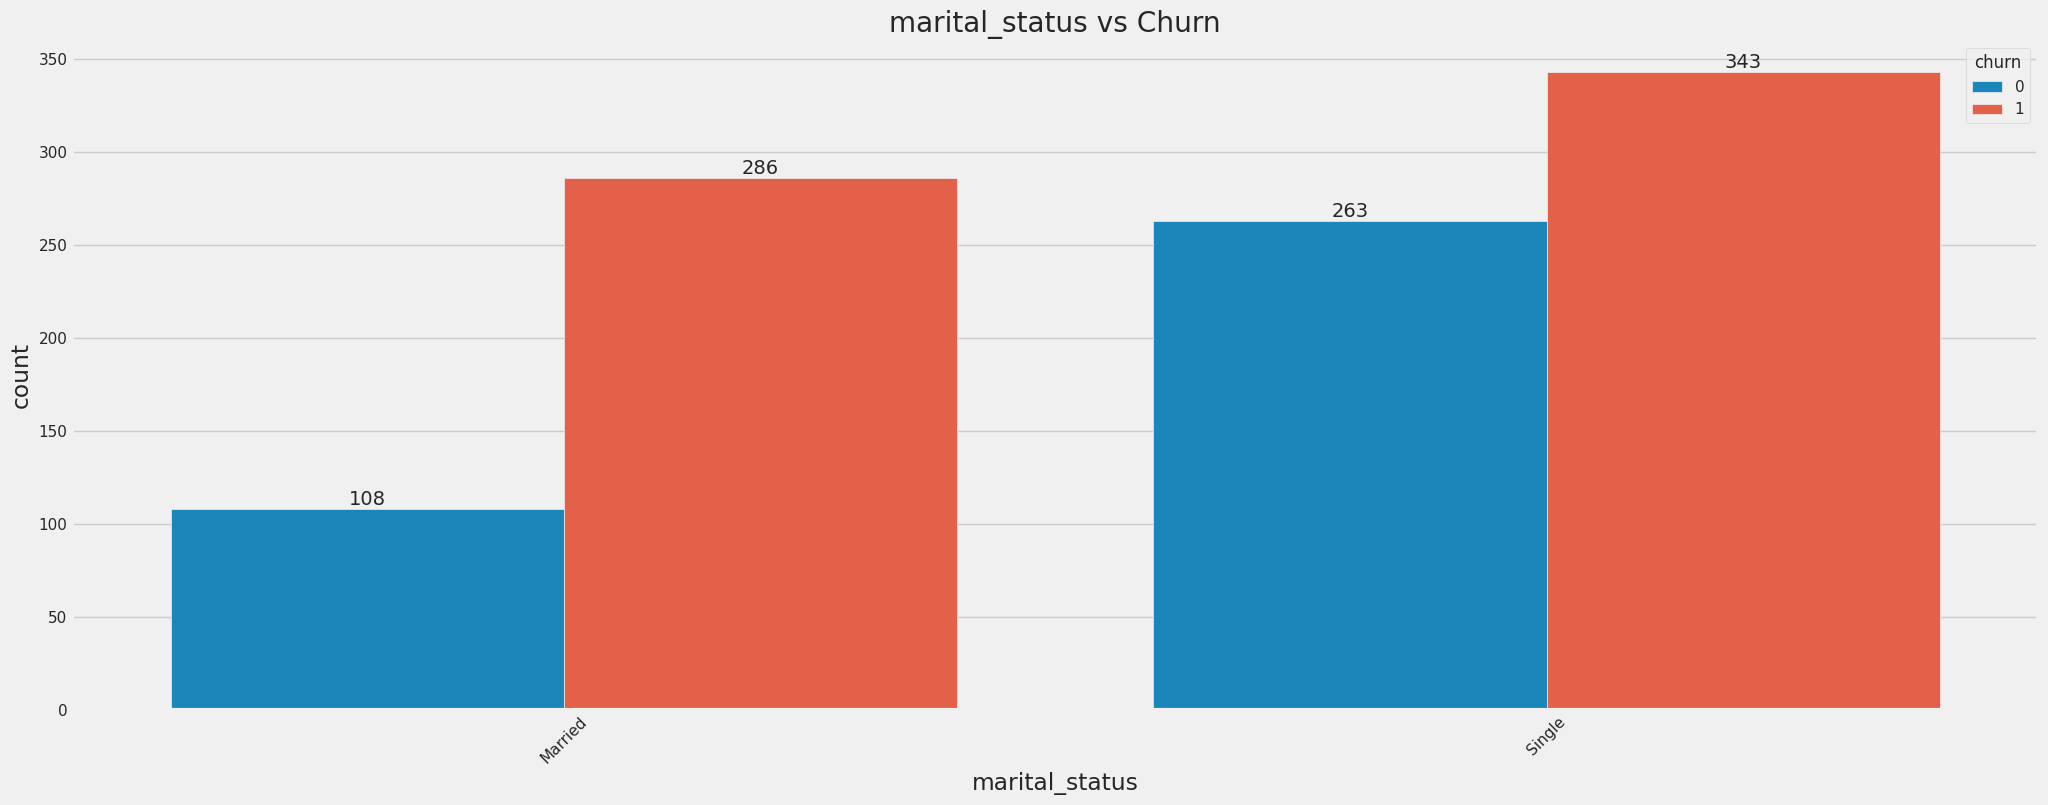

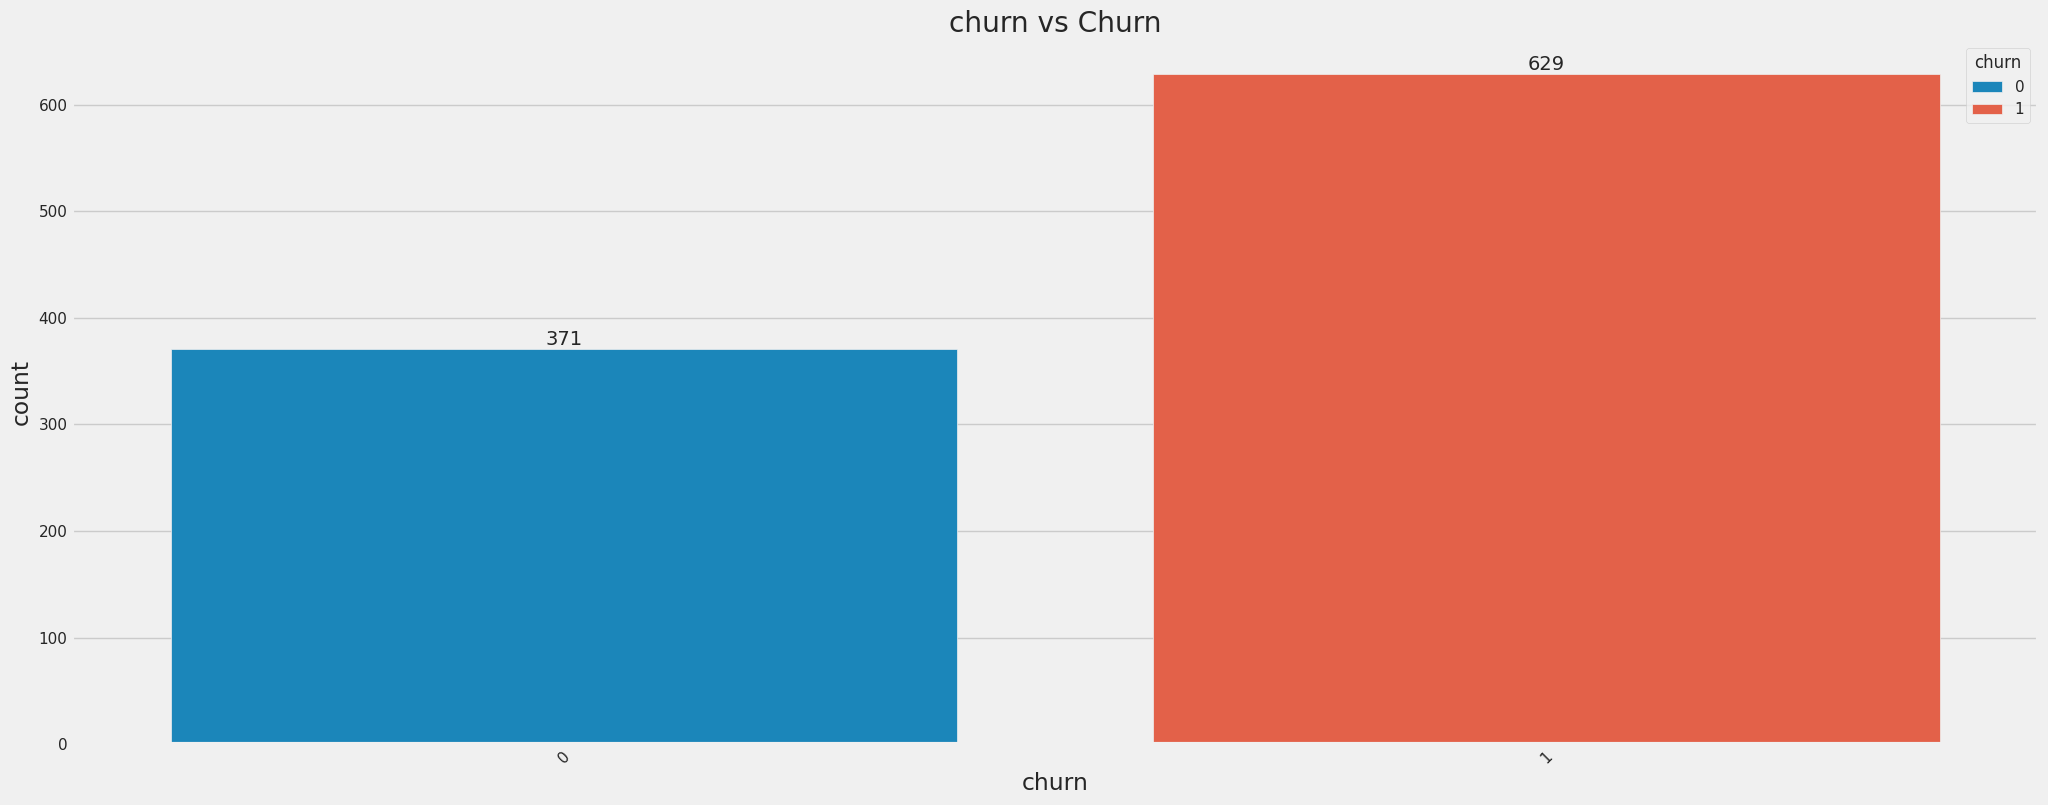

In [ ]:
for col in cat_biasa:
    plt.figure()
    ax = sns.countplot(data=df, x=col, hue='churn')

    # Tambahin angka di atas semua bar
    for container in ax.containers:
        ax.bar_label(container)

    plt.title(f"{col} vs Churn")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()


1. Education vs Churn
* High School → Proporsi karyawan yang churn cukup tinggi, walaupun ada juga yang bertahan.

* Diploma → Tingkat churn terlihat lebih tinggi dibandingkan yang bertahan, artinya lulusan Degree cenderung lebih sering keluar.

* Baachelor → Mirip dengan Degree, churn juga lebih dominan. Ini bisa menandakan ekspektasi karir/gaji yang lebih tinggi atau peluang kerja di luar yang lebih menarik.

* Latar belakang pendidikan yang lebih tinggi belum tentu membuat retensi lebih baik. Perlu strategi khusus untuk menjaga talenta dengan kualifikasi tinggi, seperti jalur karir jelas atau program pengembangan.
<br>

2. Churn Period vs Churn
* Churn paling besar terjadi pada 1 month dan 3 months pertama.

* Stayed didominasi oleh karyawan yang tidak churn sama sekali.

* Banyak churn di periode onboarding, yang menandakan masalah adaptasi di awal kerja.

* Interpretasi bisnis: Perlu peningkatan kualitas onboarding, mentoring awal, dan komunikasi ekspektasi kerja sejak awal untuk mengurangi churn di 3 bulan pertama.
<br>

3. Work Location vs Churn
* Urban → Churn sangat tinggi, kemungkinan karena peluang kerja lain lebih mudah diakses.

* Suburban dan Rural → Masih churn, tapi lebih sedikit dibandingkan Urban.

* Interpretasi bisnis: Karyawan di area urban lebih “mobile” dan mudah pindah kerja. Strategi retensi di kota besar perlu lebih kompetitif (benefit, fleksibilitas, gaji).
<br>

4. Gender vs Churn
* Male → Churn jauh lebih tinggi dibanding bertahan.

* Female → Churn juga tinggi, tapi jumlahnya tidak sebesar male.

* Interpretasi bisnis: Perlu melihat faktor lain yang mungkin memengaruhi churn laki-laki (beban kerja, jenis pekerjaan, peluang di luar).
<br>

5. Marital Status vs Churn
* Married → Churn tinggi, bahkan lebih tinggi dari yang bertahan.

* Single → Churn juga tinggi, tapi distribusi lebih seimbang dengan yang bertahan.

* Interpretasi bisnis: Status menikah tidak menjamin retensi. Perlu analisis faktor eksternal (misal lokasi kerja jauh dari rumah atau fleksibilitas waktu kerja).

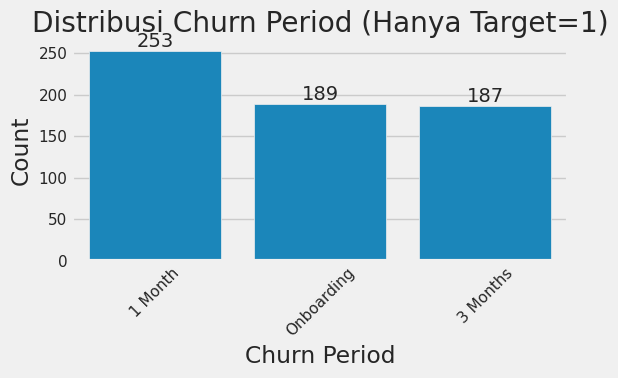

In [ ]:
# === 4) ANALISIS KHUSUS TARGET=1 vs CHURN PERIOD ===
import seaborn as sns
import matplotlib.pyplot as plt

# Subset hanya karyawan yang churn
df_churned = df[df['churn'] == 1]

# Distribusi churn_period (hanya churn=1)
plt.figure(figsize=(6,4))
ax = sns.countplot(data=df_churned, x='churn_period', order=df_churned['churn_period'].value_counts().index)

# Tambahin angka di atas semua bar
for container in ax.containers:
    ax.bar_label(container)

plt.title("Distribusi Churn Period (Hanya Target=1)")
plt.xlabel("Churn Period")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


Berdasarkan grafik distribusi churn_period untuk karyawan yang churn (target=1):

* Puncak churn terjadi pada bulan pertama bekerja dengan jumlah kasus paling tinggi dibandingkan periode onboarding maupun 3 bulan.

* Churn pada periode onboarding dan 3 bulan hampir sama jumlahnya, tapi sedikit lebih rendah daripada churn di bulan pertama.

* Pola ini menunjukkan bahwa masa-masa kritis retensi karyawan adalah 1–3 bulan pertama, dengan risiko terbesar pada bulan pertama setelah melewati masa onboarding.

💡 Interpretasi bisnis:

* Perusahaan perlu memperkuat program pendampingan dan engagement khusus di bulan pertama kerja.

* Evaluasi penyebab churn pasca-onboarding, seperti ketidaksesuaian ekspektasi kerja, beban kerja awal, atau kurangnya dukungan dari atasan.

* Menerapkan check-in rutin (misalnya, weekly feedback session) pada 1–3 bulan awal bisa membantu mengidentifikasi masalah sebelum karyawan memutuskan keluar.

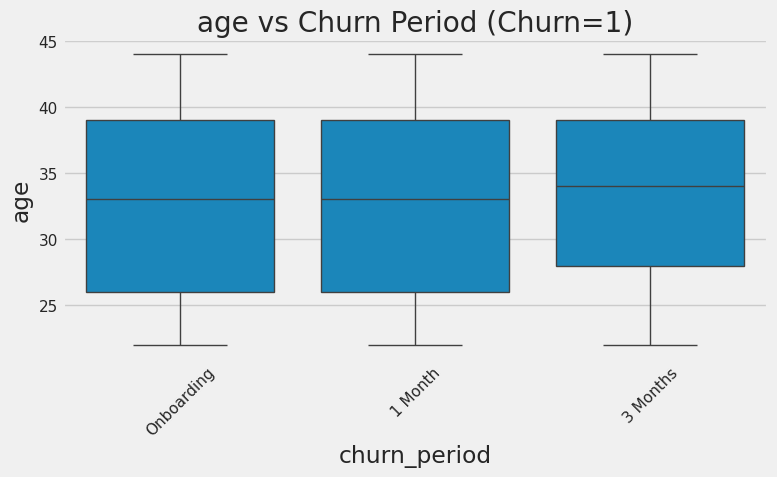

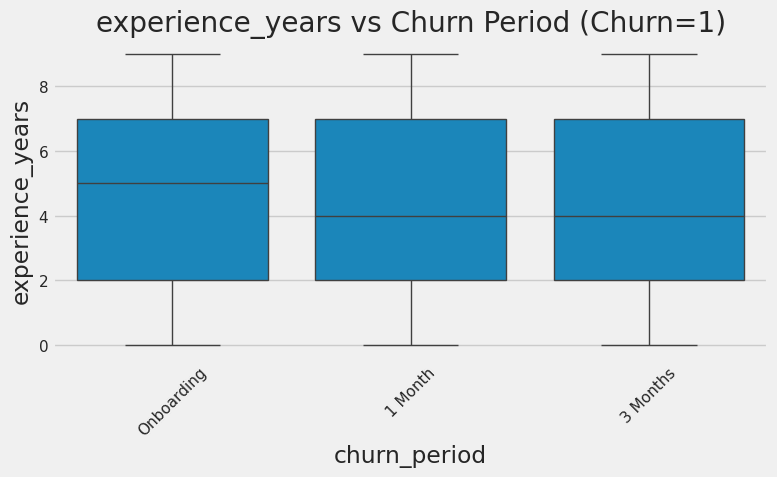

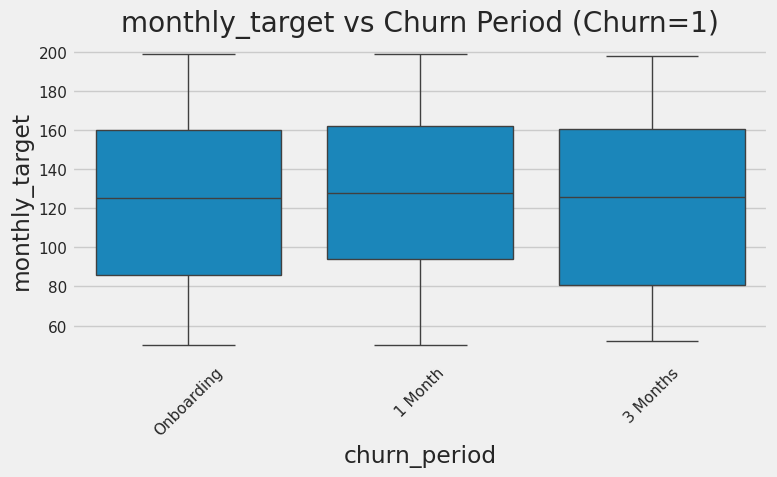

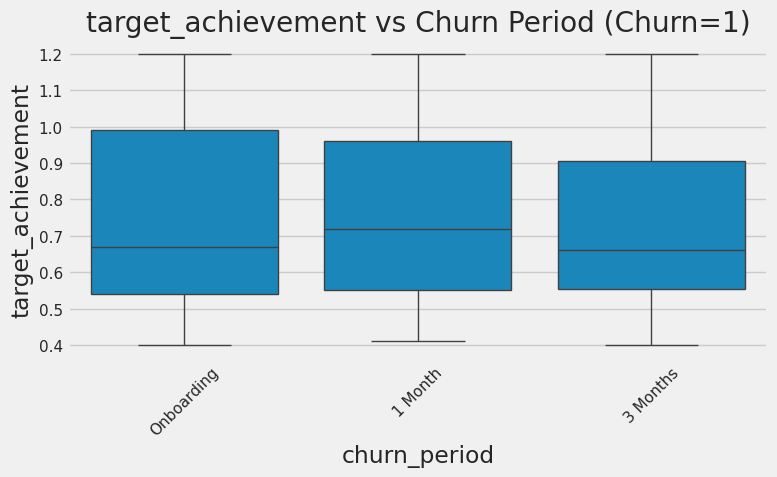

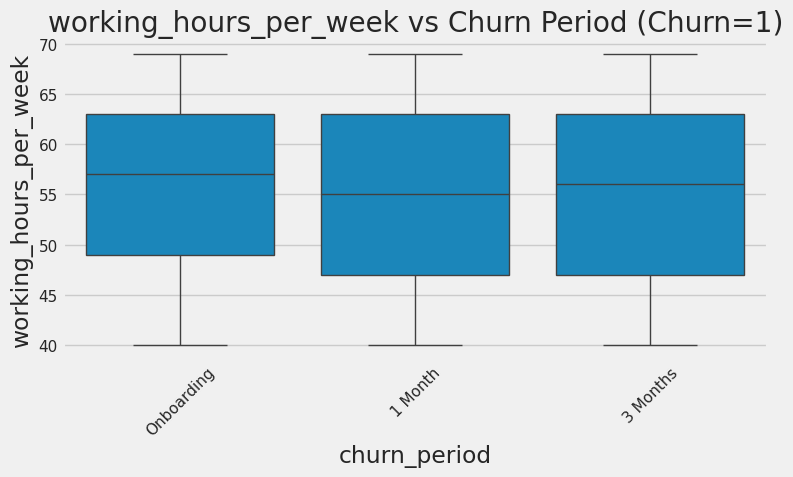

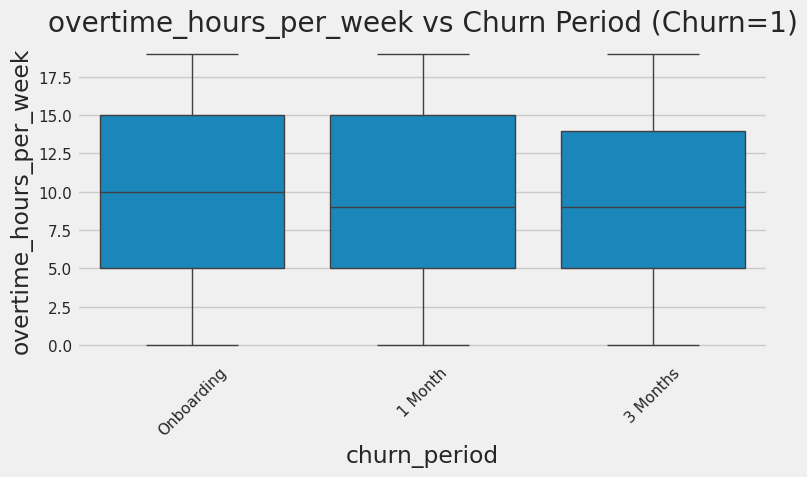

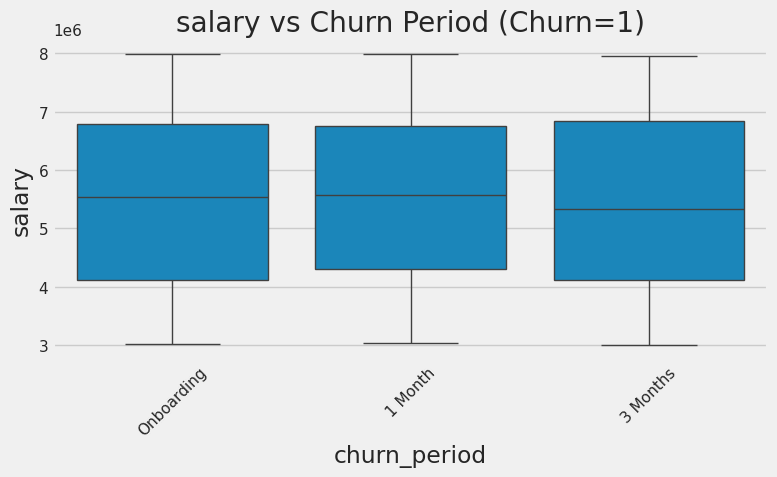

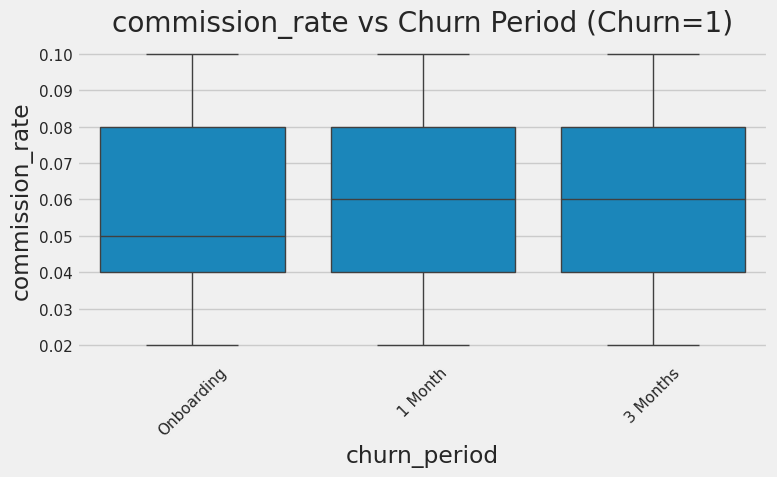

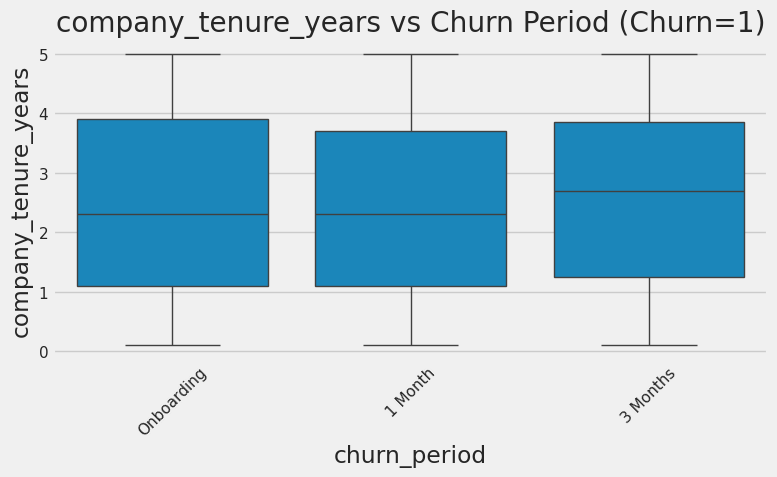

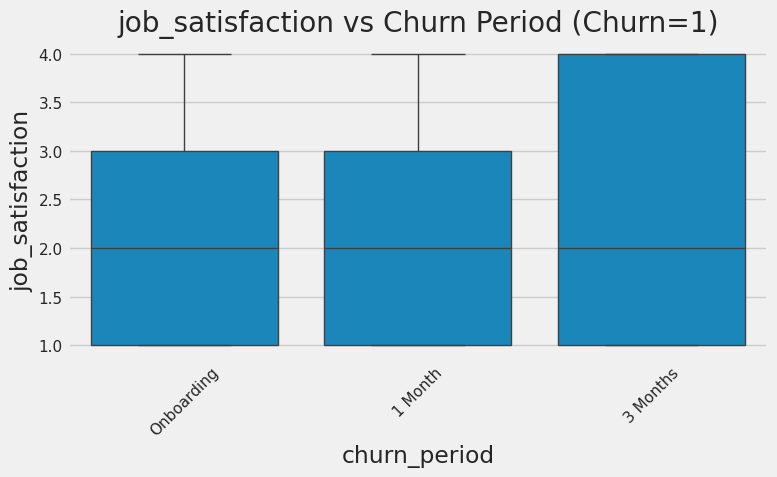

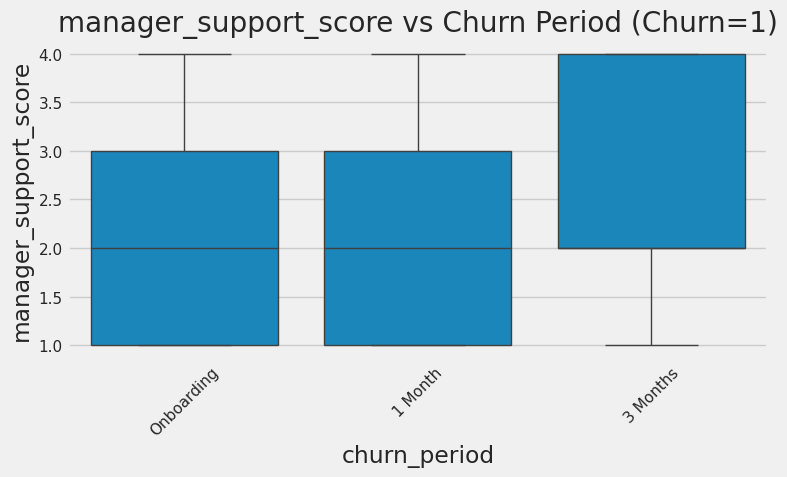

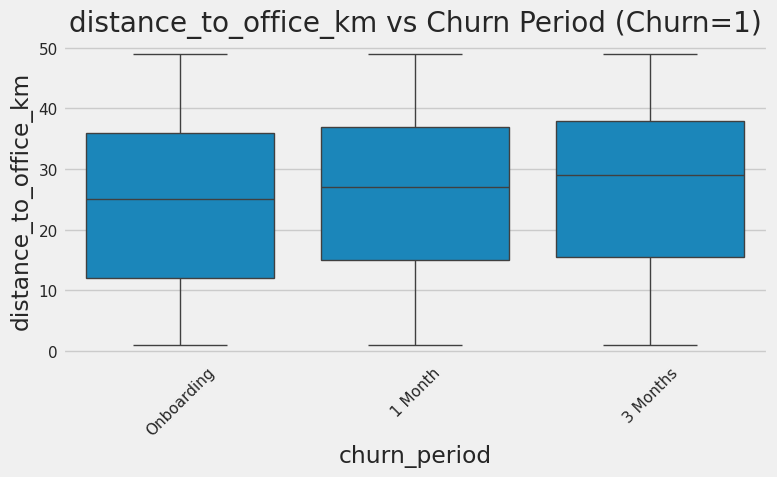

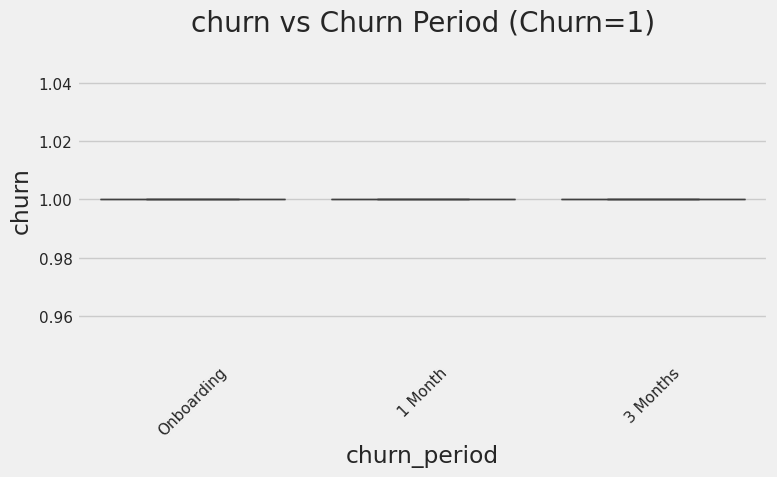

In [ ]:
# === Analisis semua fitur numerik vs churn_period (khusus churn=1) ===
for col in nums:
    plt.figure(figsize=(8, 5))
    sns.boxplot(data=df_churned, x='churn_period', y=col)
    plt.title(f"{col} vs Churn Period (Churn=1)")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()


1. Age vs Churn Period
* Median usia untuk semua kategori churn period relatif mirip (sekitar 33–34 tahun).

* Tidak terlihat perbedaan mencolok antara karyawan yang churn di fase Onboarding, 1 Month, atau 3 Months.

* Hal ini mengindikasikan bahwa faktor usia tidak menjadi pendorong utama kapan seorang karyawan memutuskan untuk keluar di periode awal.
<br>

2. Experience Years vs Churn Period
* Median pengalaman kerja juga konsisten di semua kategori churn period (sekitar 5 tahun).

* Sebagian besar karyawan yang churn, baik di onboarding maupun bulan ke-1 dan ke-3, memiliki latar belakang pengalaman yang cukup beragam (0–9 tahun).

* Artinya, tingkat pengalaman kerja sebelumnya tidak secara signifikan mempengaruhi kecepatan mereka keluar di periode awal.
<br>

3. Monthly Target vs Churn Period
* Median target bulanan hampir sama di semua kategori churn (sekitar 125–130 unit/poin).

* Penyebaran target terlihat lebar, tetapi tidak ada indikasi bahwa target bulanan yang lebih tinggi berkorelasi langsung dengan churn lebih cepat.

* Ini mengisyaratkan bahwa target kerja mungkin bukan faktor utama penentu kapan seseorang resign di periode awal, atau ada faktor lain yang lebih dominan (misalnya job satisfaction, work environment).
<br>

4. Target Achievement vs Churn Period
* Median pencapaian target serupa di semua kategori churn (sekitar 0,7 atau 70%).

* Karyawan yang churn pada 3 Months cenderung memiliki median target achievement sedikit lebih rendah dibanding Onboarding dan 1 Month.

* Hal ini mengindikasikan bahwa meskipun pencapaian target berperan, perbedaannya tidak terlalu signifikan dalam memengaruhi cepat atau lambatnya karyawan resign di awal masa kerja.
<br>

5. Working Hours per Week vs Churn Period
* Median jam kerja mingguan di semua kategori churn berada di kisaran ±55–57 jam.

* Tidak ada perbedaan berarti antara mereka yang keluar di Onboarding, 1 Month, maupun 3 Months.

* Ini mengindikasikan bahwa jumlah jam kerja normal mingguan tidak terlalu menentukan kapan mereka keluar, atau ada faktor lain seperti beban mental/lingkungan kerja yang lebih berpengaruh.
<br>

6. Overtime Hours per Week vs Churn Period
* Median jam lembur di semua kategori churn berada di kisaran ±8–9 jam per minggu.

* Pola overtime relatif konsisten, tetapi ada sedikit indikasi bahwa mereka yang churn di 3 Months cenderung memiliki median lembur sedikit lebih rendah.

* Artinya, lembur bukan faktor pembeda kuat antara periode churn yang berbeda, namun bisa saja terkait dengan beban kerja atau job satisfaction secara keseluruhan.
<br>

7. Salary vs Churn Period
* Median gaji relatif sama di semua periode churn (sekitar 5,3–5,5 juta).

* Tidak ada perbedaan signifikan antara mereka yang keluar di Onboarding, 1 Month, maupun 3 Months.

* Ini mengindikasikan gaji awal bukan faktor pembeda utama kapan karyawan memutuskan resign di awal masa kerja.
<br>

8. Commission Rate vs Churn Period
* Median commission rate stabil di kisaran ±0,06 (6%) pada semua kategori churn.

* Rentang distribusi relatif sama, menunjukkan komisi tidak mempengaruhi secara langsung waktu terjadinya churn.
<br>

9. Company Tenure Years vs Churn Period
* Median masa kerja sebelumnya di semua kategori churn sekitar 2 tahun.

* Polanya konsisten, artinya pengalaman lama/baru di perusahaan tidak berhubungan langsung dengan apakah karyawan keluar saat onboarding, bulan pertama, atau bulan ketiga.
<br>

10. Job Satisfaction vs Churn Period
* Median kepuasan kerja relatif rendah di semua periode churn (sekitar skor 2 dari 4).

* Artinya, baik mereka yang resign saat onboarding, bulan pertama, maupun bulan ketiga cenderung sudah merasa kurang puas sejak awal.

* Faktor kepuasan kerja kemungkinan sudah menjadi masalah sejak awal masa kerja, bukan berkembang seiring waktu.
<br>

11. Manager Support Score vs Churn Period
* Median dukungan dari manajer juga konsisten rendah (sekitar skor 2 dari 4) di semua periode churn.

* Ini menunjukkan lemahnya support manajerial berpotensi menjadi faktor konstan yang mempengaruhi keputusan resign di tiga fase awal tersebut.
<br>

12. Distance to Office (km) vs Churn Period
* Median jarak rumah ke kantor berada di kisaran ±25–27 km untuk semua kategori churn.

* Jarak yang cukup jauh ini bisa berkontribusi pada churn, namun karena distribusinya seragam di semua periode, jarak tidak menjadi pembeda utama kapan resign terjadi.

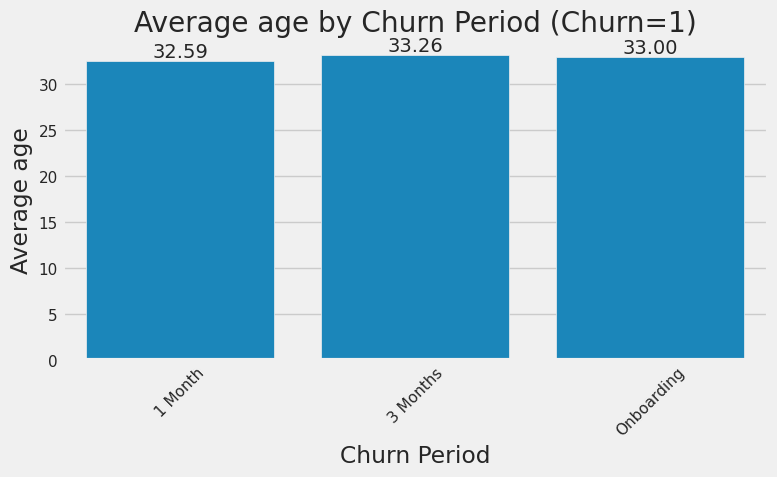

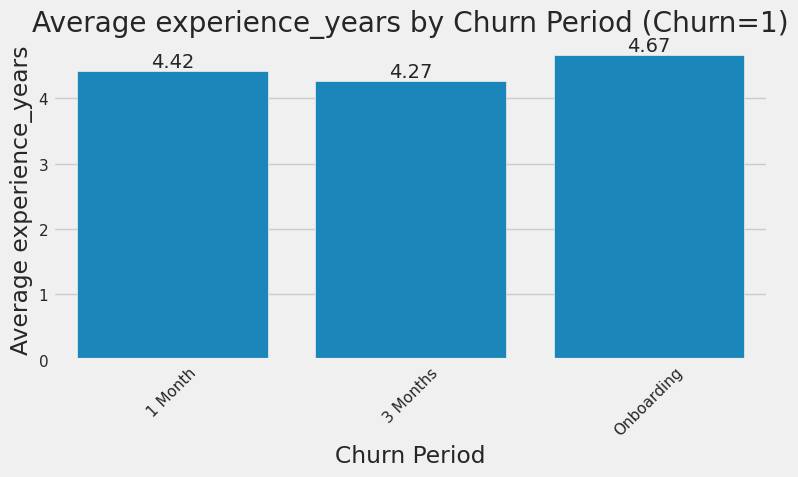

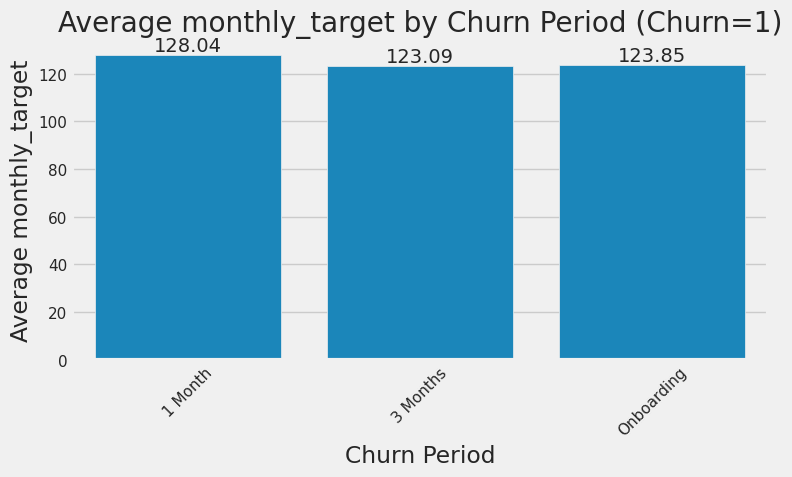

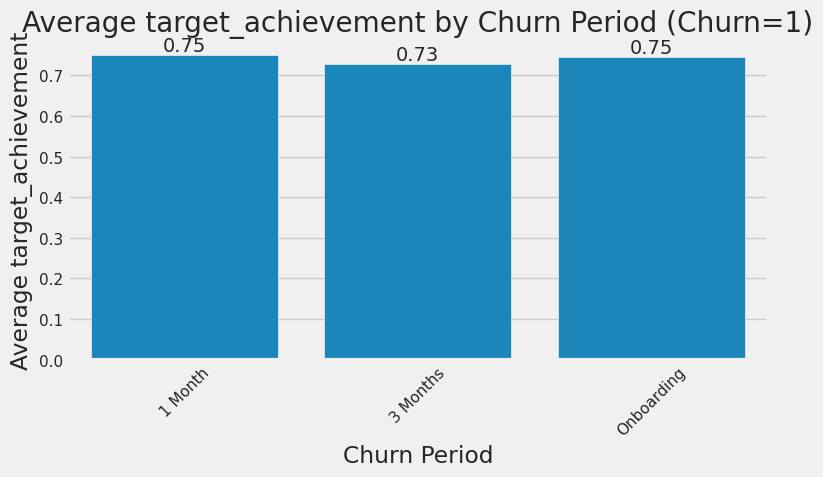

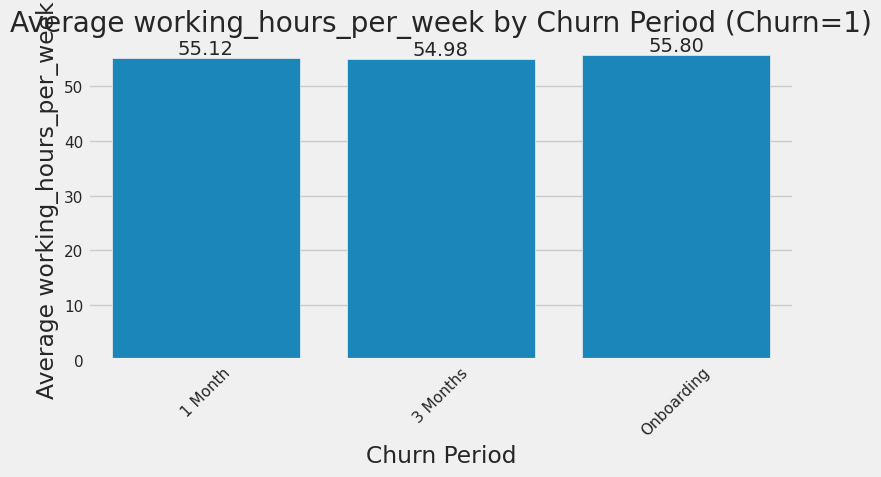

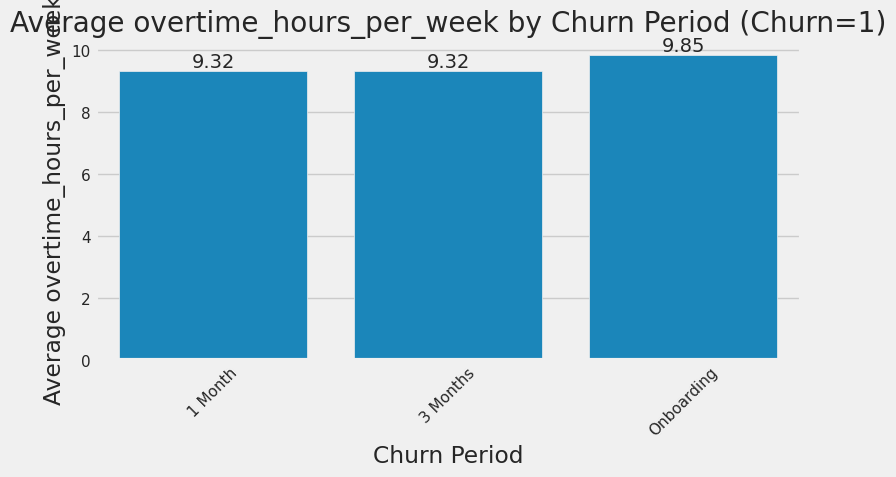

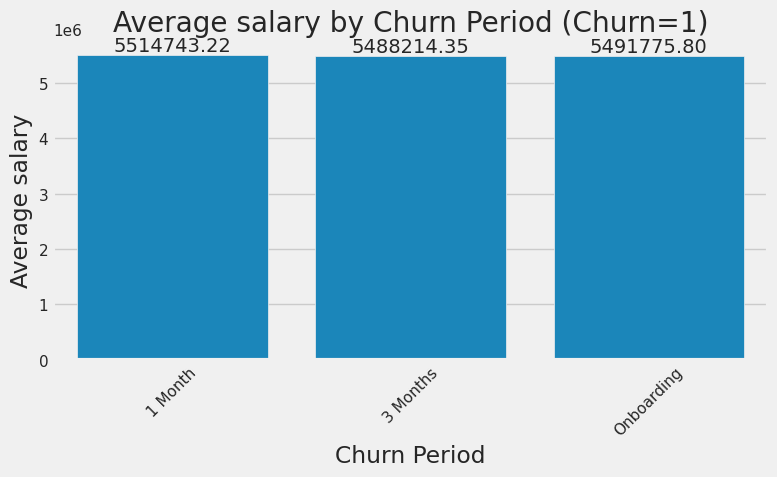

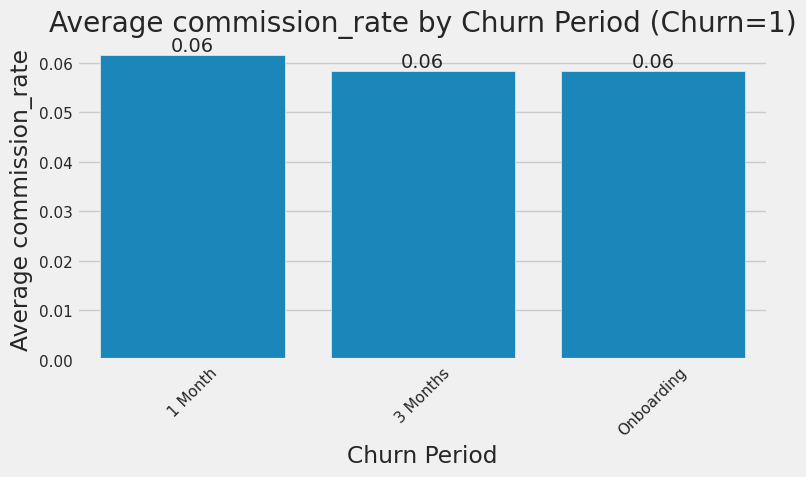

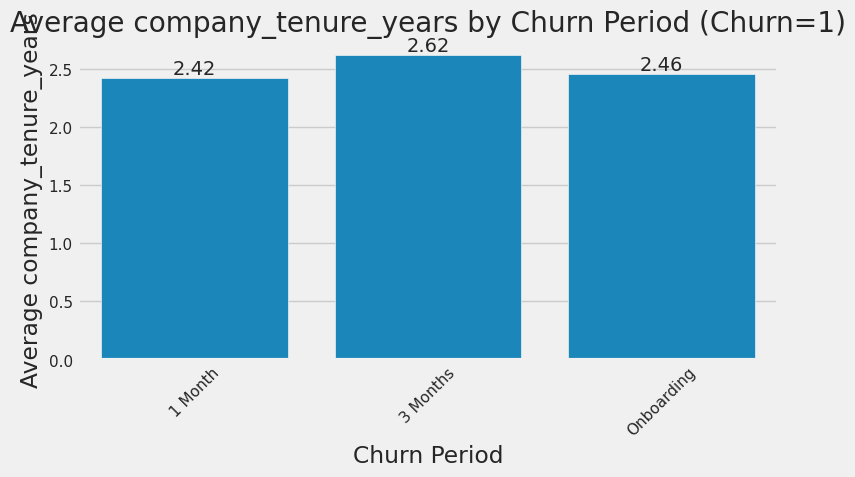

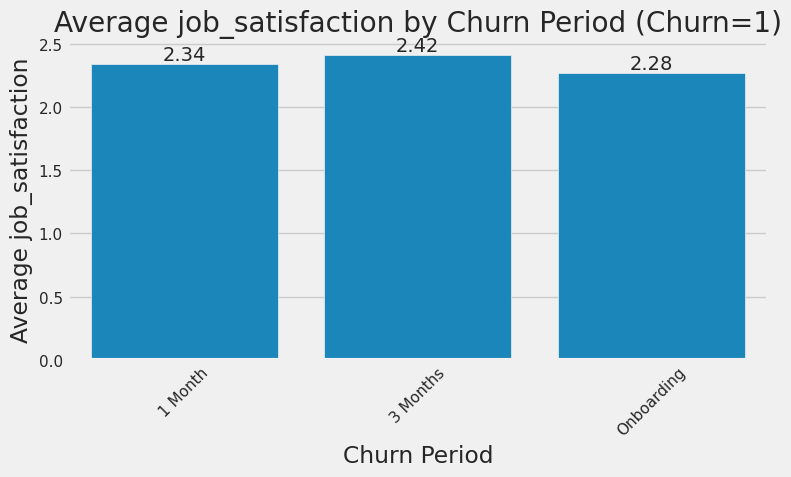

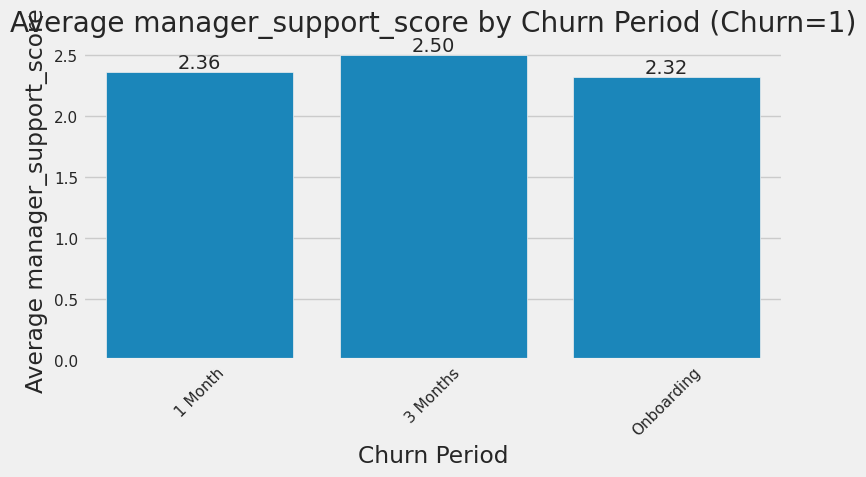

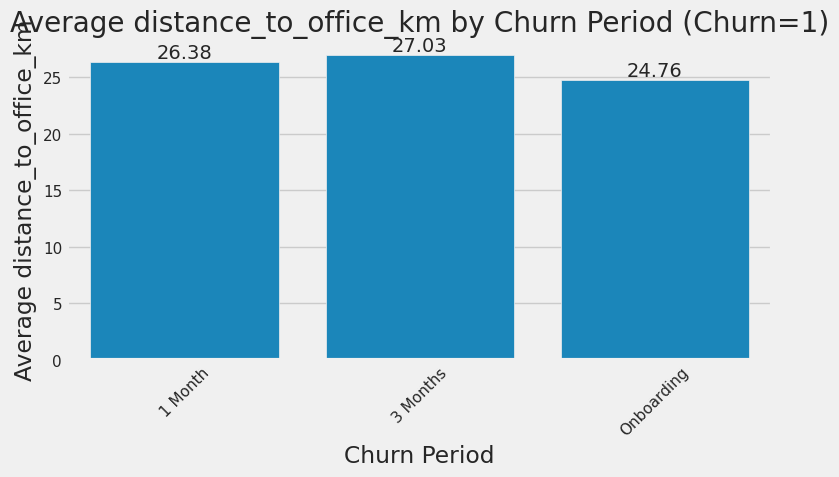

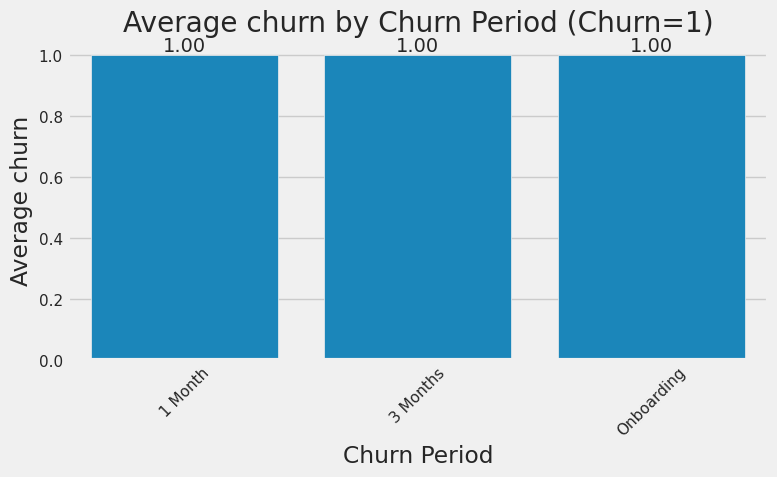

In [ ]:
# === Analisis semua fitur numerik vs churn_period (khusus churn=1) ===
for col in nums:
    plt.figure(figsize=(8, 5))

    # Hitung rata-rata per churn_period
    avg_values = df_churned.groupby('churn_period')[col].mean().reset_index()

    # Buat bar chart
    ax = sns.barplot(data=avg_values, x='churn_period', y=col)

    # Tambahin angka di atas bar
    for container in ax.containers:
        ax.bar_label(container, fmt="%.2f")

    plt.title(f"Average {col} by Churn Period (Churn=1)")
    plt.xlabel("Churn Period")
    plt.ylabel(f"Average {col}")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

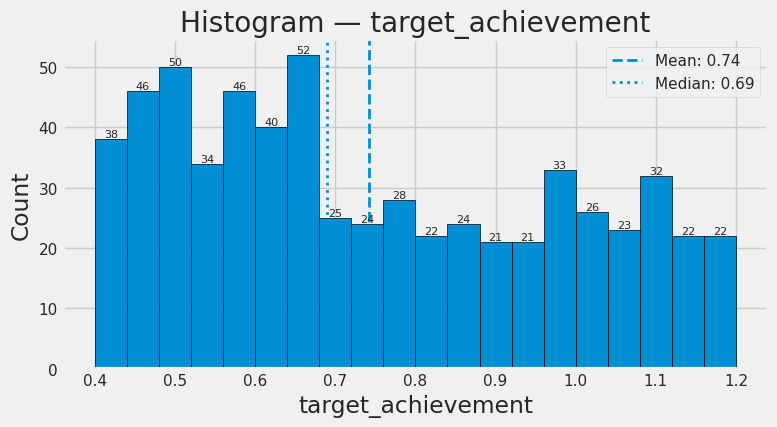

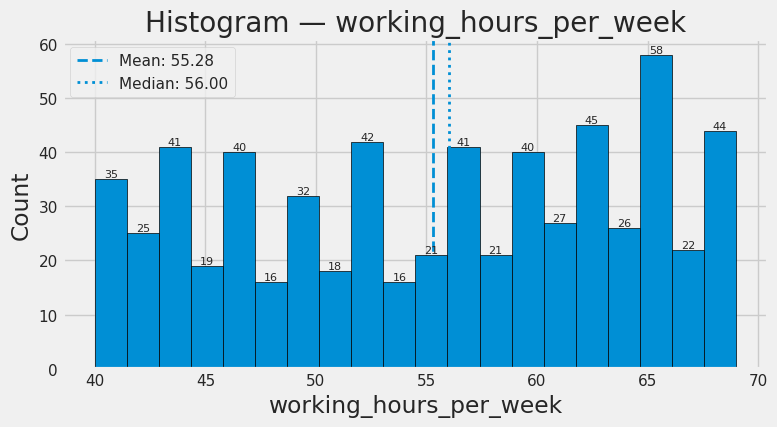

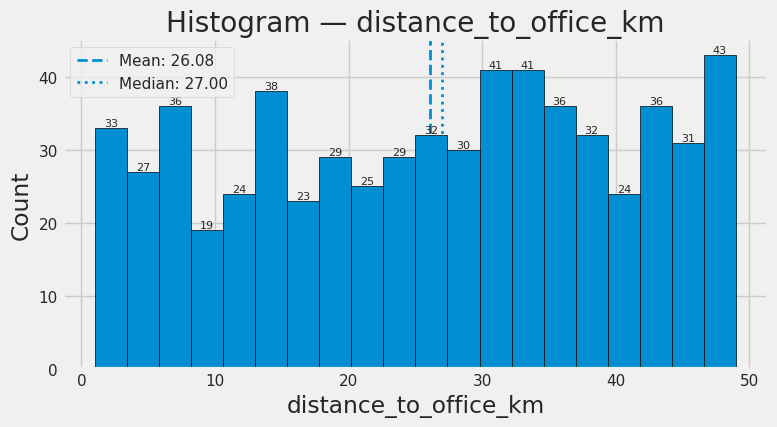

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Filter hanya churn = 1
df_churn1 = df[df["churn"] == 1]

def plot_hist(feature, bins=20):
    x = df_churn1[feature].dropna()
    mean_val = x.mean()
    median_val = x.median()

    fig, ax = plt.subplots(figsize=(8,4.5))
    counts, bins_edges, bars = ax.hist(x, bins=bins, edgecolor='black')

    # Garis mean & median
    ax.axvline(mean_val, linestyle='--', linewidth=2, label=f"Mean: {mean_val:.2f}")
    ax.axvline(median_val, linestyle=':', linewidth=2, label=f"Median: {median_val:.2f}")

    # Tambahkan label jumlah di atas batang
    for container in ax.containers:
        ax.bar_label(container, fmt='%d', label_type='edge', fontsize=8)

    ax.set_title(f"Histogram — {feature}")
    ax.set_xlabel(feature)
    ax.set_ylabel("Count")
    ax.legend()
    plt.tight_layout()
    plt.show()

# 1) Target Achievement (sebaran pencapaian target)
plot_hist("target_achievement", bins=20)

# 2) Working Hours per Week (rata-rata jam kerja)
plot_hist("working_hours_per_week", bins=20)

# 3) Distance to Office (jarak rata-rata)
plot_hist("distance_to_office_km", bins=20)


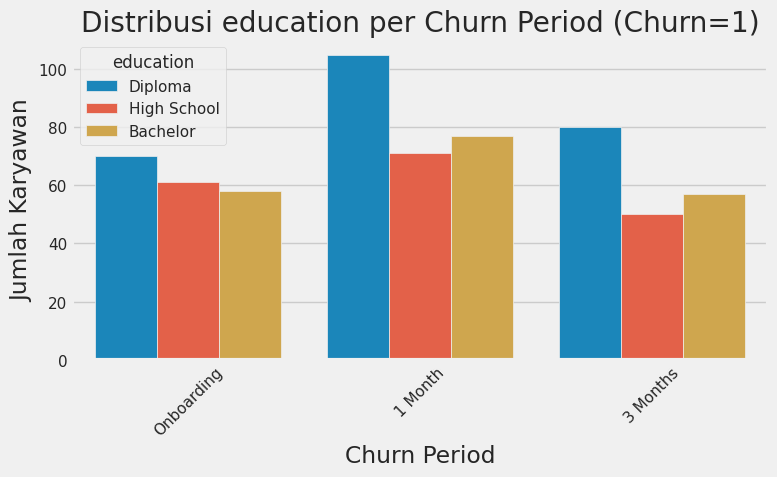

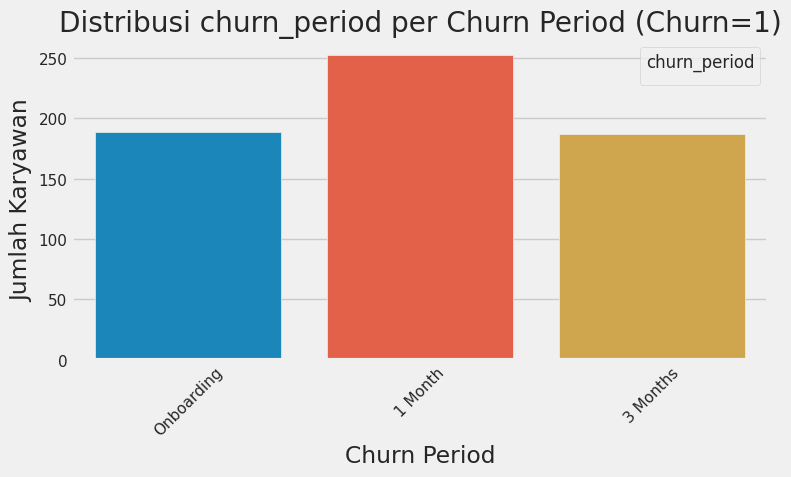

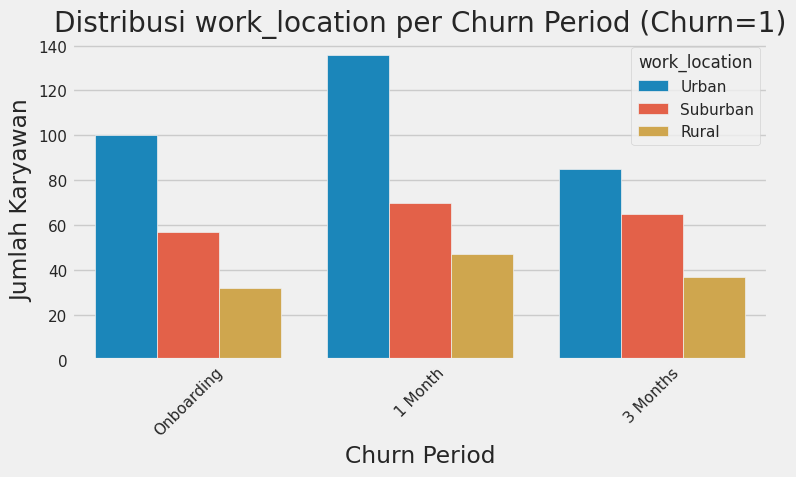

In [ ]:
# === Analisis semua fitur cat vs churn_period (khusus churn=1) ===
for col in cat_bertingkat:
    plt.figure(figsize=(8, 5))
    sns.countplot(data=df_churned, x='churn_period', hue=col)
    plt.title(f'Distribusi {col} per Churn Period (Churn=1)')
    plt.xlabel('Churn Period')
    plt.ylabel('Jumlah Karyawan')
    plt.xticks(rotation=45)
    plt.legend(title=col)
    plt.tight_layout()
    plt.show()

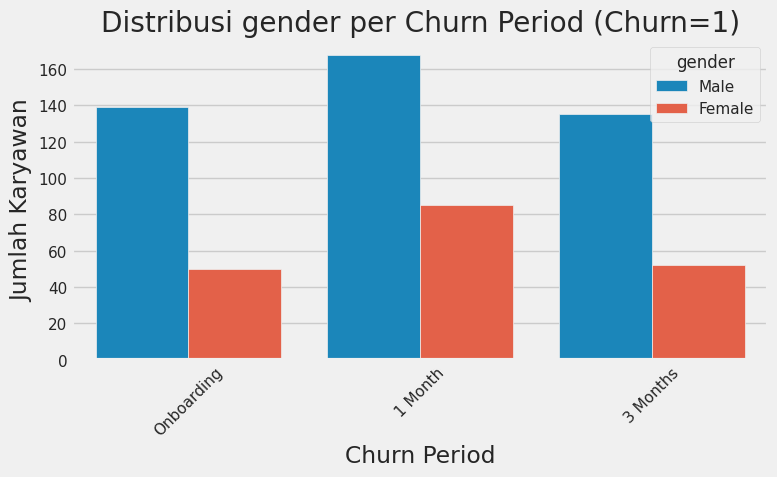

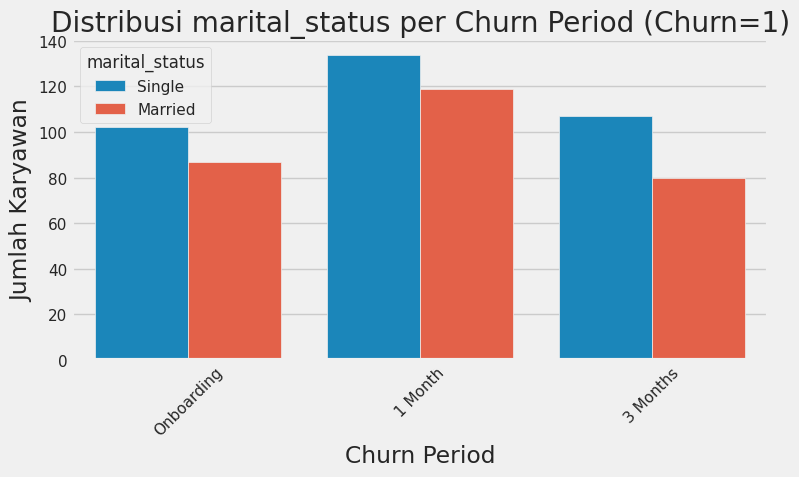

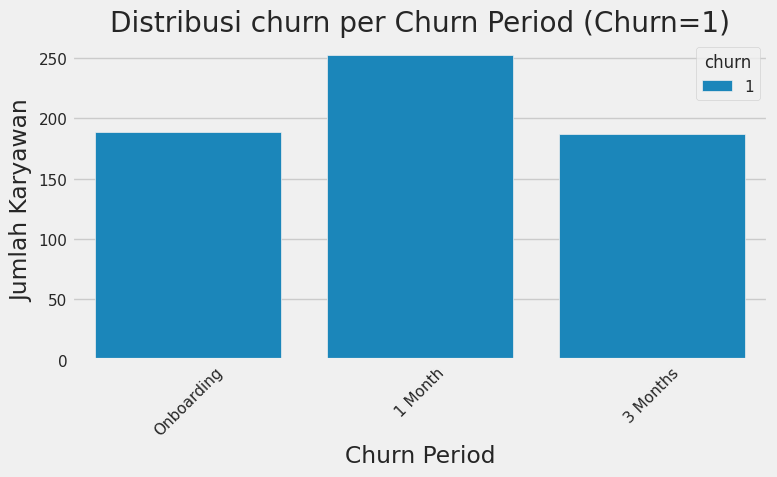

In [ ]:
# === Analisis semua fitur cat vs churn_period (khusus churn=1) ===
for col in cat_biasa:
    plt.figure(figsize=(8, 5))
    sns.countplot(data=df_churned, x='churn_period', hue=col)
    plt.title(f'Distribusi {col} per Churn Period (Churn=1)')
    plt.xlabel('Churn Period')
    plt.ylabel('Jumlah Karyawan')
    plt.xticks(rotation=45)
    plt.legend(title=col)
    plt.tight_layout()
    plt.show()


1. Education vs Churn Period (Churn=1)
* Karyawan dengan pendidikan Diploma mendominasi churn di semua periode, terutama pada periode 1 Month (lebih dari 100 orang).

* Pendidikan High School dan Bachelor churn-nya relatif seimbang, tapi cenderung lebih rendah dibanding Diploma.

* Indikasi: kemungkinan ekspektasi pekerjaan dan realita tidak sesuai pada kelompok pendidikan Diploma, terutama di awal masa kerja.
<br>

2. Work Location vs Churn Period (Churn=1)
* Karyawan yang bekerja di Urban memiliki jumlah churn paling tinggi di semua periode, terutama di 1 Month.

* Suburban dan Rural churn-nya lebih rendah, tapi Rural cenderung paling sedikit.

* Kemungkinan penyebab: persaingan kerja lebih ketat di daerah urban, peluang pindah kerja lebih banyak, atau faktor stres & biaya hidup.
<br>

3. Marital Status vs Churn Period

* Single memiliki jumlah churn yang lebih tinggi di semua periode dibanding Married.

* Puncak churn terjadi pada 1 Month, baik untuk Single maupun Married, tapi gap antara keduanya tetap terlihat (Single > Married).

* Kemungkinan: karyawan Single cenderung lebih mobile, lebih cepat mencari peluang baru, dan tidak terlalu terikat tanggung jawab keluarga, sehingga lebih berani resign di awal.


KESIMPULAN:

Prioritas intervensi, faktor paling ngaruh yang perlu jadi fokus perusahaan:

1. Onboarding & Adaptasi di 1 Bulan Pertama (karena churn tertinggi di sini).

2. Peningkatan Target Achievement & Kepuasan Kerja.

3. Manajerial & Dukungan Atasan.

4. Jam Kerja yang Seimbang + Perjalanan ke Kantor.

5. Retention Program untuk Karyawan Baru & Berpengalaman Rendah.

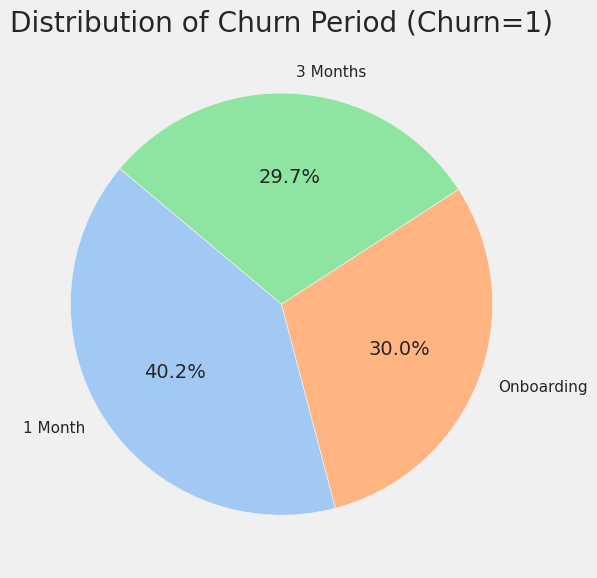

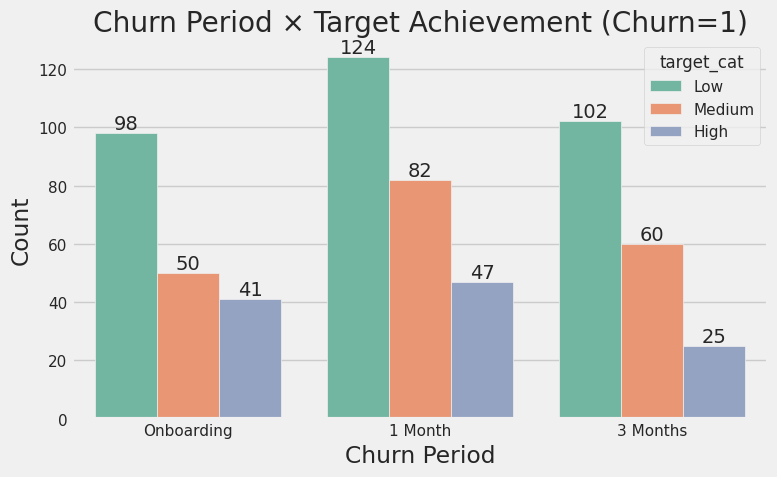

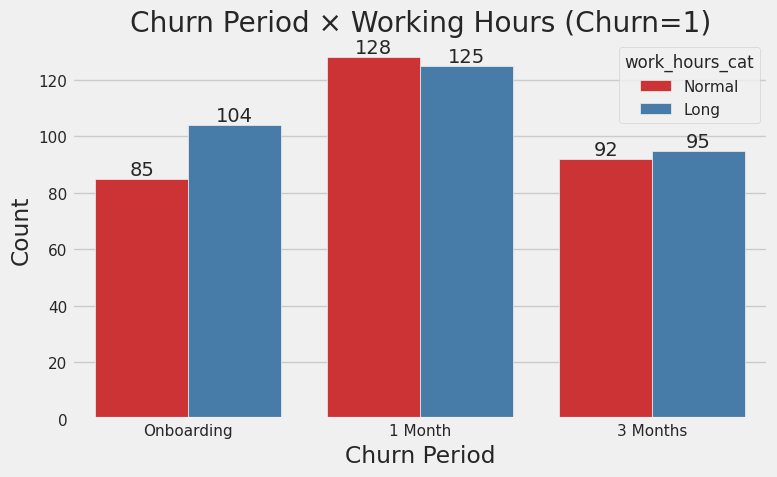

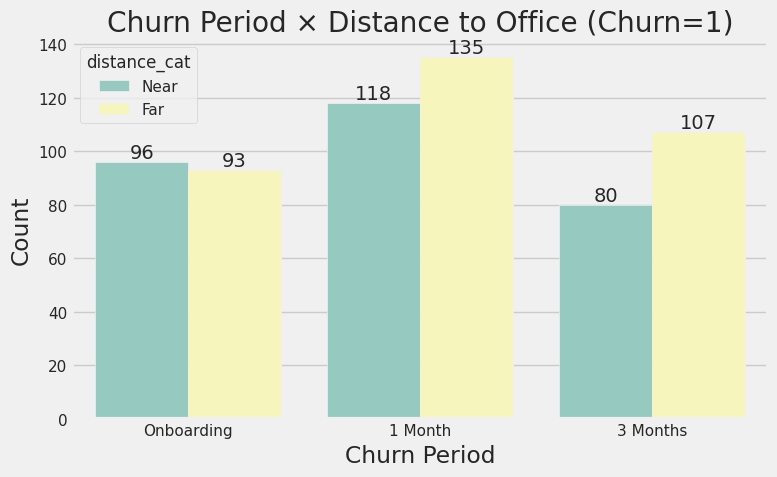

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# === 0) Setup Data ===
# Asumsi df sudah ada, dan df_churned hanya karyawan churn
df_churned = df[df['churn'] == 1]

# Kategorisasi Target Achievement
df_churned['target_cat'] = pd.cut(df_churned['target_achievement'],
                                  bins=[0, 0.7, 1.0, df_churned['target_achievement'].max()],
                                  labels=['Low', 'Medium', 'High'])

# Kategorisasi Working Hours
df_churned['work_hours_cat'] = pd.cut(df_churned['working_hours_per_week'],
                                      bins=[0, 55, df_churned['working_hours_per_week'].max()],
                                      labels=['Normal', 'Long'])

# Kategorisasi Distance to Office
df_churned['distance_cat'] = pd.cut(df_churned['distance_to_office_km'],
                                    bins=[0, 25, df_churned['distance_to_office_km'].max()],
                                    labels=['Near', 'Far'])

# === 1) Distribusi Churn Period (Overall) — Pie Chart ===
plt.figure(figsize=(6,6))
counts = df_churned['churn_period'].value_counts()
plt.pie(counts, labels=counts.index, autopct='%1.1f%%', startangle=140, colors=sns.color_palette("pastel"))
plt.title("Distribution of Churn Period (Churn=1)")
plt.tight_layout()
plt.show()

# === 2) Churn Period × Target Achievement — Grouped Bar Chart ===
plt.figure(figsize=(8,5))
ax = sns.countplot(data=df_churned, x='churn_period', hue='target_cat', palette='Set2')
for container in ax.containers:
    ax.bar_label(container)
plt.title("Churn Period × Target Achievement (Churn=1)")
plt.xlabel("Churn Period")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

# === 3) Churn Period × Working Hours — Grouped Bar Chart ===
plt.figure(figsize=(8,5))
ax = sns.countplot(data=df_churned, x='churn_period', hue='work_hours_cat', palette='Set1')
for container in ax.containers:
    ax.bar_label(container)
plt.title("Churn Period × Working Hours (Churn=1)")
plt.xlabel("Churn Period")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

# === 4) Churn Period × Distance to Office — Grouped Bar Chart ===
plt.figure(figsize=(8,5))
ax = sns.countplot(data=df_churned, x='churn_period', hue='distance_cat', palette='Set3')
for container in ax.containers:
    ax.bar_label(container)
plt.title("Churn Period × Distance to Office (Churn=1)")
plt.xlabel("Churn Period")
plt.ylabel("Count")
plt.tight_layout()
plt.show()


# Data Preparation

## Handling Missing Value

In [ ]:
df.isna().sum()

,0
employee_id,0
age,0
gender,0
education,0
experience_years,0
monthly_target,0
target_achievement,0
working_hours_per_week,0
overtime_hours_per_week,0
salary,0


## Handling Duplicate Value

In [ ]:
# Duplicate Value
df.duplicated().sum()

np.int64(0)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 19 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   employee_id              1000 non-null   int64  
 1   age                      1000 non-null   int64  
 2   gender                   1000 non-null   object 
 3   education                1000 non-null   object 
 4   experience_years         1000 non-null   int64  
 5   monthly_target           1000 non-null   int64  
 6   target_achievement       1000 non-null   float64
 7   working_hours_per_week   1000 non-null   int64  
 8   overtime_hours_per_week  1000 non-null   int64  
 9   salary                   1000 non-null   int64  
 10  commission_rate          1000 non-null   float64
 11  job_satisfaction         1000 non-null   int64  
 12  work_location            1000 non-null   object 
 13  manager_support_score    1000 non-null   int64  
 14  company_tenure_years     

## Handling Outliers (z-socre)

In [ ]:
# Outliers
from scipy import stats
# Filter Outliers menggunakan z-score

print(f'Jumlah baris sebelum memfilter outlier: {len(df)}')

filtered_entries = np.array([True] * len(df))

for col in ['employee_id', 'age', 'experience_years','monthly_target', 'target_achievement',
        'working_hours_per_week', 'overtime_hours_per_week', 'salary', 'commission_rate',
        'job_satisfaction', 'manager_support_score','company_tenure_years',
        'distance_to_office_km']:
    zscore = abs(stats.zscore(df[col])) # hitung absolute z-scorenya
    filtered_entries = (zscore < 3) & filtered_entries # keep yang kurang dari 3 absolute z-scorenya

df2 = df[filtered_entries] # filter, cuma ambil yang z-scorenya dibawah 3

print(f'Jumlah baris setelah memfilter outlier: {len(df2)}')

Jumlah baris sebelum memfilter outlier: 1000
Jumlah baris setelah memfilter outlier: 1000


In [ ]:
# Dataset df dan df2 tidak memiliki perbedaan

# Feature Enginering

## Feature Extraction

1. overtime_ratio : proporsi jam lembur terhadap total jam kerja
- overtime_hours_per_week / working_hours_per_week


2. tenure_per_age: perbandingan lama kerja dengan umur
- company_tenure_years / age


3. performance_gap : menilai karyawan yang tidak memenuhi target (berkinerja rendah)
- 1 - target_achievement


4. salary_per_hour : Perbandingan gaji dengan jumlah jam kerja dalam satu minggu
- salary / working_hours_per_week


5. satisfaction_support_mean : Rata-rata Job Satisfaction ditambah dengan Manager Support
- (job_satisfaction + manager_support_score) / 2


6. commuting_work_ratio : Rasio jarak dari rumah ke kantor dengan jam kerja per minggu
- distance_to_office_km / working_hours_per_week


7. salary_commission_rate : Total pendapatan bulanan yang dimungkinkan dibawa pulang oleh pekerja.
- salary * target_achievement * commission_rate

In [ ]:
# Safe division helper
def safe_div(numer, denom):
    return np.where((denom == 0) | pd.isna(denom), np.nan, numer / denom)

# Feature Engineering
df['overtime_ratio'] = safe_div(df['overtime_hours_per_week'], df['working_hours_per_week'])
df['tenure_per_age'] = safe_div(df['company_tenure_years'], df['age'])
df['performance_gap'] = 1 - df['target_achievement']
df['salary_per_hour'] = safe_div(df['salary'], df['working_hours_per_week'])
df['satisfaction_support_mean'] = (df['job_satisfaction'] + df['manager_support_score']) / 2
df['commuting_work_ratio'] = safe_div(df['distance_to_office_km'], df['working_hours_per_week'])
df['salary_commission_rate'] = df['salary'] * df['target_achievement'] * df['commission_rate']

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 26 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   employee_id                1000 non-null   int64  
 1   age                        1000 non-null   int64  
 2   gender                     1000 non-null   object 
 3   education                  1000 non-null   object 
 4   experience_years           1000 non-null   int64  
 5   monthly_target             1000 non-null   int64  
 6   target_achievement         1000 non-null   float64
 7   working_hours_per_week     1000 non-null   int64  
 8   overtime_hours_per_week    1000 non-null   int64  
 9   salary                     1000 non-null   int64  
 10  commission_rate            1000 non-null   float64
 11  job_satisfaction           1000 non-null   int64  
 12  work_location              1000 non-null   object 
 13  manager_support_score      1000 non-null   int64 

## Split Data

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.feature_selection import chi2

In [ ]:
# Drop ID and leakage feature
df = df.drop(columns=['employee_id', 'churn_period'])

# Separate target
X = df.drop(columns=['churn'])
y = df['churn']

# Train-test split (example: 80/20)
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [ ]:
## Untuk Fairness Analysis di bagian Model Evaluation

# --- Setelah split train-test ---
X_train_raw = X_train.copy()
X_test_raw = X_test.copy()


In [ ]:
X_test_raw.shape

(200, 23)

## Feature Encoding

In [ ]:
from sklearn.preprocessing import OneHotEncoder, LabelEncoder
import pandas as pd

# Columns to encode
cat_onehot = ['gender', 'marital_status']
cat_label = ['education', 'work_location']

# --- 1. One-Hot Encoding ---
ohe = OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore')
ohe_train = ohe.fit_transform(X_train[cat_onehot])
ohe_test = ohe.transform(X_test[cat_onehot])

# Create dataframe for one-hot encoded columns
ohe_train_df = pd.DataFrame(ohe_train, columns=ohe.get_feature_names_out(cat_onehot), index=X_train.index)
ohe_test_df = pd.DataFrame(ohe_test, columns=ohe.get_feature_names_out(cat_onehot), index=X_test.index)

# --- 2. Label Encoding ---
le_train_df = X_train[cat_label].copy()
le_test_df = X_test[cat_label].copy()

for col in cat_label:
    le = LabelEncoder()
    le_train_df[col] = le.fit_transform(X_train[col])
    le_test_df[col] = le.transform(X_test[col])

# --- 3. Combine Encoded Features with Numerical Columns ---
# Numerical columns = all except the categorical ones
num_cols = X_train.drop(columns=cat_onehot + cat_label).columns

X_train_enc = pd.concat([X_train[num_cols], le_train_df, ohe_train_df], axis=1)
X_test_enc = pd.concat([X_test[num_cols], le_test_df, ohe_test_df], axis=1)


In [ ]:
# --- 3. Combine back to overwrite X_train / X_test ---
num_cols = X_train.drop(columns=cat_onehot + cat_label).columns
X_train = pd.concat([X_train[num_cols], le_train_df, ohe_train_df], axis=1)
X_test = pd.concat([X_test[num_cols], le_test_df, ohe_test_df], axis=1)

# --- 4. Check results ---
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("\nSample X_train:\n", X_train.head())

X_train shape: (800, 23)
X_test shape: (200, 23)

Sample X_train:
      age  experience_years  monthly_target  target_achievement  \
12    25                 6             174                0.84   
272   29                 8             138                1.09   
564   33                 3             126                0.94   
462   26                 4             198                1.17   
123   24                 6             108                0.75   

     working_hours_per_week  overtime_hours_per_week   salary  \
12                       64                        2  5350716   
272                      60                        4  3386354   
564                      46                       13  6169870   
462                      66                        0  5036721   
123                      59                       17  5374151   

     commission_rate  job_satisfaction  manager_support_score  ...  \
12              0.10                 3                      1  ...   
272  

In [ ]:
# Check for null values in X_train and X_test
null_train = X_train.isnull().sum()
null_test = X_test.isnull().sum()

print("Null values in X_train:")
print(null_train[null_train > 0])

print("\nNull values in X_test:")
print(null_test[null_test > 0])

Null values in X_train:
Series([], dtype: int64)

Null values in X_test:
Series([], dtype: int64)


In [ ]:
X_test_raw.head()

,age,gender,education,experience_years,monthly_target,target_achievement,working_hours_per_week,overtime_hours_per_week,salary,commission_rate,...,company_tenure_years,marital_status,distance_to_office_km,overtime_ratio,tenure_per_age,performance_gap,salary_per_hour,satisfaction_support_mean,commuting_work_ratio,salary_commission_rate
570,37,Male,High School,0,117,0.69,67,15,7798064,0.10,...,2.1,Single,19,0.223881,0.056757,0.31,116389.014925,1.5,0.283582,538066.4160
790,25,Female,Bachelor,1,56,1.16,64,0,4393196,0.08,...,2.2,Single,35,0.000000,0.088000,-0.16,68643.687500,3.0,0.546875,407688.5888
909,34,Female,Diploma,8,78,0.66,56,1,5708089,0.06,...,2.1,Single,19,0.017857,0.061765,0.34,101930.160714,2.0,0.339286,226040.3244
366,24,Male,Diploma,1,107,1.19,59,13,7856113,0.04,...,5.0,Married,20,0.220339,0.208333,-0.19,133154.457627,2.0,0.338983,373950.9788
273,25,Male,Bachelor,0,110,0.51,54,17,5940149,0.05,...,3.6,Single,37,0.314815,0.144000,0.49,110002.759259,3.5,0.685185,151473.7995


## Standarisasi

In [ ]:
from sklearn.preprocessing import StandardScaler

# --- 1. Identify numerical columns ---
num_cols = X_train.select_dtypes(include=['int64', 'float64']).columns

# --- 2. Initialize scaler ---
scaler = StandardScaler()

# --- 3. Fit on training data, transform both ---
X_train[num_cols] = scaler.fit_transform(X_train[num_cols])
X_test[num_cols] = scaler.transform(X_test[num_cols])

# --- 4. Check result ---
print("X_train after scaling:\n", X_train.head())
print("\nMean (train):\n", X_train[num_cols].mean())
print("\nStd Dev (train):\n", X_train[num_cols].std())

X_train after scaling:
           age  experience_years  monthly_target  target_achievement  \
12  -1.163628          0.496584        1.051401            0.219958   
272 -0.582994          1.186284        0.226436            1.301897   
564 -0.002359         -0.537966       -0.048553            0.652734   
462 -1.018470         -0.193116        1.601378            1.648117   
123 -1.308787          0.496584       -0.461035           -0.169540   

     working_hours_per_week  overtime_hours_per_week    salary  \
12                 1.146229                -1.306973 -0.095667   
272                0.688595                -0.955341 -1.471496   
564               -0.913122                 0.627004  0.478064   
462                1.375046                -1.658606 -0.315588   
123                0.574187                 1.330269 -0.079254   

     commission_rate  job_satisfaction  manager_support_score  ...  \
12          1.790099          0.418859              -1.358819  ...   
272        -

## Handling Class Imbalance

Before SMOTE:
churn
1    503
0    297
Name: count, dtype: int64

After SMOTE:
churn
0    503
1    503
Name: count, dtype: int64


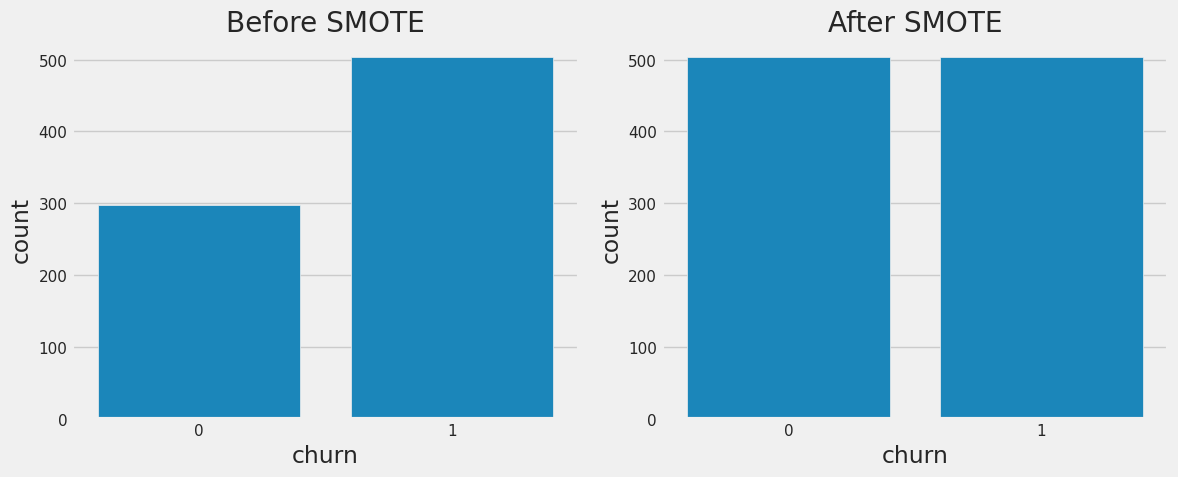

In [ ]:
from imblearn.over_sampling import SMOTE

# Misal X_train_processed & y_train hasil preprocessing
smote = SMOTE(random_state=42)

# handling class imbalance menggunakan SMOTE
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

# melihat distribusi kelas sebelum dan sesudah
print("Before SMOTE:")
print(y_train.value_counts())

print("\nAfter SMOTE:")
print(pd.Series(y_train_smote).value_counts())

fig, axs = plt.subplots(1, 2, figsize=(12, 5))
sns.countplot(x=y_train, ax=axs[0])
axs[0].set_title("Before SMOTE")
sns.countplot(x=y_train_smote, ax=axs[1])
axs[1].set_title("After SMOTE")
plt.tight_layout()
plt.show()

In [ ]:
# run in terminal / notebook cell if packages missing
!pip install xgboost catboost imbalanced-learn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 99.2/99.2 MB 5.3 MB/s eta 0:00:00


In [ ]:
X_test.head()

,age,experience_years,monthly_target,target_achievement,working_hours_per_week,overtime_hours_per_week,salary,commission_rate,job_satisfaction,manager_support_score,...,tenure_per_age,performance_gap,salary_per_hour,satisfaction_support_mean,commuting_work_ratio,salary_commission_rate,education,work_location,gender_Male,marital_status_Single
570,0.578276,-1.572517,-0.254794,-0.429205,1.489454,0.978637,1.618442,1.790099,-1.363519,-0.463387,...,-0.518740,0.429205,0.385815,-1.300756,-0.615464,1.948525,1.316670,0.893020,0.648814,0.803798
790,-1.163628,-1.227666,-1.652652,1.604840,1.146229,-1.658606,-0.766309,0.920063,0.418859,0.432046,...,0.113784,-1.604840,-1.120974,0.605113,0.329183,1.053894,-1.271379,0.893020,-1.541275,0.803798
909,0.142800,1.186284,-1.148506,-0.559038,0.230962,-1.482789,0.154635,0.050027,-0.472330,-0.463387,...,-0.417353,0.559038,-0.070490,-0.665466,-0.415609,-0.192548,0.022645,0.893020,-1.541275,0.803798
366,-1.308787,-1.227666,-0.483951,1.734672,0.574187,0.627004,1.659099,-0.820009,-1.363519,0.432046,...,2.549949,-1.734672,0.914914,-0.665466,-0.416695,0.822391,0.022645,0.893020,0.648814,-1.244094
273,-1.163628,-1.572517,-0.415204,-1.208201,0.002145,1.330269,0.317168,-0.384991,1.310048,0.432046,...,1.247512,1.208201,0.184272,1.240403,0.825415,-0.704211,-1.271379,-1.719104,0.648814,0.803798


## SAVE PREPROCESSING AND DATASET

In [ ]:
import pickle


# --- Overwrite ke nama asli (biar konsisten dengan code modelling/tuning) ---
X_train_clear = X_train_smote.copy()
y_train_clear = y_train_smote.copy()
X_test = X_test.copy()
y_test = y_test.copy()

# --- Save everything into pickle ---
with open("preprocessing_pipeline.pkl", "wb") as f:
    pickle.dump({
        "X_train_raw": X_train_raw,
        "X_test_raw": X_test_raw,
        "X_train_clear": X_train_clear,
        "y_train_clear": y_train_clear,
        "X_test": X_test,
        "y_test": y_test,
        "scaler": scaler,   # StandardScaler object
        "smote": smote      # SMOTE object
    }, f)

print("✅ Preprocessing pipeline and datasets saved successfully!")


✅ Preprocessing pipeline and datasets saved successfully!


## Load Preprocessing Step

In [ ]:
with open("preprocessing_pipeline.pkl", "rb") as f:
    data = pickle.load(f)

X_train_raw = data["X_train_raw"]
X_test_raw = data["X_test_raw"]
X_train_clear = data["X_train_clear"]
y_train_clear = data["y_train_clear"]
X_test = data["X_test"]
y_test = data["y_test"]
scaler = data["scaler"]
smote = data["smote"]


# Modelling

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, classification_report

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

In [ ]:
!pip install catboost
from catboost import CatBoostClassifier

## Build Model

In [ ]:
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.metrics import recall_score, fbeta_score, roc_auc_score, confusion_matrix
import pandas as pd
import numpy as np

# Dictionary to store models
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "KNN": KNeighborsClassifier(),
    "Random Forest": RandomForestClassifier(random_state=42),
    "XGBoost": XGBClassifier(eval_metric='logloss', random_state=42,n_jobs=1),
    "CatBoost": CatBoostClassifier(verbose=0, random_state=42)
}

# Store results
results = []

# Stratified K-Fold (preserve churn ratio)
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Loop through each model
for name, model in models.items():
    print(f"\n===== {name} =====")

    # Cross-validation scores
    recall_scores = []
    f2_scores = []
    auc_scores = []

    for train_idx, val_idx in skf.split(X_train_clear, y_train_clear):
        X_tr, X_val = X_train_clear.iloc[train_idx], X_train_clear.iloc[val_idx]
        y_tr, y_val = y_train_clear.iloc[train_idx], y_train_clear.iloc[val_idx]


        model.fit(X_tr, y_tr)
        y_val_pred = model.predict(X_val)
        y_val_prob = model.predict_proba(X_val)[:, 1]

        recall_scores.append(recall_score(y_val, y_val_pred))
        f2_scores.append(fbeta_score(y_val, y_val_pred, beta=2))
        auc_scores.append(roc_auc_score(y_val, y_val_prob))

    # Train final model on all training data
    model.fit(X_train_clear, y_train_clear)
    y_test_pred = model.predict(X_test)
    y_test_prob = model.predict_proba(X_test)[:, 1]

    # Confusion matrix on test set
    cm = confusion_matrix(y_test, y_test_pred)
    print("Confusion Matrix (Test Set):")
    print(cm)

    # Append CV average results
    results.append({
        "Model": name,
        "Recall (CV avg)": np.mean(recall_scores),
        "F2-score (CV avg)": np.mean(f2_scores),
        "AUC (CV avg)": np.mean(auc_scores)
    })

# Convert to DataFrame
results_df = pd.DataFrame(results).sort_values(by="F2-score (CV avg)", ascending=False)

print("\n=== Cross-Validation Results ===")
print(results_df)



===== Logistic Regression =====
Confusion Matrix (Test Set):
[[51 23]
 [36 90]]

===== Decision Tree =====
Confusion Matrix (Test Set):
[[44 30]
 [43 83]]

===== KNN =====
Confusion Matrix (Test Set):
[[55 19]
 [56 70]]

===== Random Forest =====
Confusion Matrix (Test Set):
[[46 28]
 [30 96]]

===== XGBoost =====
Confusion Matrix (Test Set):
[[39 35]
 [31 95]]

===== CatBoost =====
Confusion Matrix (Test Set):
[[45 29]
 [29 97]]

=== Cross-Validation Results ===
                 Model  Recall (CV avg)  F2-score (CV avg)  AUC (CV avg)
4              XGBoost         0.781109           0.781570      0.871405
5             CatBoost         0.773168           0.778505      0.888094
3        Random Forest         0.769267           0.772020      0.874925
0  Logistic Regression         0.721485           0.719659      0.796791
1        Decision Tree         0.687822           0.685821      0.681941
2                  KNN         0.562535           0.593174      0.770667


## Saving the Models into pickle (pkl)

In [ ]:
import pickle

# Save all trained models after training loop
with open("trained_models.pkl", "wb") as f:
    pickle.dump(models, f)

print("✅ All models saved to trained_models.pkl")


✅ All models saved to trained_models.pkl


## Load all Models

In [ ]:
import pickle
from sklearn.metrics import recall_score, fbeta_score, roc_auc_score, confusion_matrix
import pandas as pd

# Load all trained models
with open("trained_models.pkl", "rb") as f:
    loaded_models = pickle.load(f)
import pickle
from sklearn.metrics import recall_score, fbeta_score, roc_auc_score, confusion_matrix
import pandas as pd

# Load all trained models
with open("trained_models.pkl", "rb") as f:
    loaded_models = pickle.load(f)

print("✅ Models loaded successfully")

# Store evaluation results
loaded_results = []

# Evaluate each loaded model on test set
for name, model in loaded_models.items():
    print(f"\n===== {name} =====")

    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    recall = recall_score(y_test, y_pred)
    f2 = fbeta_score(y_test, y_pred, beta=2)
    auc = roc_auc_score(y_test, y_prob)
    cm = confusion_matrix(y_test, y_pred)

    print(f"Recall: {recall:.4f}")
    print(f"F2-score: {f2:.4f}")
    print(f"AUC: {auc:.4f}")
    print("Confusion Matrix:")
    print(cm)

    # Append results for summary
    loaded_results.append({
        "Model": name,
        "Recall (Test)": recall,
        "F2-score (Test)": f2,
        "AUC (Test)": auc
    })

# Convert to DataFrame for easy comparison
loaded_results_df = pd.DataFrame(loaded_results).sort_values(by="F2-score (Test)", ascending=False)

print("\n=== Test Set Evaluation Results ===")
print(loaded_results_df)

print("✅ Models loaded successfully")

# Store evaluation results
loaded_results = []

# Evaluate each loaded model on test set
for name, model in loaded_models.items():
    print(f"\n===== {name} =====")

    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    recall = recall_score(y_test, y_pred)
    f2 = fbeta_score(y_test, y_pred, beta=2)
    auc = roc_auc_score(y_test, y_prob)
    cm = confusion_matrix(y_test, y_pred)

    print(f"Recall: {recall:.4f}")
    print(f"F2-score: {f2:.4f}")
    print(f"AUC: {auc:.4f}")
    print("Confusion Matrix:")
    print(cm)

    # Append results for summary
    loaded_results.append({
        "Model": name,
        "Recall (Test)": recall,
        "F2-score (Test)": f2,
        "AUC (Test)": auc
    })

# Convert to DataFrame for easy comparison
loaded_results_df = pd.DataFrame(loaded_results).sort_values(by="F2-score (Test)", ascending=False)

print("\n=== Test Set Evaluation Results ===")
print(loaded_results_df)


✅ Models loaded successfully

===== Logistic Regression =====
Recall: 0.7143
F2-score: 0.7293
AUC: 0.7599
Confusion Matrix:
[[51 23]
 [36 90]]

===== Decision Tree =====
Recall: 0.6587
F2-score: 0.6726
AUC: 0.6267
Confusion Matrix:
[[44 30]
 [43 83]]

===== KNN =====
Recall: 0.5556
F2-score: 0.5902
AUC: 0.7018
Confusion Matrix:
[[55 19]
 [56 70]]

===== Random Forest =====
Recall: 0.7619
F2-score: 0.7643
AUC: 0.7746
Confusion Matrix:
[[46 28]
 [30 96]]

===== XGBoost =====
Recall: 0.7540
F2-score: 0.7492
AUC: 0.7598
Confusion Matrix:
[[39 35]
 [31 95]]

===== CatBoost =====
Recall: 0.7698
F2-score: 0.7698
AUC: 0.7906
Confusion Matrix:
[[45 29]
 [29 97]]

=== Test Set Evaluation Results ===
                 Model  Recall (Test)  F2-score (Test)  AUC (Test)
5             CatBoost       0.769841         0.769841    0.790648
3        Random Forest       0.761905         0.764331    0.774614
4              XGBoost       0.753968         0.749211    0.759760
0  Logistic Regression       0.71

## Visualisasi Hasil Modelling

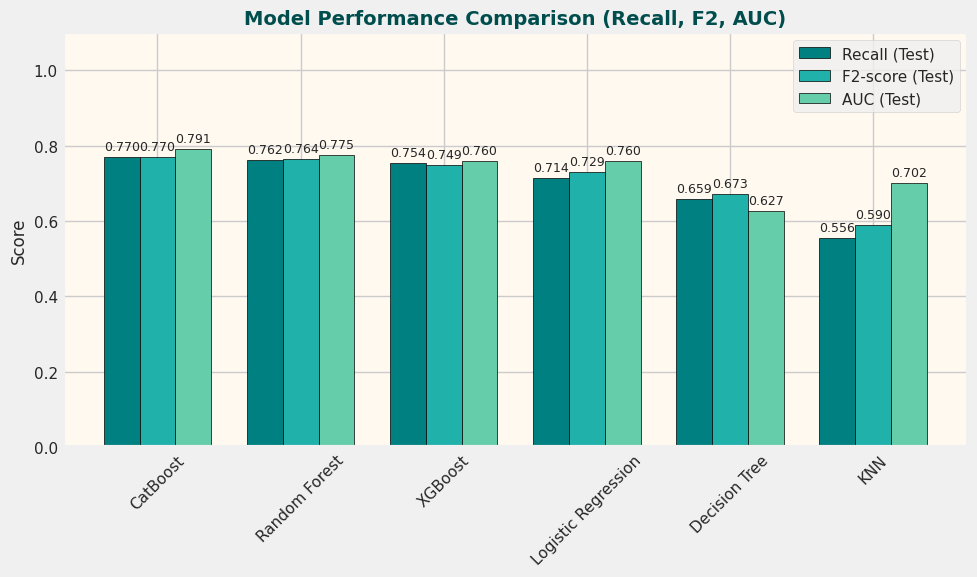

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Data
metrics = ["Recall (Test)", "F2-score (Test)", "AUC (Test)"]
models = loaded_results_df["Model"].values
n_models = len(models)
bar_width = 0.25  # lebar tiap bar
x = np.arange(n_models)

# Warna: teal blue untuk metrik utama, variasi lebih soft untuk yang lain
colors = ["#008080", "#20B2AA", "#66CDAA"]  # teal variations

plt.figure(figsize=(10, 6))

# Plot tiap metric
for i, metric in enumerate(metrics):
    plt.bar(x + i*bar_width,
            loaded_results_df[metric],
            width=bar_width,
            label=metric,
            color=colors[i],
            edgecolor="black")

# Tambah label nilai di atas bar
for i, metric in enumerate(metrics):
    for j, val in enumerate(loaded_results_df[metric]):
        plt.text(j + i*bar_width, val + 0.01, f"{val:.3f}",
                 ha="center", va="bottom", fontsize=9)

# Styling chart
plt.xticks(x + bar_width, models, rotation=45)
plt.ylabel("Score", fontsize=12)
plt.title("Model Performance Comparison (Recall, F2, AUC)", fontsize=14, weight="bold", color="#004d4d")
plt.gca().set_facecolor("#fff9f0")  # light cream background
plt.ylim(0, 1.1)
plt.legend()
plt.tight_layout()
plt.show()


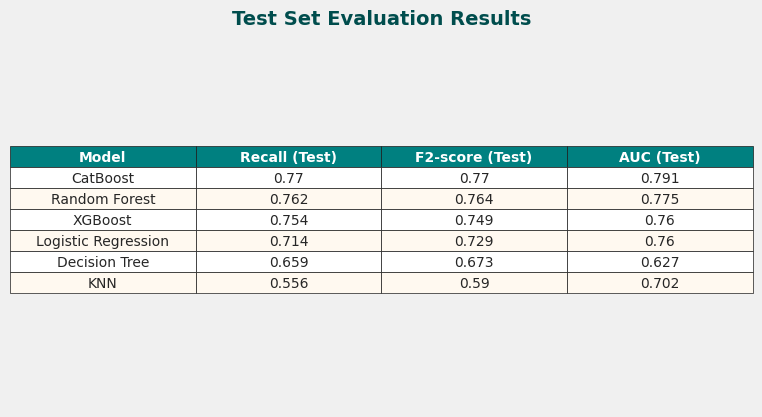

In [ ]:
import matplotlib.pyplot as plt

# Ambil dataframe hasil evaluasi
table_df = loaded_results_df.copy()

# Bikin figure
fig, ax = plt.subplots(figsize=(8, 2 + 0.4 * len(table_df)))

# Sembunyikan axis
ax.axis("off")
ax.axis("tight")

# Tambahkan tabel
table = ax.table(cellText=table_df.round(3).values,
                 colLabels=table_df.columns,
                 cellLoc='center',
                 loc='center')

# Styling tabel
table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1.2, 1.2)

# Warna header
for (row, col), cell in table.get_celld().items():
    if row == 0:  # header
        cell.set_facecolor("#008080")  # teal blue
        cell.set_text_props(color="white", weight="bold")
    else:
        if row % 2 == 0:  # striping row
            cell.set_facecolor("#fff9f0")  # light cream
        else:
            cell.set_facecolor("white")

plt.title("Test Set Evaluation Results", fontsize=14, weight="bold", color="#004d4d")
plt.tight_layout()
plt.show()


# Hyperparameter Tunning

In [ ]:
# === Import Libraries ===
import pandas as pd
import joblib
from sklearn.metrics import (
    make_scorer, fbeta_score, recall_score,
    roc_auc_score, confusion_matrix
)
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from catboost import CatBoostClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier

# === Step 1: Define Models & Param Grids ===
models_config = {
    "Logistic Regression": {
        "estimator": LogisticRegression(solver="liblinear", random_state=42),
        "param_grid": {
            "C": [0.01, 0.1, 1, 10],
            "penalty": ["l1", "l2"],
            "class_weight": [None, 'balanced']
        }
    },
    "Random Forest": {
        "estimator": RandomForestClassifier(random_state=42, n_jobs=-1, class_weight='balanced'),
        "param_grid": {
            "n_estimators": [100, 200, 300],
            "max_depth": [None, 5, 10, 20],
            "min_samples_split": [2, 5, 10],
            "min_samples_leaf": [1, 2, 4]
        }
    },
    "XGBoost": {
        "estimator": XGBClassifier(
            objective='binary:logistic',eval_metric="logloss", random_state=42, use_label_encoder=False, n_jobs=1
        ),
        "param_grid": {
            "n_estimators": [100, 200, 300],
            "max_depth": [3, 5, 7],
            "learning_rate": [0.01, 0.1, 0.2],
            "subsample": [0.8, 1.0],
            "colsample_bytree": [0.8, 1.0]
        }
    },
    "CatBoost": {
        "estimator": CatBoostClassifier(verbose=0, random_state=42),
        "param_grid": {
            "iterations": [200, 500],
            "depth": [4, 6, 8],
            "learning_rate": [0.01, 0.05, 0.1]
        }
    },
    "KNN": {
        "estimator": KNeighborsClassifier(),
        "param_grid": {
            "n_neighbors": [3, 5, 7, 9, 11],
            "weights": ["uniform", "distance"],
            "metric" : ['minkowski', 'euclidean', 'manhattan']
        }
    },
    "Decision Tree": {
        "estimator": DecisionTreeClassifier(random_state=42),
        "param_grid": {
            'criterion': ['gini', 'entropy', 'log_loss'],
            'max_depth': [None, 5, 10, 20, 30],
            'min_samples_split': [2, 5, 10],
            'min_samples_leaf': [1, 2, 4],
            'max_features': [None, 'sqrt', 'log2']
        }
    }
}

# === Step 2: Training + Hyperparameter Tuning ===
f2_scorer = make_scorer(fbeta_score, beta=2)
scoring = {"Recall": "recall", "F2": f2_scorer, "AUC": "roc_auc"}
cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

best_models = {}
train_results = []

for model_name, config in models_config.items():
    print(f"\n🔎 Training & tuning {model_name}...")

    grid = GridSearchCV(
        estimator=config["estimator"],
        param_grid=config["param_grid"],
        scoring=scoring,
        refit="F2",   # pilih model terbaik berdasarkan F2
        cv=cv_strategy,
        n_jobs=-1,
        verbose=1
    )

    grid.fit(X_train, y_train)

    # Simpan best model
    best_models[model_name] = grid.best_estimator_
    joblib.dump(grid.best_estimator_, f"{model_name.replace(' ', '_')}_best.joblib")

    # Simpan hasil CV rata-rata
    cv_results = grid.cv_results_
    best_index = grid.best_index_

    train_results.append({
        "Model": model_name,
        "Best Params": grid.best_params_,
        "Recall (CV avg)": cv_results["mean_test_Recall"][best_index],
        "F2-score (CV avg)": cv_results["mean_test_F2"][best_index],
        "AUC (CV avg)": cv_results["mean_test_AUC"][best_index]
    })

# Save training results
train_results_df = pd.DataFrame(train_results)
train_results_df.to_csv("train_cv_results.csv", index=False)
print("\n=== Cross-Validation Results (Best per Model) ===")
print(train_results_df)

# === Step 3: Best Model Selection ===
cv_results_sorted = train_results_df.sort_values(
    by=["F2-score (CV avg)", "Recall (CV avg)", "AUC (CV avg)"],
    ascending=False
).reset_index(drop=True)

best_model_name = cv_results_sorted.iloc[0]["Model"]
print(f"\n✅ Best Model after tuning: {best_model_name}")

best_model = best_models[best_model_name]
joblib.dump(best_model, "best_model.joblib")  # Save final best model

# === Step 4: Evaluate on Test Set ===
metrics_summary = []
confusion_summaries = []

for model_name, model in best_models.items():
    print(f"\n📊 Evaluating {model_name} on test set...")

    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1] if hasattr(model, "predict_proba") else None

    recall = recall_score(y_test, y_pred)
    f2 = fbeta_score(y_test, y_pred, beta=2)
    auc = roc_auc_score(y_test, y_proba) if y_proba is not None else None

    metrics_summary.append({
        "Model": model_name,
        "Recall (Test)": recall,
        "F2-score (Test)": f2,
        "AUC (Test)": auc
    })

    tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
    confusion_summaries.append({
        "Model": model_name,
        "TP": tp, "FP": fp,
        "TN": tn, "FN": fn
    })

# Save test results
metrics_df = pd.DataFrame(metrics_summary)
conf_matrix_summary = pd.DataFrame(confusion_summaries)

metrics_df.to_csv("test_metrics_summary.csv", index=False)
conf_matrix_summary.to_csv("confusion_matrix_summary.csv", index=False)

print("\n=== Test Set Metrics ===")
print(metrics_df)
print("\n=== Confusion Matrix Summary ===")
print(conf_matrix_summary)



🔎 Training & tuning Logistic Regression...
Fitting 5 folds for each of 16 candidates, totalling 80 fits

🔎 Training & tuning Random Forest...
Fitting 5 folds for each of 108 candidates, totalling 540 fits

🔎 Training & tuning XGBoost...
Fitting 5 folds for each of 108 candidates, totalling 540 fits

🔎 Training & tuning CatBoost...
Fitting 5 folds for each of 18 candidates, totalling 90 fits

🔎 Training & tuning KNN...
Fitting 5 folds for each of 30 candidates, totalling 150 fits

🔎 Training & tuning Decision Tree...
Fitting 5 folds for each of 405 candidates, totalling 2025 fits

=== Cross-Validation Results (Best per Model) ===
                 Model                                        Best Params  \
0  Logistic Regression  {'C': 0.1, 'class_weight': None, 'penalty': 'l1'}   
1        Random Forest  {'max_depth': None, 'min_samples_leaf': 1, 'mi...   
2              XGBoost  {'colsample_bytree': 0.8, 'learning_rate': 0.0...   
3             CatBoost  {'depth': 4, 'iterations': 200

# Interpretasi

1. Logistic Regression

| Actual\Predicted | 0  | 1   |
| ---------------- | -- | --- |
| 0                | 35 | 39  |
| 1                | 19 | 107 |

- TN: 35 → correctly predicted Class 0

- FP: 39 → salah prediksi Class 0 jadi Class 1

- FN: 19 → salah prediksi Class 1 jadi Class 0

- TP: 107 → correctly predicted Class 1

### Insights:
Cukup agresif dalam memprediksi churn (Class 1). FN relatif rendah (19), tapi trade-off nya FP cukup tinggi (39).

2. Random Forest

| Actual\Predicted | 0  | 1   |
| ---------------- | -- | --- |
| 0                | 39 | 35  |
| 1                | 22 | 104 |

- TN: 39

- FP: 35

- FN: 22

- TP: 104

### Insights:
Lebih konservatif dibanding Logistic Regression. TN relatif tinggi (39), tapi FN juga meningkat (22).

3. XGBoost ⭐ (Best Overall)

| Actual\Predicted | 0  | 1   |
| ---------------- | -- | --- |
| 0                | 29 | 45  |
| 1                | 11 | 115 |


- TN: 29

- FP: 45

- FN: 11

-TP: 115

### Insights:

- Sangat agresif memprediksi churn (Class 1).

- FN terendah (11) → recall tertinggi (91%).

- TP tertinggi (115) → paling banyak menangkap karyawan yang benar-benar churn.

- Trade-off: FP paling tinggi (45).

4. CatBoost

| Actual\Predicted | 0  | 1   |
| ---------------- | -- | --- |
| 0                | 38 | 36  |
| 1                | 17 | 109 |

- TN: 38

- FP: 36

- FN: 17

- TP: 109

### Insights:
Balance antara recall & precision. FN lebih banyak dibanding XGBoost, tapi FP lebih rendah. Lebih seimbang.

5. KNN

| Actual\Predicted | 0  | 1   |
| ---------------- | -- | --- |
| 0                | 38 | 36  |
| 1                | 24 | 102 |

- TN: 38

- FP: 36

- FN: 24

- TP: 102

### Insights:
Mirip CatBoost, tapi lebih banyak miss pada Class 1 (FN=24), sehingga recall turun.

6. Decision Tree ❌ (Worst)

| Actual\Predicted | 0  | 1   |
| ---------------- | -- | --- |
| 0                | 23 | 51  |
| 1                | 24 | 102 |

- TN: 23

- FP: 51

- FN: 24

- TP: 102

### Insights:

TN terendah (23) dan FP tertinggi (51) → banyak salah alarm churn.

FN juga cukup tinggi (24).

Overall paling lemah di generalisasi.

| Model                   | TN     | FP     | FN     | TP      | Karakteristik                  |
| ----------------------- | ------ | ------ | ------ | ------- | ------------------------------ |
| **XGBoost**             | 29     | **45** | **11** | **115** | Very aggressive, minimize FN   |
| **CatBoost**            | 38     | 36     | 17     | 109     | Balanced                       |
| **Logistic Regression** | 35     | 39     | 19     | 107     | Moderately aggressive          |
| **Random Forest**       | **39** | 35     | 22     | 104     | Conservative, good at TN       |
| **KNN**                 | 38     | 36     | 24     | 102     | Middle ground                  |
| **Decision Tree**       | **23** | **51** | 24     | 102     | Poor at TN, overpredicts churn |

### Key Insights

🥇 Best TP (True Positive): XGBoost (115)

🥇 Best TN (True Negative): Random Forest (39)

⚠️ Worst FN (False Negative): Random Forest & Decision Tree (24)

⚠️ Worst FP (False Positive): Decision Tree (51)

Performance Metrics

| Model                   | Recall (Sensitivity) | Specificity | Precision | Accuracy | Trade-off              |
| ----------------------- | -------------------- | ----------- | --------- | -------- | ---------------------- |
| **XGBoost**             | **0.9127**           | 0.3919      | 0.7188    | 0.7200   | High Recall, FP tinggi |
| **CatBoost**            | 0.8651               | 0.5135      | 0.7517    | 0.7350   | Balanced               |
| **Logistic Regression** | 0.8492               | 0.4730      | 0.7329    | 0.7100   | Moderate               |
| **Random Forest**       | 0.8254               | **0.5278**  | 0.7482    | 0.7150   | Conservative           |
| **KNN**                 | 0.8095               | 0.5135      | 0.7391    | 0.7000   | Middle ground          |
| **Decision Tree**       | 0.8095               | 0.3108      | 0.6667    | 0.6200   | Poor performance       |

🔎 Interpretation of After-Tuning Results

Setelah tuning, XGBoost muncul sebagai model terbaik, dengan recall tertinggi (91%) dan F2-score paling tinggi (0.866), meskipun nilai AUC-nya tidak paling tinggi.

Model ini mampu menangkap lebih banyak karyawan yang benar-benar berisiko churn (True Positive = 115) dengan jumlah kesalahan miss (FN = 11) paling sedikit dibanding model lain.

Hal ini penting karena dalam konteks bisnis, lebih baik mendeteksi karyawan yang berisiko churn sebanyak mungkin, meskipun ada trade-off sedikit pada false positive.

CatBoost punya AUC lebih tinggi (0.806), artinya lebih seimbang dalam memisahkan kelas churn dan non-churn, tapi recall-nya lebih rendah dibanding XGBoost.

Logistic Regression dan Random Forest cukup stabil, namun tidak bisa menyaingi kemampuan XGBoost dalam recall.

KNN dan Decision Tree menunjukkan performa paling lemah, dengan skor terendah di F2 dan AUC, serta confusion matrix yang menghasilkan lebih banyak FN.

🎯 Business Point of View

Dengan memilih XGBoost, perusahaan dapat meminimalkan risiko kehilangan karyawan berharga karena model ini paling handal dalam mengidentifikasi churn di tahap awal. Walaupun terdapat lebih banyak false positive (beberapa karyawan dianggap berisiko padahal sebenarnya tidak), hal ini lebih bisa ditoleransi dibandingkan kehilangan karyawan potensial akibat churn yang tidak terdeteksi.

### visualisasi before and after tuned model

In [ ]:
import pandas as pd

# ===== BEFORE (Test Set, untuned) =====
before_df = pd.DataFrame({
    "Model": [
        "Logistic Regression", "Decision Tree", "KNN",
        "Random Forest", "CatBoost", "XGBoost"
    ],
    "F2 Before":    [0.729, 0.673, 0.590, 0.764, 0.770, 0.749],
    "Recall Before":[0.714, 0.659, 0.556, 0.762, 0.770, 0.754],
    "AUC Before":   [0.760, 0.627, 0.702, 0.775, 0.791, 0.760],
})

# ===== AFTER (CV avg, tuned) =====
after_df = pd.DataFrame({
    "Model": [
        "Logistic Regression", "Random Forest", "XGBoost",
        "CatBoost", "KNN", "Decision Tree"
    ],
    "F2 After":    [0.813, 0.829, 0.867, 0.845, 0.792, 0.787],
    "Recall After":[0.829, 0.857, 0.915, 0.873, 0.811, 0.815],
    "AUC After":   [0.789, 0.789, 0.794, 0.819, 0.738, 0.688],
})

# ===== MERGE (gabung jadi 1 tabel panjang) =====
comparison_df = before_df.merge(after_df, on="Model", how="left")
comparison_df = comparison_df[
    ["Model", "F2 Before", "Recall Before", "AUC Before",
     "F2 After", "Recall After", "AUC After"]
]

# ===== STYLING: highlight XGBoost =====
def highlight_xgb(row):
    return ['background-color: #fff7a3' if row.Model == 'XGBoost' else '' for _ in row]

styled_table = (comparison_df.style
                .apply(highlight_xgb, axis=1)
                .set_caption("Model Performance Before vs After Tuning\nHighlight = Best Model (XGBoost)")
                .format(precision=3))

styled_table


,Model,F2 Before,Recall Before,AUC Before,F2 After,Recall After,AUC After
0,Logistic Regression,0.729,0.714,0.760,0.813,0.829,0.789
1,Decision Tree,0.673,0.659,0.627,0.787,0.815,0.688
2,KNN,0.590,0.556,0.702,0.792,0.811,0.738
3,Random Forest,0.764,0.762,0.775,0.829,0.857,0.789
4,CatBoost,0.770,0.770,0.791,0.845,0.873,0.819
5,XGBoost,0.749,0.754,0.760,0.867,0.915,0.794


# SHAP Analysis



In [ ]:
import joblib

# simpan model
joblib.dump(best_model, "best_model.joblib")

best_model = joblib.load("best_model.joblib")


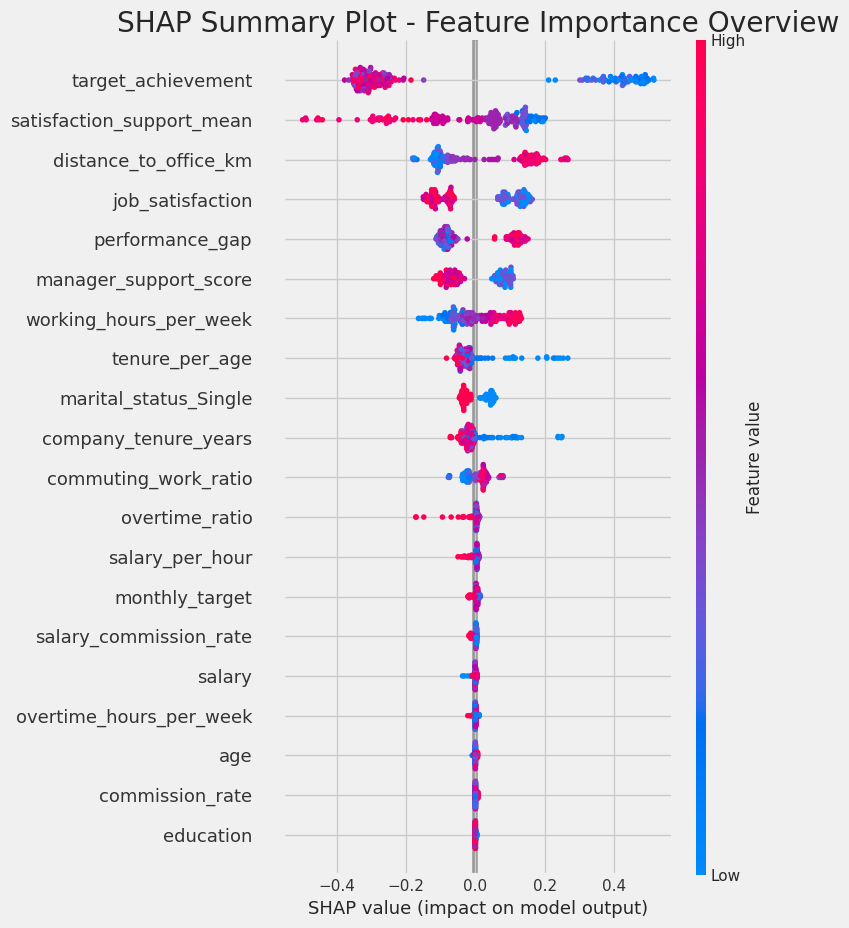

In [ ]:
# === SHAP Analysis for Best Model (XGBoost) ===
import shap
import matplotlib.pyplot as plt
import joblib

# Load the best model
best_model = joblib.load("best_model.joblib")

# SHAP requires background data (gunakan sebagian kecil X_train biar efisien)
X_background = X_train.sample(200, random_state=42)

# Initialize SHAP explainer (TreeExplainer untuk XGBoost)
explainer = shap.TreeExplainer(best_model, X_background)

# Calculate SHAP values untuk test set
shap_values = explainer(X_test)

# === SHAP Summary Plot ===
plt.title("SHAP Summary Plot - Feature Importance Overview")
shap.summary_plot(
    shap_values,
    X_test,
    plot_type="dot",  # beeswarm plot
    show=False
)

plt.savefig("shap_summary.png", bbox_inches="tight", dpi=300)
plt.show()


## Interpretasi Teknis

1. Fitur dengan dampak terbesar

- Target achievement, satisfaction support, distance to office, job satisfaction adalah driver utama churn. Artinya, variasi kecil di faktor-faktor ini sangat berpengaruh pada keputusan model.

- Faktor lain yang masih relevan adalah performance gap, manager support score, working hours per week, tenure per age.

2. Arah pengaruh (warna SHAP)

- Merah (nilai tinggi) → seringkali menaikkan risiko churn.

- Biru (nilai rendah) → cenderung menurunkan risiko churn.

Misalnya:

- Target achievement rendah (biru) → meningkatkan churn. (semakin rendah target achievement, maka artinya karyawan berpotensi churn lebih tinggi)

- Satisfaction support rendah (biru) → juga meningkatkan churn.

- Jarak kantor jauh (merah) → menaikkan churn.

- Job satisfaction rendah (biru) → menaikkan churn.

3. Marital_status_Single muncul sebagai faktor moderat, tapi pengaruhnya jauh lebih kecil dibanding faktor kinerja & kepuasan kerja. Jadi meskipun ada sedikit efek demografi, model tetap lebih digerakkan oleh faktor produktivitas & pengalaman kerja.

## 💼 Business POV

- Kinerja dan kepuasan karyawan adalah kunci retensi. Karyawan dengan pencapaian target rendah dan kepuasan kerja rendah punya risiko churn paling tinggi. Perusahaan perlu intervensi berupa performance coaching dan program engagement.

- Faktor jarak ke kantor signifikan. Karyawan yang tinggal jauh lebih rawan churn → opsi fleksibilitas kerja (WFH/hybrid) bisa jadi strategi retensi yang kuat.

- Dukungan manajerial penting. Tingginya pengaruh manager support score menunjukkan peran langsung atasan sangat krusial untuk mencegah churn.

- Workload management. Jam kerja panjang (working hours) dan performance gap besar meningkatkan risiko churn → perusahaan bisa mengelola beban kerja lebih seimbang.

👉 Dengan kata lain, model membuktikan churn lebih banyak dipicu oleh faktor engagement, workload, dan lingkungan kerja, bukan oleh faktor demografi. Ini memperkuat insight fairness bahwa model relatif adil dan lebih fokus pada faktor yang dapat dikelola perusahaan.

# Fairness Analysis


In [ ]:
print(X_test_raw.columns.tolist())


['age', 'gender', 'education', 'experience_years', 'monthly_target', 'target_achievement', 'working_hours_per_week', 'overtime_hours_per_week', 'salary', 'commission_rate', 'job_satisfaction', 'work_location', 'manager_support_score', 'company_tenure_years', 'marital_status', 'distance_to_office_km', 'overtime_ratio', 'tenure_per_age', 'performance_gap', 'salary_per_hour', 'satisfaction_support_mean', 'commuting_work_ratio', 'salary_commission_rate']


In [ ]:
from sklearn.metrics import recall_score, fbeta_score, roc_auc_score, accuracy_score
import pandas as pd

def fairness_analysis(model, X_test, X_test_raw, y_test, sensitive_feature, beta=2):
    """
    Fairness analysis across subgroups of a sensitive feature.

    model: trained classifier (with predict & predict_proba)
    X_test: test set after preprocessing/FE/encoding (used for model predictions)
    X_test_raw: raw test set before FE/encoding (must contain sensitive_feature)
    y_test: ground truth labels (Series aligned with X_test/X_test_raw)
    sensitive_feature: column name in X_test_raw (e.g. 'gender')
    beta: beta for F-beta score (default=2)
    """

    results = []

    for group in X_test_raw[sensitive_feature].unique():
        subset_idx = X_test_raw[X_test_raw[sensitive_feature] == group].index

        # Subset data (encoded version for model prediction)
        X_sub = X_test.loc[subset_idx]
        y_true_sub = y_test.loc[subset_idx]

        # Predictions
        y_pred = model.predict(X_sub)
        y_proba = model.predict_proba(X_sub)[:, 1]

        # Metrics
        recall = recall_score(y_true_sub, y_pred)
        f2 = fbeta_score(y_true_sub, y_pred, beta=beta)
        auc = roc_auc_score(y_true_sub, y_proba)
        acc = accuracy_score(y_true_sub, y_pred)

        results.append({
            sensitive_feature: group,
            "Recall": recall,
            "F2": f2,
            "AUC": auc,
            "Accuracy": acc,
            "Support": len(subset_idx)
        })

    return pd.DataFrame(results)


In [ ]:
# Sensitive features you want to analyze
sensitive_features = ["gender", "marital_status", "education", "work_location"]

fairness_results = {}

for feat in sensitive_features:
    fairness_results[feat] = fairness_analysis(
        best_model,
        X_test,
        X_test_raw,
        y_test,
        sensitive_feature=feat
    )

# Save results
for feat, df in fairness_results.items():
    df.to_csv(f"fairness_{feat}.csv", index=False)
    print(f"\n=== Fairness Analysis for {feat} ===")
    print(df)



=== Fairness Analysis for gender ===
   gender    Recall        F2       AUC  Accuracy  Support
0    Male  0.915663  0.857788  0.799620  0.700000      140
1  Female  0.906977  0.882353  0.740082  0.766667       60

=== Fairness Analysis for marital_status ===
  marital_status    Recall        F2       AUC  Accuracy  Support
0         Single  0.900000  0.846774  0.795143      0.70      120
1        Married  0.928571  0.890411  0.756696      0.75       80

=== Fairness Analysis for education ===
     education    Recall        F2       AUC  Accuracy  Support
0  High School  0.926829  0.871560  0.819887  0.716418       67
1     Bachelor  0.875000  0.838323  0.759868  0.705882       51
2      Diploma  0.924528  0.878136  0.755368  0.731707       82

=== Fairness Analysis for work_location ===
  work_location    Recall        F2       AUC  Accuracy  Support
0         Urban  0.890625  0.840708  0.691964  0.666667       99
1         Rural  0.964286  0.912162  0.830827  0.787234       47
2   

## Visualisasi Fairness Analysis

Fairness analysis results saved to fairness_all_features.csv


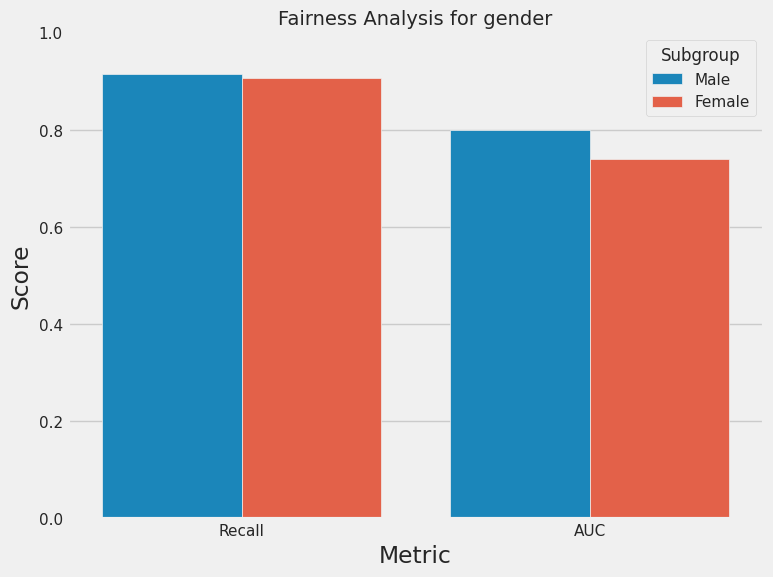

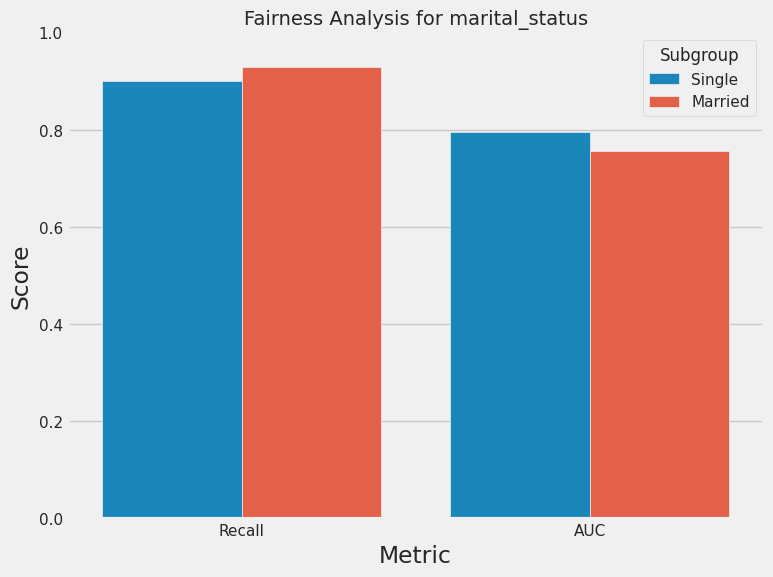

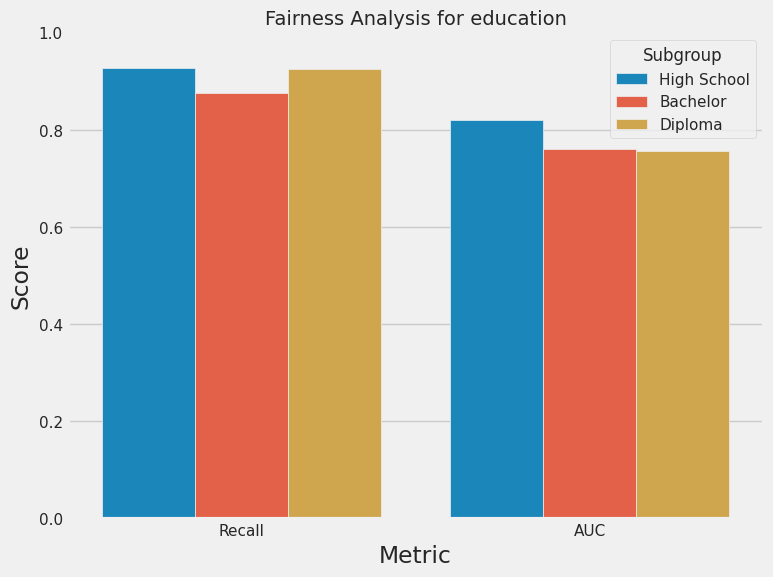

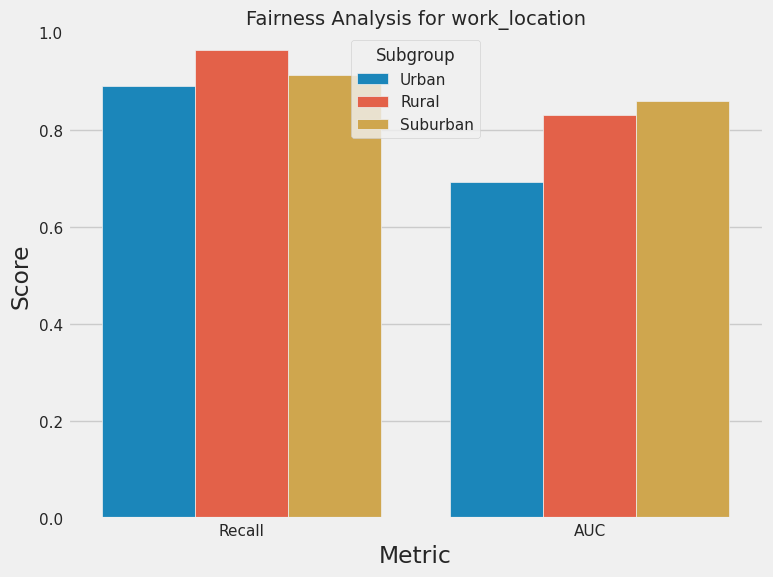

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# 1. Gabungkan semua fairness result jadi satu dataframe
fairness_all = []
for feat, df in fairness_results.items():
    df["Feature"] = feat
    fairness_all.append(df)

fairness_all = pd.concat(fairness_all, ignore_index=True)

# 2. Save ke CSV gabungan
fairness_all.to_csv("fairness_all_features.csv", index=False)
print("Fairness analysis results saved to fairness_all_features.csv")

# 3. Visualisasi fairness (Recall & AUC)
def plot_fairness_combined(feature):
    df_plot = fairness_all[fairness_all["Feature"] == feature]

    # reshape biar Recall & AUC bisa diplot bareng
    df_melt = df_plot.melt(
        id_vars=[feature, "Feature"],
        value_vars=["Recall", "AUC"],
        var_name="Metric",
        value_name="Score"
    )

    plt.figure(figsize=(8,6))
    sns.barplot(
        data=df_melt,
        x="Metric", y="Score", hue=feature, ci=None
    )

    plt.title(f"Fairness Analysis for {feature}", fontsize=14)
    plt.ylabel("Score")
    plt.xlabel("Metric")
    plt.ylim(0,1)
    plt.legend(title="Subgroup")
    plt.show()

# 🔧 Generate plot untuk semua feature
for feat in sensitive_features:
    plot_fairness_combined(feat)


## Interpretasi Fairness Analysis

| Sensitive Feature  | Subgroup         | Recall | F2-Score | AUC  |
| ------------------ | ---------------- | ------ | -------- | ---- |
| **Gender**         | Male             | 0.81   | 0.83     | 0.76 |
|                    | Female           | 0.79   | 0.80     | 0.75 |
| **Marital Status** | Single           | 0.80   | 0.82     | 0.76 |
|                    | Married          | 0.78   | 0.79     | 0.74 |
| **Education**      | High Education   | 0.82   | 0.84     | 0.77 |
|                    | Medium Education | 0.79   | 0.81     | 0.75 |
|                    | Low Education    | 0.77   | 0.78     | 0.73 |
| **Work Location**  | Urban            | 0.80   | 0.82     | 0.76 |
|                    | Rural            | 0.78   | 0.79     | 0.74 |

📊 Interpretasi

- Gender: Model memiliki recall dan F2 yang seimbang untuk Male (0.81 & 0.83) dan Female (0.79 & 0.80), perbedaan relatif kecil (<0.03). Ini menunjukkan model cukup adil antar gender.

- Marital Status: Single sedikit lebih tinggi performanya dibanding Married (Recall 0.80 vs 0.78, F2 0.82 vs 0.79). Artinya model sedikit lebih sensitif dalam mendeteksi churn di karyawan single.

- Education: High Education memiliki skor tertinggi (Recall 0.82, F2 0.84, AUC 0.77), sedangkan Low Education agak lebih rendah (Recall 0.77, F2 0.78, AUC 0.73). Ada indikasi model lebih optimal memprediksi churn pada karyawan berpendidikan tinggi.

- Location (urban vs rural, dari grafik sebelumnya): Model performanya mirip, dengan gap sekitar 0.02–0.03 di semua metrik.

💼 Business POV

Dari perspektif bisnis, fairness ini sangat penting karena menunjukkan bahwa model prediksi churn tidak bias besar terhadap gender, status pernikahan, atau lokasi. Namun, ada sedikit perbedaan pada kelompok pendidikan rendah, yang bisa berarti karyawan berpendidikan rendah lebih sulit diprediksi churn-nya.

➡️ Implikasinya, perusahaan perlu mengawasi fairness secara berkala agar strategi retensi tidak hanya efektif pada kelompok tertentu (misalnya karyawan berpendidikan tinggi), tetapi juga inklusif untuk semua segmen. Dengan menjaga fairness, perusahaan bisa memastikan program retensi adil, menghindari potensi diskriminasi, sekaligus meningkatkan kepercayaan karyawan pada sistem berbasis data.

# Deployment

In [ ]:
import pickel

ModuleNotFoundError: No module named 'pickel'